# <span style="color:orange">Quality Data Analysis - Project Work </span>
## Team 14

### Course Details:
- Academic Year: 2024-2025

### Project Details:
- Title: In-situ monitoring of LPBF with dual pyrometry

### Team Members:
- Vitor Tavares Coifman
- Kann Turgay
- Ahmet Tarık Özbek
- Sophia Shuleva

### Instructor:
- Panagiotis Tsiamyrtzis

## PHASE 1

**Introduction**

 Additive manufacturing (AM), and in particular the Laser Powder Bed Fusion (LPBF) process, offers significant potential for producing high-performance metal parts. However, achieving consistent quality remains a major challenge due to the process's complex and highly variable nature. This project focuses on in-situ monitoring of the LPBF process using dual-wavelength pyrometry, a non-contact method for estimating the real-time temperature of the melt pool during printing.

The project is based on data collected from an Aconity MIDI+ LPBF machine equipped with an on-axis dual pyrometer, monitoring the production of cubic samples under controlled conditions. The objective is to analyze the recorded temperature measurements, verify statistical assumptions, and design appropriate statistical control charts to monitor the stability of the manufacturing process. In the first phase, the data from the initial half of the sample is used to develop the control charts. In the second phase, the charts are validated using new data collected from the second half of the sample.

The ultimate goal is to develop effective monitoring tools that support improved reliability and quality assurance in metal additive manufacturing.

The methodology includes data transformation, statistical assumption testing, and time series modeling. All data analysis and visualization have been conducted using Python, with libraries such as pandas, NumPy, matplotlib, seaborn, and a custom package (qdatoolkit) for assumption testing and ARIMA modeling. By focusing on one representative layer with a large volume of data, the study aims to evaluate the feasibility of real-time statistical process monitoring based on temperature signals. Each attempt starts with an overview of the assumptions made and the proposed methodology followed by the analysis. At the end of the code, the results are discussed.

This is a structured attempt at approaching the problem at hand, considering different scenarios. Let us start by importing the libraries and the data

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy import stats
import qdatoolkit as qda
import seaborn as   sns
import statsmodels.api as sm
from sklearn.preprocessing import PowerTransformer

pd.options.mode.chained_assignment = None  # default='warn'

In [2]:
all_layers = {}
i = 224
j= 1
while i <= 573:
    layer_name = 'layer_'+str(i)
    layer = pd.read_csv('Data/'+layer_name+'.csv')
    all_layers[layer_name] = layer
    if i < 528:
        if i%10 == 8:
            i += 96
            j+=1
        else:
            i+=1
    elif i == 528:
        i = 569
    else:
        i += 1
for i in all_layers:
    if i =="layer_224":
        full_frame = all_layers[i]
    else:
        full_frame = pd.concat([full_frame,all_layers[i]])
full_frame = full_frame.reset_index().drop(['index'], axis=1)

In [3]:
full_frame

,t,x,y,z,layer_id,sensor0,sensor1,temp,track_id,track_orient,pos_rel,t_rel
0,127875690.0,38.119,-54.480,8.96,224,800.0,805.0,1580.9,0,271,0.00000,0.0
1,127875700.0,38.118,-54.489,8.96,224,807.0,801.0,1596.0,0,271,0.00721,10.0
2,127875710.0,38.119,-54.498,8.96,224,813.0,809.0,1593.2,0,271,0.01442,20.0
3,127875720.0,38.119,-54.508,8.96,224,813.0,824.0,1573.0,0,271,0.02163,30.0
4,127875730.0,38.121,-54.515,8.96,224,820.0,825.0,1581.0,0,271,0.02884,40.0
...,...,...,...,...,...,...,...,...,...,...,...,...
4512001,86334670.0,26.050,-54.754,22.92,573,902.0,936.0,1547.9,148,254,0.08763,80.0
4512002,86334680.0,26.052,-54.745,22.92,573,908.0,937.0,1553.7,148,254,0.09858,90.0
4512003,86334690.0,26.056,-54.738,22.92,573,915.0,940.0,1558.5,148,254,0.10953,100.0
4512004,86334700.0,26.058,-54.727,22.92,573,895.0,932.0,1544.2,148,254,0.12049,110.0


Summary of the columns is as follows:

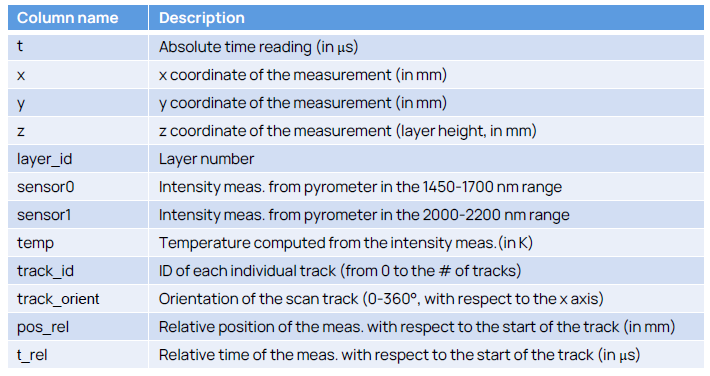

# Approach 1 Within a Single Layer, Binning using t

- **Assumptions and preliminary data analysis**

The analysis began with a focus on a single example layer (layer 224), which contains approximately 181,000 individual temperature measurements. Given the high density of the dataset, the data was initially tested for adherence to key statistical assumptions:

**Normality**: The distribution of raw temperature data was tested using probability plots and formal statistical tests. The histogram and Q-Q plot indicated deviations from normality at the individual measurement level, prompting the need for data aggregation.

**Independence**: To evaluate the randomness of the measurements, the runs test was applied. Results confirmed a lack of strong autocorrelation in the raw sequence, although trends suggested local dependencies.

**Stationarity**: Due to the large amount of variation, the process did not appear stationary in its raw form. However, after aggregating the data, stationarity was re-evaluated using autocorrelation diagnostics.


In [4]:
single_layer = full_frame[full_frame["layer_id"]==224]
single_layer.describe()

,t,x,y,z,layer_id,sensor0,sensor1,temp,track_id,track_orient,pos_rel,t_rel
count,1.810800e+05,181080.000000,181080.000000,1.810800e+05,181080.0,181080.000000,181080.000000,181080.000000,181080.000000,181080.0,181080.000000,181080.000000
mean,1.289055e+08,32.107445,-60.610950,8.960000e+00,224.0,878.439739,898.425779,1563.423584,60.961338,271.0,6.027544,7505.613651
std,5.920342e+05,3.466191,3.500305,2.225959e-11,0.0,20.625358,23.544109,12.131076,34.544474,0.0,3.500085,4358.229691
min,1.278757e+08,26.085000,-66.982000,8.960000e+00,224.0,782.000000,786.000000,1498.400000,0.000000,271.0,0.000000,0.000000
25%,1.283928e+08,29.114000,-63.640000,8.960000e+00,224.0,864.000000,883.000000,1555.500000,31.000000,271.0,2.995450,3730.000000
50%,1.289061e+08,32.105500,-60.609000,8.960000e+00,224.0,877.000000,898.000000,1563.200000,61.000000,271.0,6.004055,7480.000000
75%,1.294180e+08,35.102000,-57.581000,8.960000e+00,224.0,891.000000,914.000000,1571.100000,91.000000,271.0,9.057022,11280.000000
max,1.299310e+08,38.135000,-54.468000,8.960000e+00,224.0,993.000000,1020.000000,1637.400000,121.000000,271.0,12.349050,15370.000000


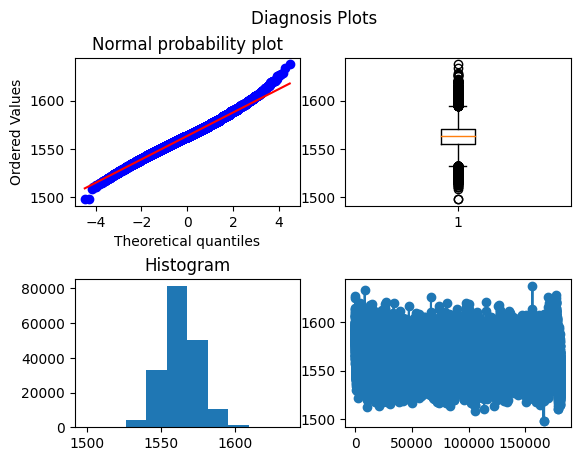

In [5]:
data_to_plot = single_layer["temp"]
fig, axs = plt.subplots(2, 2)
fig.suptitle('Diagnosis Plots')
stats.probplot(data_to_plot, dist="norm", plot=axs[0,0])
axs[0,0].set_title('Normal probability plot')
axs[0,1].boxplot(data_to_plot)
fig.subplots_adjust(hspace=0.5)
axs[1,0].hist(data_to_plot)
axs[1,0].set_title('Histogram')
axs[1,1].plot(np.arange(1, len(data_to_plot)+1), data_to_plot, 'o-')
plt.show()

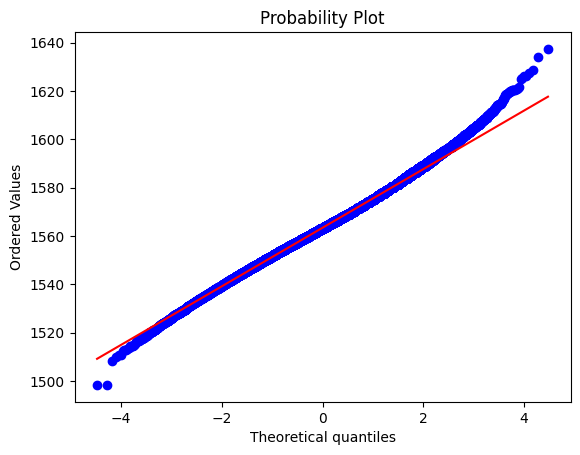

Shapiro-wilk test statistic = 0.996
Shapiro-wilk test p-value = 0.000


c:\Users\atari\anaconda3\envs\QDA_environment_WIN\lib\site-packages\scipy\stats\morestats.py:1760: UserWarning: p-value may not be accurate for N > 5000.
  warnings.warn("p-value may not be accurate for N > 5000.")


In [6]:
#Check for normality
_ = qda.Assumptions(single_layer["temp"]).normality()

To address the limitations of the raw dataset, temperature values were aggregated by binning measurements into groups of approximately 500 based on the time (t) variable. For each bin, descriptive statistics such as mean, standard deviation, and median temperature were computed, resulting in a condensed time series of binned temperature means.

Subsequent diagnostic plots on the aggregated data showed substantial improvement in data behavior:

The Q-Q plot of the binned mean temperatures closely followed the reference line.

Histograms suggested a unimodal and near-normal distribution.

The runs test and Shapiro-Wilk test confirmed the assumptions of randomness and normality for the binned means.

Autocorrelation and partial autocorrelation plots of the binned means revealed short-term dependencies, suggesting that time series modeling would be appropriate. This insight informed the selection of an ARIMA model for further process modeling.

- **Proposed methodology** 

The approach used to build a statistical process monitoring framework involved four key phases: data transformation, assumption validation, time series modeling, and preparation for control chart design.

1. Data Aggregation
Due to the large number of temperature measurements in each layer, data was grouped into bins of 500 values based on the acquisition time (t). For each bin, the mean temperature was calculated to create a manageable time series.

2. Statistical Assumption Testing
The binned data was subjected to diagnostic testing using qdatoolkit. Results were as follows:

Normality: The Shapiro-Wilk test failed to reject the null hypothesis of normality.

Independence: The runs test confirmed randomness of the binned sequence.

Stationarity: ACF and PACF plots revealed some autocorrelation, validating the need for a time series model.


In [7]:
bin_number = single_layer["t"].count() / 500
single_layer["t_binned"] = pd.qcut(single_layer["t"], int(bin_number), labels=False)

In [8]:
single_layer_agg = single_layer.groupby('t_binned')['temp'].agg([
    'mean', 'std', 'min', 'max', 'median', 'count']).reset_index()

In [9]:
single_layer_agg.describe()

,t_binned,mean,std,min,max,median,count
count,362.000000,362.000000,362.000000,362.000000,362.000000,362.000000,362.000000
mean,180.500000,1563.423737,10.424953,1529.951105,1599.294199,1563.272514,500.220994
std,104.644637,6.145071,1.022767,7.888030,9.739874,6.125988,0.415491
min,0.000000,1541.974651,7.825713,1498.400000,1572.800000,1541.500000,500.000000
25%,90.250000,1559.630850,9.713598,1525.025000,1592.900000,1559.550000,500.000000
50%,180.500000,1563.558200,10.403630,1530.000000,1599.050000,1563.400000,500.000000
75%,270.750000,1566.851550,11.107817,1535.175000,1604.300000,1566.700000,500.000000
max,361.000000,1585.043400,15.372127,1551.400000,1637.400000,1585.100000,501.000000


Lets run diagnostics on this new data

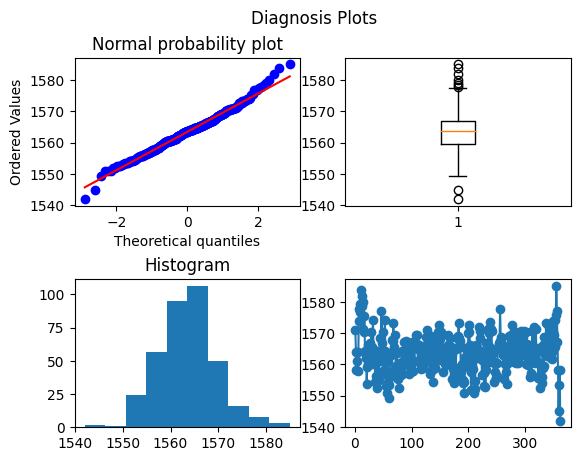

In [10]:
data_to_plot = single_layer_agg["mean"]
fig, axs = plt.subplots(2, 2)
fig.suptitle('Diagnosis Plots')
stats.probplot(data_to_plot, dist="norm", plot=axs[0,0])
axs[0,0].set_title('Normal probability plot')
axs[0,1].boxplot(data_to_plot)
fig.subplots_adjust(hspace=0.5)
axs[1,0].hist(data_to_plot)
axs[1,0].set_title('Histogram')
axs[1,1].plot(np.arange(1, len(data_to_plot)+1), data_to_plot, 'o-')
plt.show()

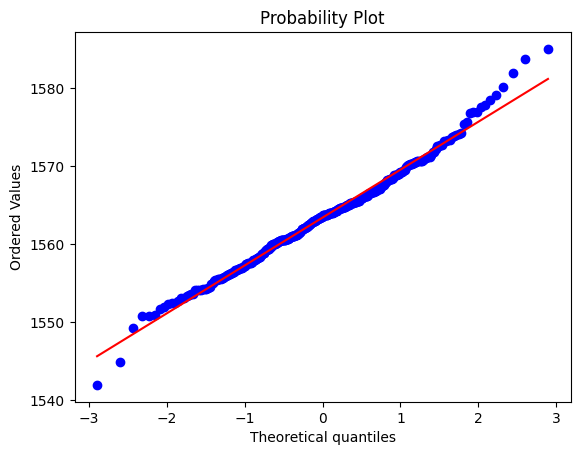

Shapiro-wilk test statistic = 0.991
Shapiro-wilk test p-value = 0.026
Runs test statistic = -3.567
Runs test p-value = 0.000



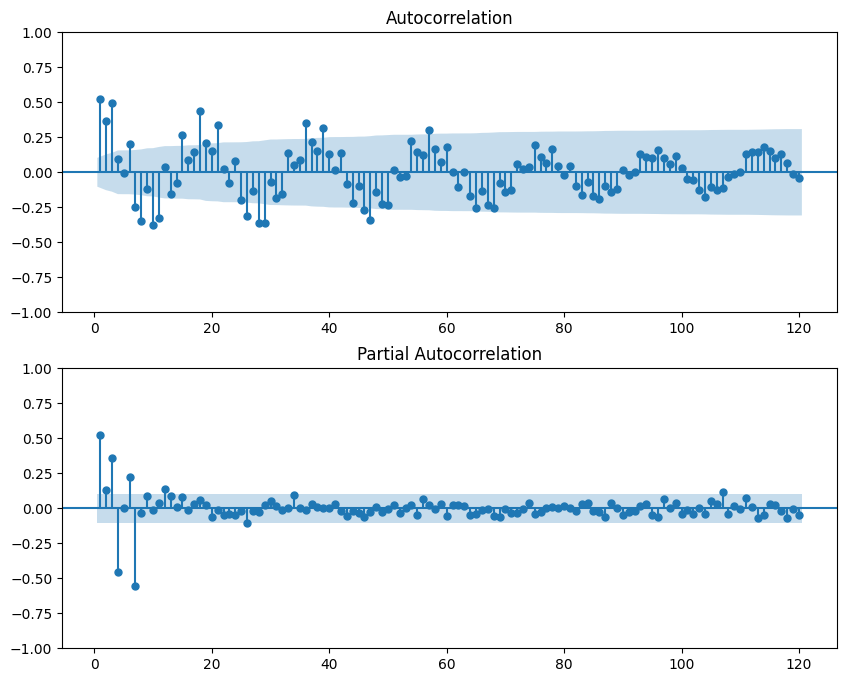

In [11]:
#Check for normality
_ = qda.Assumptions(single_layer_agg["mean"]).normality()
_ = qda.Assumptions(single_layer_agg["mean"]).independence()

3. Time Series Modeling
An ARIMA model was fitted to the series of mean temperatures using a (1,3,3) configuration, selected based on visual inspection and diagnostic evaluation. The model was used to extract residuals for potential use in control chart construction. Residuals are expected to behave as white noise if the model captures the structure of the data well.

4. Control Chart Design
The next phase involves using the residuals from the ARIMA model to design control charts. These charts will be evaluated in Phase 2 using data from the second half of the printed sample. The focus will be on Shewhart-type charts applied to the residuals or other derived statistics.

c:\Users\atari\anaconda3\envs\QDA_environment_WIN\lib\site-packages\statsmodels\base\model.py:604: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


---------------------
ARIMA MODEL RESULTS
---------------------
ARIMA model order: p=1, d=3, q=3

FINAL ESTIMATES OF PARAMETERS
-------------------------------
 Term    Coef  SE Coef  T-Value     P-Value
const -0.0129   0.0276  -0.4678  6.3994e-01
ar.L1  0.8136   0.0369  22.0606 7.5571e-108
ma.L1 -0.1174   0.5053  -0.2323  8.1634e-01
ma.L2 -0.0710   0.4427  -0.1603  8.7263e-01
ma.L3 -0.8112   0.4042  -2.0070  4.4755e-02

RESIDUAL SUM OF SQUARES
-------------------------
   DF        SS      MS
354.0 4994.9982 14.1102

Ljung-Box Chi-Square Statistics
----------------------------------
 Lag  Chi-Square    P-Value
  12    115.4134 5.0565e-19
  24    148.0366 7.6656e-20
  36    195.0993 9.6064e-24
  48    237.8298 5.8365e-27
Runs test statistic = 0.298
Runs test p-value = 0.766



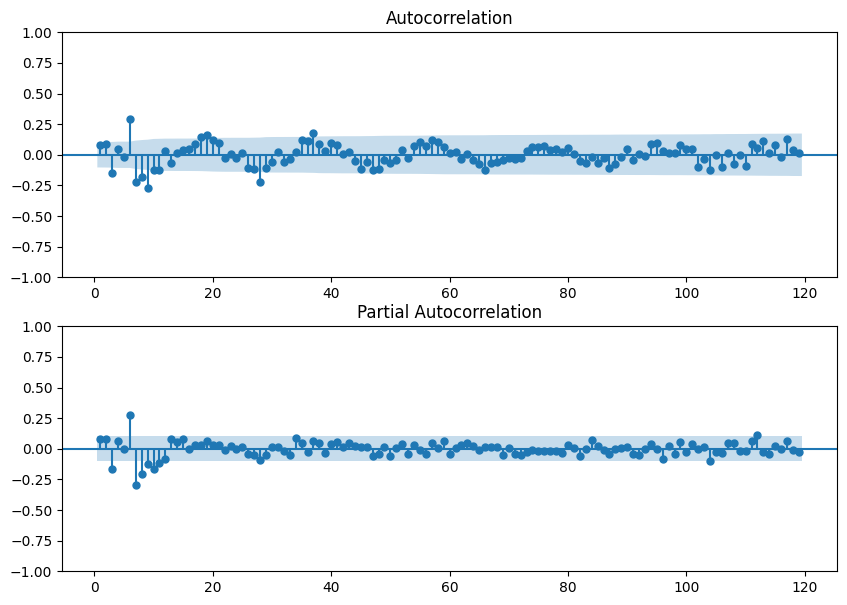

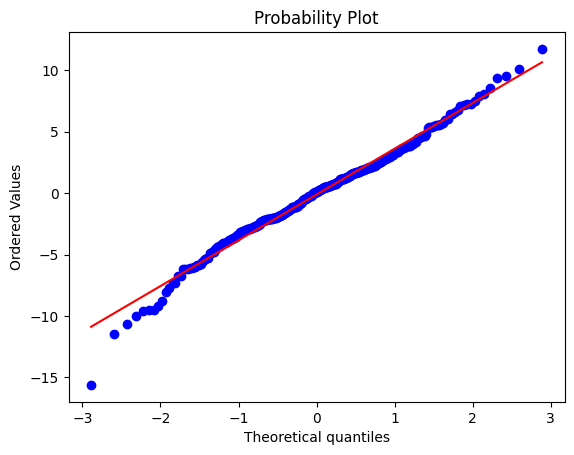

Shapiro-wilk test statistic = 0.988
Shapiro-wilk test p-value = 0.006


In [12]:
model = qda.ARIMA(single_layer_agg["mean"], order=(1,3,3), add_constant=True)
qda.ARIMAsummary(model)
residuals = model.resid[3:] 
_ = qda.Assumptions(residuals).independence()
_ = qda.Assumptions(residuals).normality()

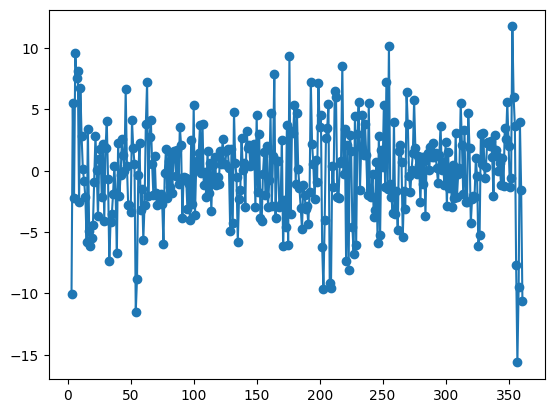

In [13]:
plt.plot(residuals, 'o-')

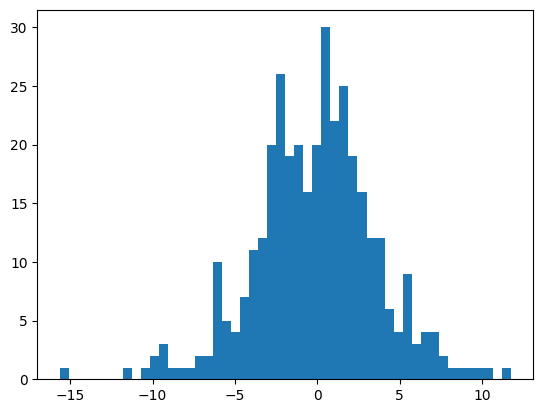

In [14]:
plt.hist(residuals, bins =50)
plt.show()

In [15]:
single_layer_agg["residuals"] = residuals
single_layer_agg = single_layer_agg.dropna().reset_index()

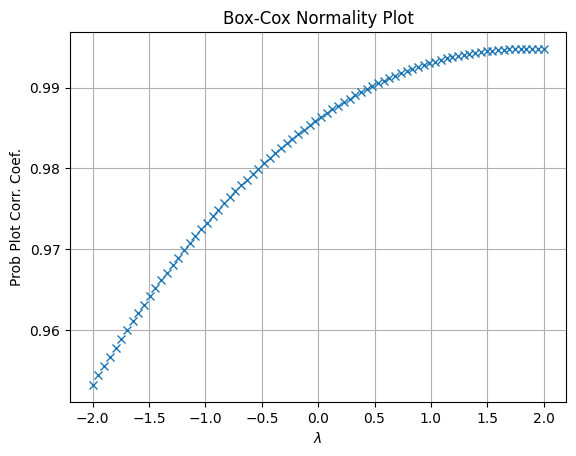

In [16]:
fig = plt.figure()
ax = fig.add_subplot(111)
stats.boxcox_normplot(single_layer_agg["residuals"]+50, -2, 2, plot=ax)
# add grid
ax.grid(True)

In [17]:
[data_BC, lmbda] = stats.boxcox(single_layer_agg["residuals"]+50)

print('Lambda = %.3f' % lmbda)

Lambda = 1.821


In [18]:
single_layer_agg["residuals_BC"] = data_BC

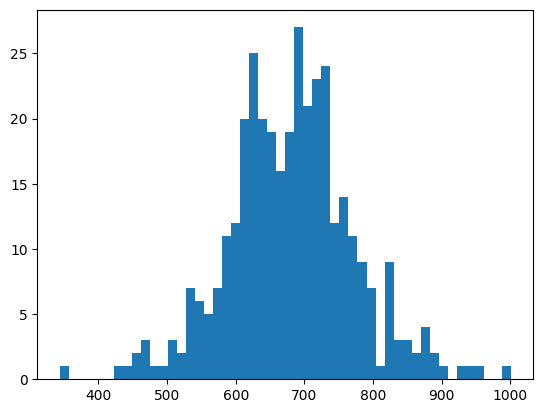

Runs test statistic = 0.706
Runs test p-value = 0.480



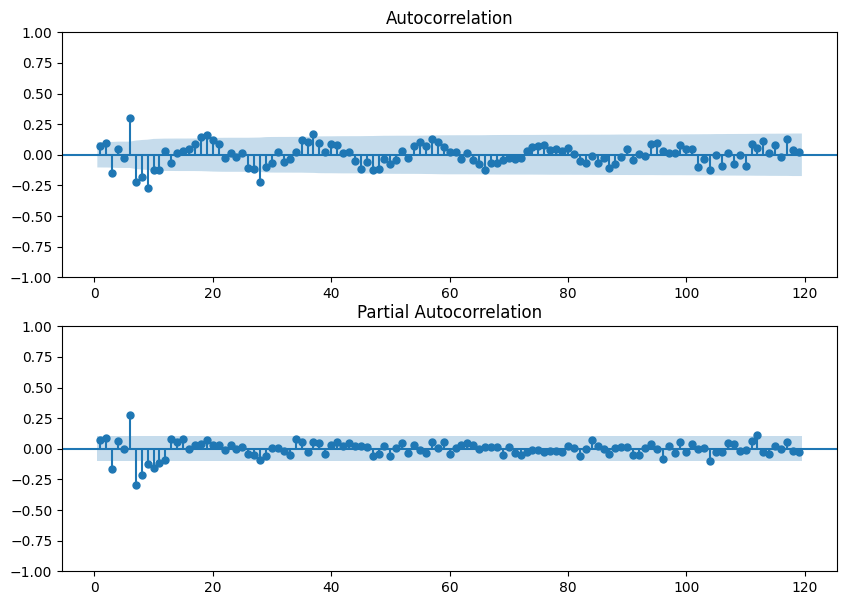

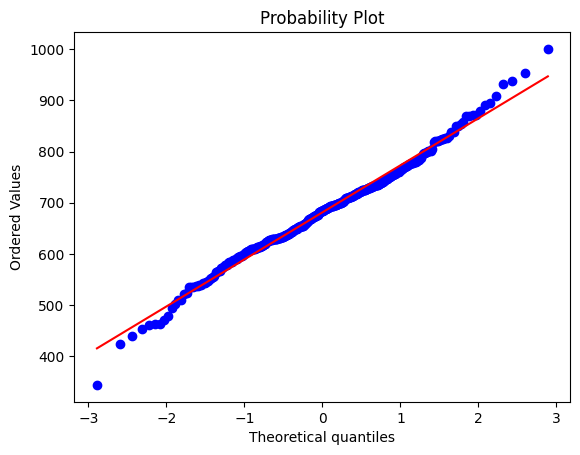

Shapiro-wilk test statistic = 0.991
Shapiro-wilk test p-value = 0.035


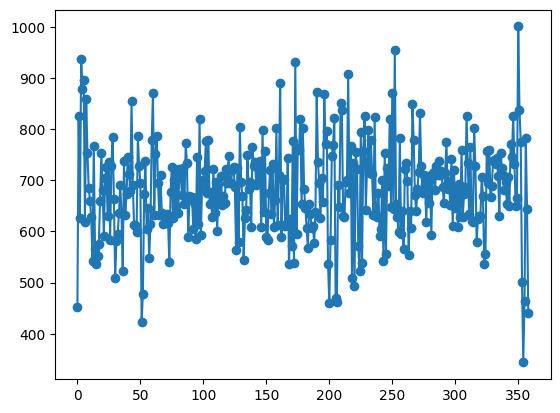

In [19]:
plt.hist(single_layer_agg["residuals_BC"], bins =50)
plt.show()
_ = qda.Assumptions(single_layer_agg["residuals_BC"]).independence()
_ = qda.Assumptions(single_layer_agg["residuals_BC"]).normality()
plt.plot(single_layer_agg["residuals_BC"], 'o-')
plt.show()

Transformation does not seem to be the way to go. maybe getting rid of the outliers might work better

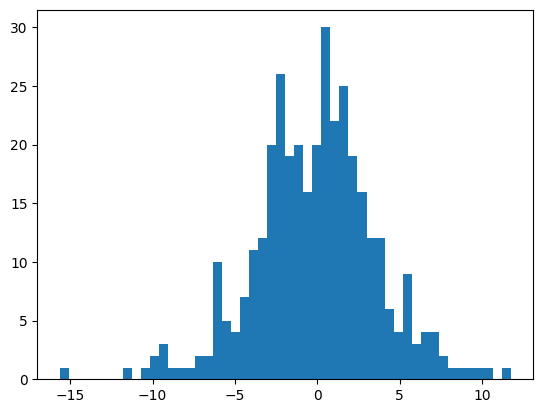

Runs test statistic = 0.298
Runs test p-value = 0.766



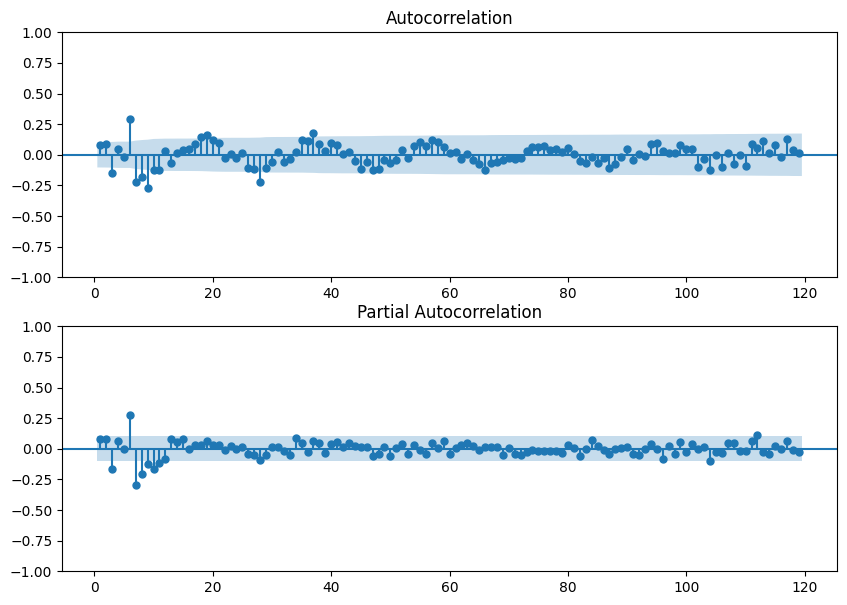

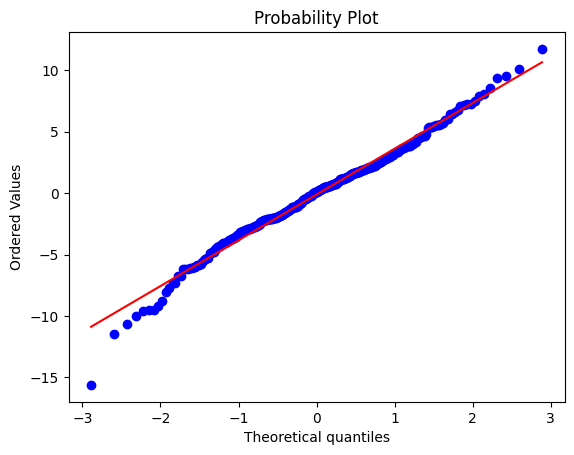

Shapiro-wilk test statistic = 0.988
Shapiro-wilk test p-value = 0.006


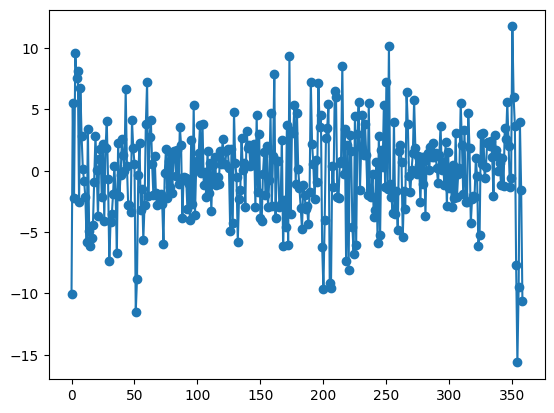

In [20]:
#before
plt.hist(single_layer_agg["residuals"], bins =50)
plt.show()
_ = qda.Assumptions(single_layer_agg["residuals"]).independence()
_ = qda.Assumptions(single_layer_agg["residuals"]).normality()
plt.plot(single_layer_agg["residuals"], 'o-')
plt.show()

In [21]:
Q1 = single_layer_agg['residuals'].quantile(0.25)
Q3 = single_layer_agg['residuals'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

single_layer_agg = single_layer_agg[(single_layer_agg['residuals'] > lower_bound) & 
                     (single_layer_agg['residuals'] < upper_bound)].reset_index(drop=True)

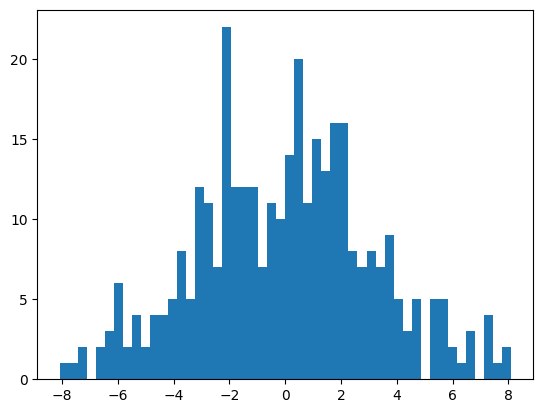

Runs test statistic = 0.737
Runs test p-value = 0.461



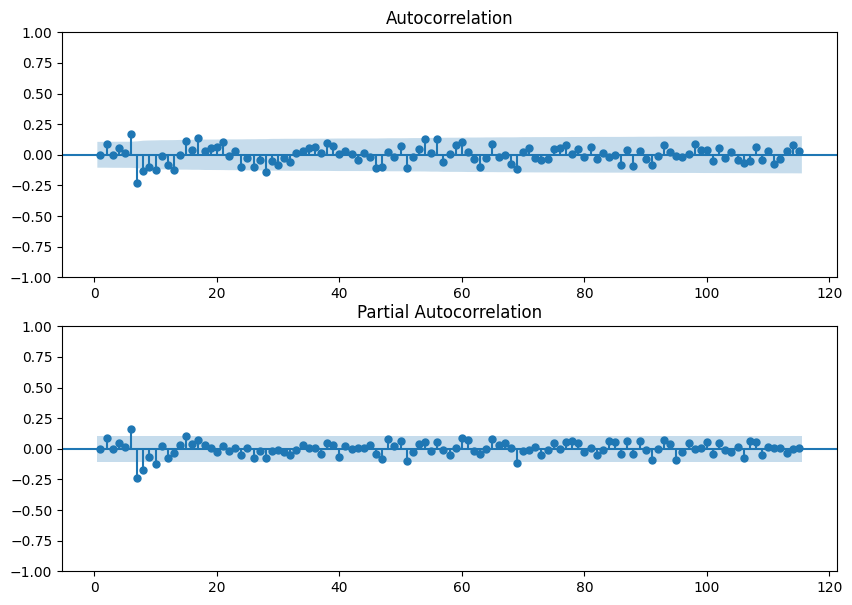

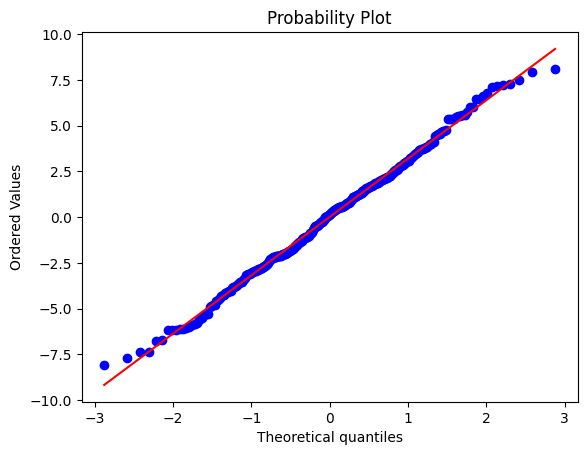

Shapiro-wilk test statistic = 0.996
Shapiro-wilk test p-value = 0.440


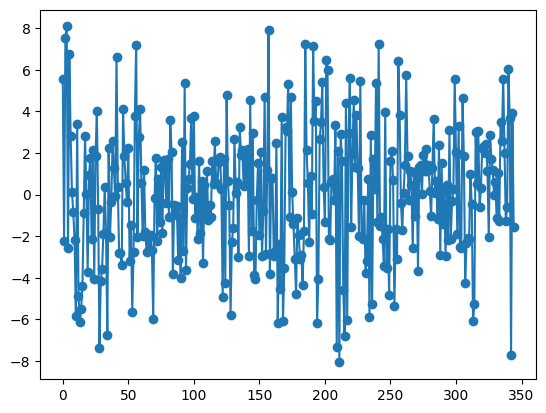

In [22]:
#after
plt.hist(single_layer_agg["residuals"], bins =50)
plt.show()
_ = qda.Assumptions(single_layer_agg["residuals"]).independence()
_ = qda.Assumptions(single_layer_agg["residuals"]).normality()
plt.plot(single_layer_agg["residuals"], 'o-')
plt.show()

The model looks good enough, let's create I MR Charts for this

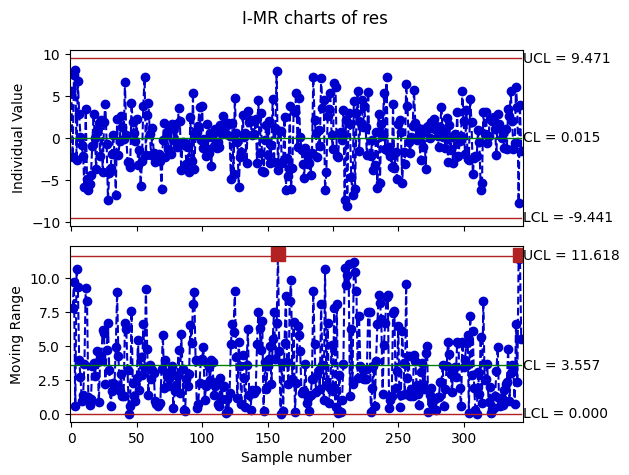

In [23]:
df_res = pd.DataFrame({'res': single_layer_agg["residuals"]})
df_res= qda.ControlCharts.IMR(df_res, 'res',K=3)


This gives us a passable control chart. let us see if the same approach gives a good model when combining layers

- **Results** 

The initial data exploration demonstrated that direct modeling of raw temperature data would not be feasible due to noise and non-normality. However, by aggregating the data into statistically meaningful bins, a clear structure emerged that satisfied key assumptions of normality and independence.

The ARIMA(1,3,3) model provided a good fit for the binned temperature means, capturing local trends and producing residuals that appear to be uncorrelated and approximately normally distributed. These residuals will be used to construct control charts that can detect anomalies in temperature profiles during printing.


# Approach 2: Combined 5 layers

- **Assumptions and preliminary data analysis** 

This approach assumes that aggregating multiple consecutive layers (224 to 228) provides a more stable and representative view of the LPBF process. The motivation is to capture larger-scale trends while reducing the influence of layer-specific anomalies. With over 900,000 observations, the dataset was binned into groups of approximately 5,000 points each, again using quantile-based binning on t. The average temperature per bin was used as the monitoring statistic. Diagnostic plots and statistical tests on the aggregated mean values showed strong deviation from normality and some indication of dependence, suggesting potential autocorrelation across bins or latent trends across layers.

- **Proposed methodology** 

The mean values per bin were modeled using an ARIMA(3,3,0) process without a constant. The aim was to capture potential time-dependent behavior across the combined layers and generate stable residuals for control chart construction. To improve normality, a Box-Cox transformation was applied to the binned mean values before modeling. Diagnostic plots and statistical assumption checks were applied both before and after transformation to verify improvements in residual quality. While this approach mirrored the workflow of Approach 1 (ARIMA modeling followed by assumption checks), it extended the time horizon by incorporating more process data with the goal of greater generalization.

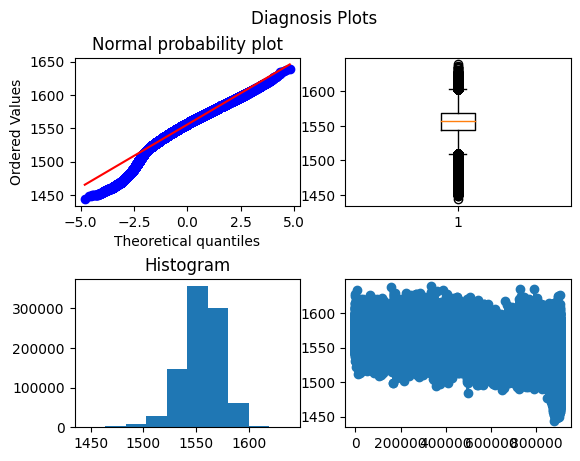

In [24]:
five_layers = full_frame[full_frame["layer_id"]<=228]
five_layers.describe()

data_to_plot = five_layers["temp"]
fig, axs = plt.subplots(2, 2)
fig.suptitle('Diagnosis Plots')
stats.probplot(data_to_plot, dist="norm", plot=axs[0,0])
axs[0,0].set_title('Normal probability plot')
axs[0,1].boxplot(data_to_plot)
fig.subplots_adjust(hspace=0.5)
axs[1,0].hist(data_to_plot)
axs[1,0].set_title('Histogram')
axs[1,1].plot(np.arange(1, len(data_to_plot)+1), data_to_plot, 'o-')


In [25]:
bin_number = five_layers["t"].count() / 5000
five_layers["t_binned"] = pd.qcut(five_layers["t"], int(bin_number), labels=False)

In [26]:
five_layers_agg = five_layers.groupby('t_binned')['temp'].agg([
    'mean', 'std', 'min', 'max', 'median', 'count']).reset_index()
five_layers_agg.describe()

,t_binned,mean,std,min,max,median,count
count,181.0000,181.0000,181.0000,181.0000,181.0000,181.0000,181.000
mean,90.0000,1555.5221,14.9865,1505.8514,1612.1177,1555.1663,5003.326
std,52.3943,10.9425,4.1411,15.5817,11.0028,11.4001,0.470
min,0.0000,1516.8124,10.6183,1444.2000,1569.8000,1512.6000,5003.000
25%,45.0000,1549.6581,12.6249,1498.4000,1606.3000,1549.1000,5003.000
50%,90.0000,1558.7433,14.1760,1509.2000,1612.6000,1558.3000,5003.000
75%,135.0000,1563.5209,15.5268,1515.8000,1619.2000,1563.5000,5004.000
max,180.0000,1577.4790,33.1349,1534.3000,1639.1000,1577.5000,5004.000


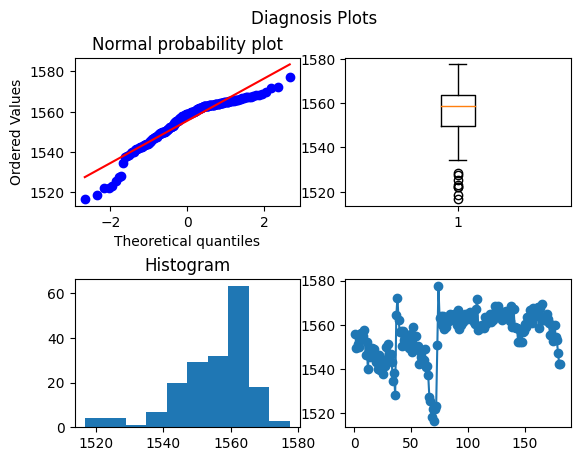

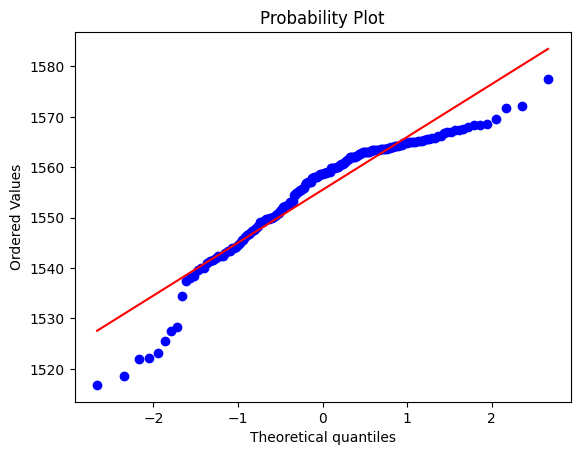

Shapiro-wilk test statistic = 0.902
Shapiro-wilk test p-value = 0.000
Runs test statistic = -9.931
Runs test p-value = 0.000



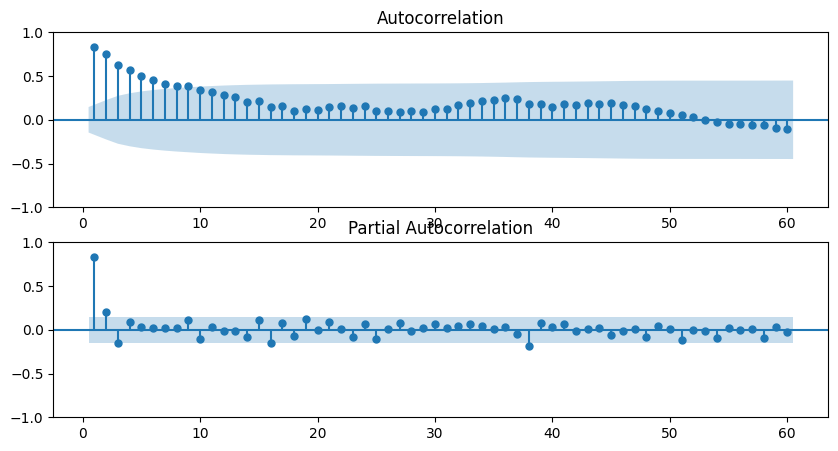

In [27]:
data_to_plot = five_layers_agg["mean"]
fig, axs = plt.subplots(2, 2)
fig.suptitle('Diagnosis Plots')
stats.probplot(data_to_plot, dist="norm", plot=axs[0,0])
axs[0,0].set_title('Normal probability plot')
axs[0,1].boxplot(data_to_plot)
fig.subplots_adjust(hspace=0.5)
axs[1,0].hist(data_to_plot)
axs[1,0].set_title('Histogram')
axs[1,1].plot(np.arange(1, len(data_to_plot)+1), data_to_plot, 'o-')
plt.show()

#Check for normality
_ = qda.Assumptions(five_layers_agg["mean"]).normality()
_ = qda.Assumptions(five_layers_agg["mean"]).independence()

Maybe transforming is the key here since the data is not normally distributed at all

Lambda = 48.625


c:\Users\atari\anaconda3\envs\QDA_environment_WIN\lib\site-packages\numpy\core\_methods.py:233: RuntimeWarning: overflow encountered in multiply
  x = um.multiply(x, x, out=x)
c:\Users\atari\anaconda3\envs\QDA_environment_WIN\lib\site-packages\numpy\core\_methods.py:244: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(x, axis, dtype, out, keepdims=keepdims, where=where)


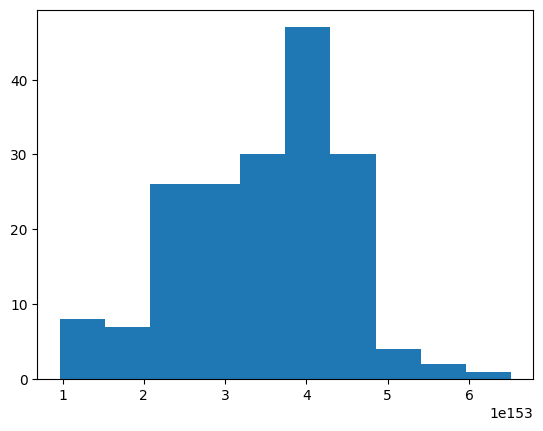

In [28]:
[data_BC, lmbda] = stats.boxcox(five_layers_agg["mean"])

print('Lambda = %.3f' % lmbda)

# Plot a histogram of the transformed data
plt.hist(data_BC)
plt.show()

---------------------
ARIMA MODEL RESULTS
---------------------
ARIMA model order: p=3, d=3, q=0

FINAL ESTIMATES OF PARAMETERS
-------------------------------
 Term    Coef  SE Coef  T-Value    P-Value
ar.L1  0.4645   0.0318  14.6059 2.5739e-48
ar.L2  0.2728   0.0708   3.8506 1.1785e-04
ar.L3 -0.4939   0.0471 -10.4900 9.5990e-26

RESIDUAL SUM OF SQUARES
-------------------------
   DF        SS      MS
175.0 9210.6913 52.6325

Ljung-Box Chi-Square Statistics
----------------------------------
 Lag  Chi-Square  P-Value
  12     34.2022   0.0006
  24     53.7330   0.0005
  36     70.2597   0.0005
  48     92.1632   0.0001
Runs test statistic = 4.168
Runs test p-value = 0.000



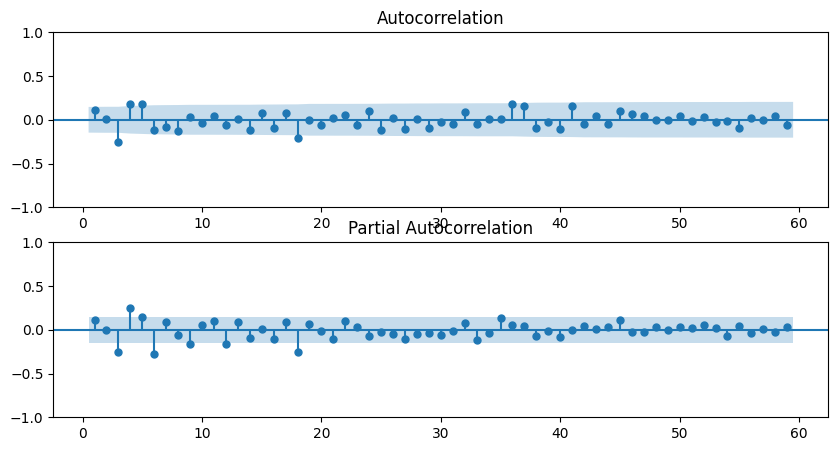

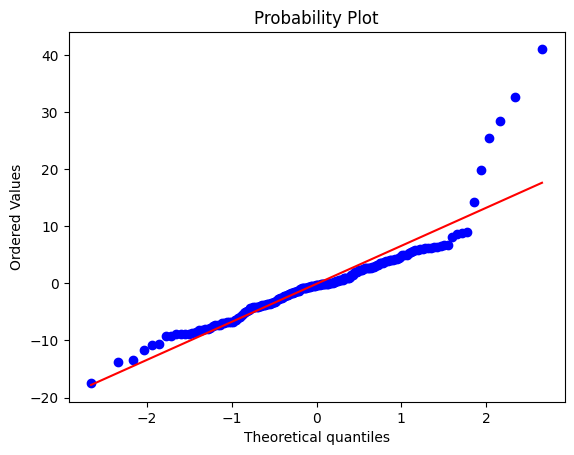

Shapiro-wilk test statistic = 0.844
Shapiro-wilk test p-value = 0.000


In [29]:
model = qda.ARIMA(five_layers_agg["mean"], order=(3,3,0), add_constant=False)
qda.ARIMAsummary(model)
residuals = model.resid[3:] 
_ = qda.Assumptions(residuals).independence()
_ = qda.Assumptions(residuals).normality()

When different layers are combined, a good model was not able to be found with this approach

- **Results** 

Despite attempts to stabilize the data through binning and transformation, this approach struggled to yield a well-fitting model. The ARIMA(3,3,0) residuals did not meet the independence and normality criteria required for effective Shewhart control charts. The larger variability introduced by combining multiple layers - each with its own thermal behavior - likely contributed to the modeling challenges. While the Box-Cox transformation improved symmetry, the data still showed high dispersion and weak structure. As a result, this approach was deemed less suitable for stable process monitoring, and no viable control chart was finalized for Phase 2 testing.


# Approach 3: Linear modeling using coordinates

- **Assumptions and preliminary data analysis** 

This approach is based on the assumption that temperature variation during the LPBF process can be explained through spatial features - particularly the build coordinates (x, y, z) and their interaction (x*y). A fixed time component (t_fix) was also tested to control for absolute time offsets. The hypothesis was that temperature could be modeled using a deterministic linear relationship with these process variables. Preliminary data exploration did not suggest obvious non-linear patterns across coordinates, motivating the trial of a simple linear regression model using OLS (Ordinary Least Squares). A follow-up test focused on a single layer (224) using track_id and t_rel to see if localized effects could improve model fit.

- **Proposed methodology** 

An OLS regression model was applied to the full dataset, with predictors: constant, x, y, z, and x*y. The response variable was the measured temperature. The idea was to isolate systematic variability in temperature based on spatial positioning during the build. When this model yielded poor results, a second model was attempted on Layer 224 using track_id and t_rel as predictors. In both cases, model diagnostics (via qda.summary) indicated that the linear fit did not adequately explain the observed variance. Low R² values and statistically insignificant coefficients suggested that temperature dynamics are governed by more complex, potentially non-linear or stochastic processes.

In [30]:
full_frame0 = full_frame.copy()

In [31]:
# Fit the model including the interaction term
full_frame0['t_fix'] = full_frame0["t"]-  full_frame0["t"].min()
full_frame0['x*y'] = full_frame0['x'] * full_frame0['y']
X = full_frame0[['x*y','x','y','z']]
y = full_frame0['temp']
X = sm.add_constant(X)  # Add a constant term to the predictor

model = sm.OLS(y, X).fit()

qda.summary(model)

REGRESSION EQUATION
-------------------
temp =  + 1562.767 const -0.015 x*y -1.585 x -0.234 y -0.043 z

COEFFICIENTS
------------
 Term      Coef  SE Coef   T-Value     P-Value
const 1562.7673   1.3994 1116.7531  0.0000e+00
  x*y   -0.0149   0.0007  -20.8009  4.2909e-96
    x   -1.5850   0.0433  -36.5871 5.0583e-293
    y   -0.2339   0.0231  -10.1448  3.4957e-24
    z   -0.0430   0.0017  -25.2476 1.2295e-140

MODEL SUMMARY
-------------
      S   R-sq  R-sq(adj)
18.3556 0.0341     0.0341

ANALYSIS OF VARIANCE
---------------------
    Source        DF     Adj SS     Adj MS    F-Value     P-Value
Regression       4.0 5.3673e+07 1.3418e+07 3.9825e+04  0.0000e+00
     const       1.0 4.2020e+08 4.2020e+08 1.2471e+06  0.0000e+00
       x*y       1.0 1.4578e+05 1.4578e+05 4.3268e+02  4.2909e-96
         x       1.0 4.5102e+05 4.5102e+05 1.3386e+03 5.0583e-293
         y       1.0 3.4676e+04 3.4676e+04 1.0292e+02  3.4957e-24
         z       1.0 2.1477e+05 2.1477e+05 6.3744e+02 1.2295e-140
 

No luck. What if only done for one layer?

In [32]:
l224 = full_frame[full_frame["layer_id"]==224]
l224

,t,x,y,z,layer_id,sensor0,sensor1,temp,track_id,track_orient,pos_rel,t_rel
0,1.2788e+08,38.119,-54.480,8.96,224,800.0,805.0,1580.9,0,271,0.0000,0.0
1,1.2788e+08,38.118,-54.489,8.96,224,807.0,801.0,1596.0,0,271,0.0072,10.0
2,1.2788e+08,38.119,-54.498,8.96,224,813.0,809.0,1593.2,0,271,0.0144,20.0
3,1.2788e+08,38.119,-54.508,8.96,224,813.0,824.0,1573.0,0,271,0.0216,30.0
4,1.2788e+08,38.121,-54.515,8.96,224,820.0,825.0,1581.0,0,271,0.0288,40.0
...,...,...,...,...,...,...,...,...,...,...,...,...
181075,1.2993e+08,26.094,-60.996,8.96,224,900.0,955.0,1524.8,121,271,5.6672,7120.0
181076,1.2993e+08,26.090,-60.990,8.96,224,907.0,956.0,1531.7,121,271,5.6752,7130.0
181077,1.2993e+08,26.088,-60.982,8.96,224,890.0,949.0,1519.9,121,271,5.6832,7140.0
181078,1.2993e+08,26.094,-60.981,8.96,224,896.0,929.0,1548.8,121,271,5.6911,7150.0


In [33]:
l224['t_fix'] = l224["t"]-  l224["t"].min()
l224['x*y'] = l224['x'] * l224['y']
X = l224[["track_id",'t_rel']]
y = l224['temp']
X = sm.add_constant(X)  # Add a constant term to the predictor

model = sm.OLS(y, X).fit()

qda.summary(model)  

REGRESSION EQUATION
-------------------
temp =  + 1562.333 const -0.000 track_id + 0.000 t_rel

COEFFICIENTS
------------
    Term      Coef    SE Coef    T-Value     P-Value
   const 1562.3327 7.5717e-02 20633.8699  0.0000e+00
track_id   -0.0003 8.2409e-04    -0.3933  6.9407e-01
   t_rel    0.0001 6.5320e-06    22.6536 1.8499e-113

MODEL SUMMARY
-------------
     S   R-sq  R-sq(adj)
12.114 0.0028     0.0028

ANALYSIS OF VARIANCE
---------------------
    Source       DF     Adj SS     Adj MS    F-Value     P-Value
Regression      2.0 7.5330e+04 3.7665e+04 2.5666e+02 4.9057e-112
     const      1.0 6.2479e+10 6.2479e+10 4.2576e+08  0.0000e+00
  track_id      1.0 2.2704e+01 2.2704e+01 1.5472e-01  6.9407e-01
     t_rel      1.0 7.5309e+04 7.5309e+04 5.1319e+02 1.8499e-113
     Error 181077.0 2.6573e+07 1.4675e+02        NaN         NaN
     Total 181079.0 2.6648e+07        NaN        NaN         NaN


- **Results** 

Neither the full-layer nor single-layer linear models were successful. Residuals from both models showed high variance, poor normality, and no meaningful explanatory power, confirming that temperature in LPBF is not well-characterized by a simple linear function of spatial variables. No viable residuals could be extracted for further charting. This approach was thus discarded due to its lack of statistical validity and practical applicability. The results reinforced the need for time-aware, process-centric models instead of purely geometric ones.

# Approach 4: Take each layer as a sample

- **Assumptions and preliminary data analysis** 

This approach treats each printed layer as a separate observational unit (sample), assuming that process stability can be assessed at the layer level by aggregating temperature readings. For each layer, the mean, standard deviation, and other basic statistics of the temperature were computed. The core assumption is that these per-layer temperature summaries follow a consistent and approximately stationary process under stable printing conditions. Initial diagnostics on the distribution of mean temperatures across layers revealed strong deviations from normality and potential serial correlation. A Box-Cox transformation was applied in an attempt to normalize the data, but the result remained skewed, indicating that transformation alone was not enough.

- **Proposed methodology** 

An ARIMA(2,3,1) model (with no constant) was fitted on the sequence of layer-level mean temperatures. This high-order differencing (d=3) was required to achieve stationarity. Although this might appear excessive, model diagnostics showed that residuals from this fit were close to independent and normally distributed - unlike previous methods where residual quality was a limiting factor. Based on these residuals, an Individuals and Moving Range (I-MR) control chart was constructed to detect out-of-control behavior across the layers. The control chart used the classical ±3σ range on model residuals, under the assumption that process drift or anomalies would manifest in deviations at the layer summary level.


In [34]:
all_layers_agg = full_frame.groupby('layer_id')['temp'].agg([
    'mean', 'std', 'min', 'max', 'median', 'count']).reset_index()
all_layers_agg

,layer_id,mean,std,min,max,median,count
0,224,1563.4236,12.1311,1498.4,1637.4,1563.2,181080
1,225,1562.5138,14.8311,1494.0,1639.1,1562.3,181382
2,226,1559.6676,16.1957,1484.4,1633.9,1560.0,181007
3,227,1546.2995,14.5973,1489.2,1618.8,1546.0,181252
4,228,1545.6941,25.5214,1444.2,1635.2,1547.9,180881
5,324,1548.3989,16.4340,1478.9,1634.8,1548.3,180538
6,325,1545.4336,25.8513,1427.1,1634.8,1546.9,180270
7,326,1560.2187,12.0830,1494.6,1627.7,1559.9,180104
8,327,1560.9398,15.3988,1482.3,1629.6,1561.1,180395
9,328,1559.8634,16.1538,1490.9,1629.4,1560.1,180524


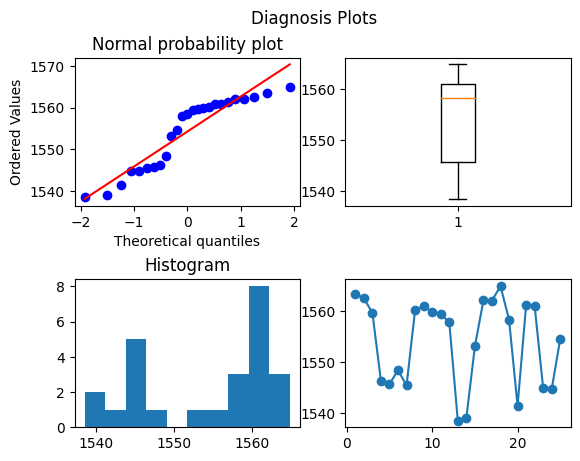

In [35]:
data_to_plot = all_layers_agg["mean"]
fig, axs = plt.subplots(2, 2)
fig.suptitle('Diagnosis Plots')
stats.probplot(data_to_plot, dist="norm", plot=axs[0,0])
axs[0,0].set_title('Normal probability plot')
axs[0,1].boxplot(data_to_plot)
fig.subplots_adjust(hspace=0.5)
axs[1,0].hist(data_to_plot)
axs[1,0].set_title('Histogram')
axs[1,1].plot(np.arange(1, len(data_to_plot)+1), data_to_plot, 'o-')
plt.show()

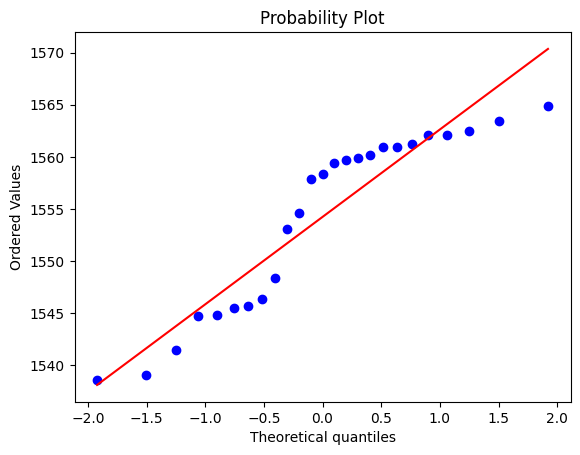

Shapiro-wilk test statistic = 0.870
Shapiro-wilk test p-value = 0.004
Runs test statistic = -1.706
Runs test p-value = 0.088



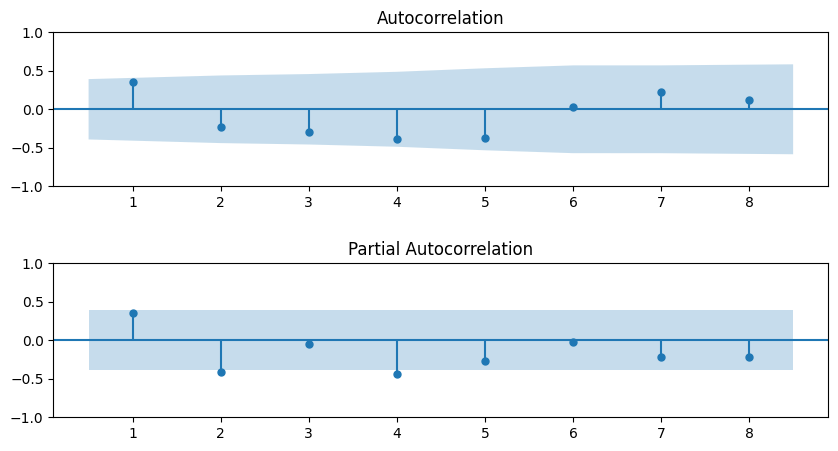

In [36]:
#Check for normality
_ = qda.Assumptions(all_layers_agg["mean"]).normality()
_ = qda.Assumptions(all_layers_agg["mean"]).independence()

Lambda = 48.791


c:\Users\atari\anaconda3\envs\QDA_environment_WIN\lib\site-packages\numpy\core\_methods.py:233: RuntimeWarning: overflow encountered in multiply
  x = um.multiply(x, x, out=x)
c:\Users\atari\anaconda3\envs\QDA_environment_WIN\lib\site-packages\numpy\core\_methods.py:244: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(x, axis, dtype, out, keepdims=keepdims, where=where)


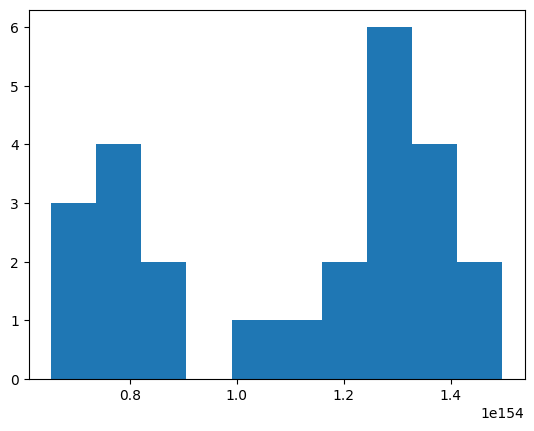

In [37]:
[data_BC, lmbda] = stats.boxcox(all_layers_agg["mean"])

print('Lambda = %.3f' % lmbda)

# Plot a histogram of the transformed data
plt.hist(data_BC)
plt.show()

---------------------
ARIMA MODEL RESULTS
---------------------
ARIMA model order: p=2, d=3, q=1

FINAL ESTIMATES OF PARAMETERS
-------------------------------
 Term    Coef  SE Coef  T-Value    P-Value
ar.L1  1.2431   0.1974   6.2962 3.0497e-10
ar.L2 -0.8301   0.1609  -5.1588 2.4860e-07
ma.L1 -0.9999 248.5304  -0.0040 9.9679e-01

RESIDUAL SUM OF SQUARES
-------------------------
  DF        SS      MS
19.0 1429.1244 75.2171

Ljung-Box Chi-Square Statistics
----------------------------------
 Lag  Chi-Square  P-Value
  12     13.8246   0.3121
Runs test statistic = 0.000
Runs test p-value = 1.000



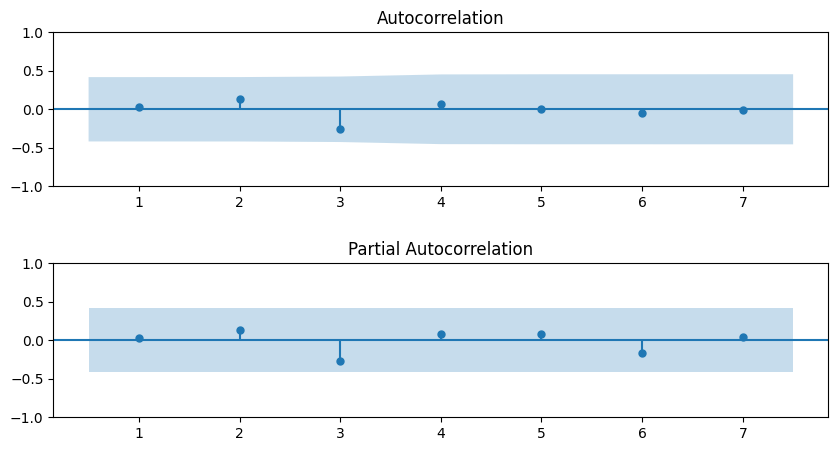

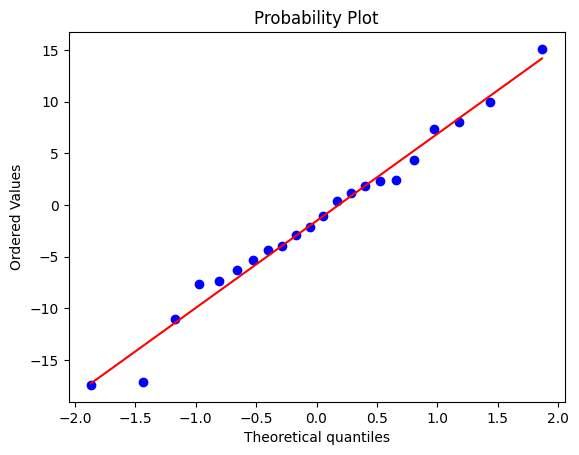

Shapiro-wilk test statistic = 0.982
Shapiro-wilk test p-value = 0.947


In [38]:
d = 3
model = qda.ARIMA(all_layers_agg["mean"], order=(2,d,1), add_constant=False)
qda.ARIMAsummary(model)
residuals = model.resid[d:] 
_ = qda.Assumptions(residuals).independence()
_ = qda.Assumptions(residuals).normality()

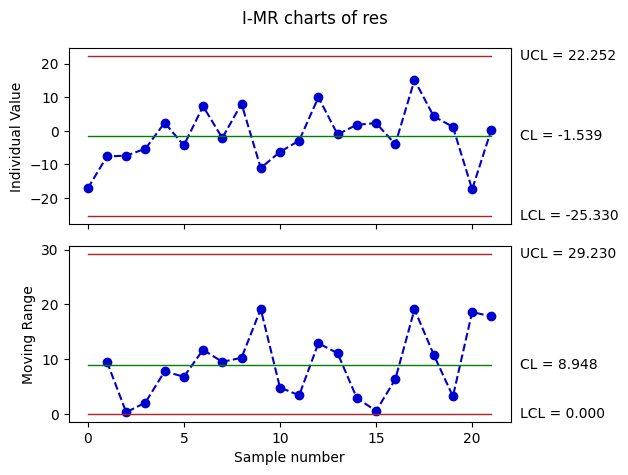

In [39]:
df_res = pd.DataFrame({'res': model.resid[d:]}).reset_index()
df_res= qda.ControlCharts.IMR(df_res, 'res',K=3)

- **Results**

The ARIMA(2,3,1) model produced valid residuals that met the assumptions for applying I-MR charts on the layer means, and the resulting control limits indicated potential for detecting process shifts. However, the integration factor of 3 suggests excessive differencing, which limits interpretability. In addition, the data are not fully sequential, violating a key assumption of ARIMA. These issues prevent this approach from being used to reliably monitor thermal behavior across layers.

# Approach 5: Using X Coordinate for Binning

- **Assumptions and preliminary data analysis**

This method assumes that spatial heterogeneity in melt pool temperature can be captured by examining temperature trends along the X-axis. Only one layer (224) was used for this trial. The X coordinate was quantile-binned into segments of ~500 points each, and the mean temperature per bin was used as the monitoring statistic. The core assumption is that within-layer thermal stability can be monitored by examining how average temperature evolves across horizontal (X) positions. Initial diagnostics showed that mean temperature values across X bins deviated from normality, prompting further modeling to remove structure and isolate usable residuals.

- **Proposed methodology** 

The binned means along X were modeled using an ARIMA(0,6,2) process with a constant, chosen to account for higher-order trends and eliminate autocorrelation. Diagnostic plots were used to check the residuals’ compliance with normality and independence. One outlier was found to heavily skew results, so an IQR-based outlier removal procedure was applied to the residuals. After filtering, the assumptions of normality and independence were reasonably met. An Individuals and Moving Range (I-MR) control chart was then applied to the cleaned residuals, using ±3σ limits, to detect spatial process deviations within a single layer along the X-axis.

In [40]:
layer224 = full_frame[full_frame["layer_id"]==224]
layer224

,t,x,y,z,layer_id,sensor0,sensor1,temp,track_id,track_orient,pos_rel,t_rel
0,1.2788e+08,38.119,-54.480,8.96,224,800.0,805.0,1580.9,0,271,0.0000,0.0
1,1.2788e+08,38.118,-54.489,8.96,224,807.0,801.0,1596.0,0,271,0.0072,10.0
2,1.2788e+08,38.119,-54.498,8.96,224,813.0,809.0,1593.2,0,271,0.0144,20.0
3,1.2788e+08,38.119,-54.508,8.96,224,813.0,824.0,1573.0,0,271,0.0216,30.0
4,1.2788e+08,38.121,-54.515,8.96,224,820.0,825.0,1581.0,0,271,0.0288,40.0
...,...,...,...,...,...,...,...,...,...,...,...,...
181075,1.2993e+08,26.094,-60.996,8.96,224,900.0,955.0,1524.8,121,271,5.6672,7120.0
181076,1.2993e+08,26.090,-60.990,8.96,224,907.0,956.0,1531.7,121,271,5.6752,7130.0
181077,1.2993e+08,26.088,-60.982,8.96,224,890.0,949.0,1519.9,121,271,5.6832,7140.0
181078,1.2993e+08,26.094,-60.981,8.96,224,896.0,929.0,1548.8,121,271,5.6911,7150.0


In [41]:
bin_number = layer224["x"].count() / 500
layer224["x_binned"] = pd.qcut(layer224["x"], int(bin_number), labels=False)
layer224["y_binned"] = pd.qcut(layer224["y"], int(bin_number), labels=False)
layer224

,t,x,y,z,layer_id,sensor0,sensor1,temp,track_id,track_orient,pos_rel,t_rel,x_binned,y_binned
0,1.2788e+08,38.119,-54.480,8.96,224,800.0,805.0,1580.9,0,271,0.0000,0.0,361,361
1,1.2788e+08,38.118,-54.489,8.96,224,807.0,801.0,1596.0,0,271,0.0072,10.0,361,361
2,1.2788e+08,38.119,-54.498,8.96,224,813.0,809.0,1593.2,0,271,0.0144,20.0,361,361
3,1.2788e+08,38.119,-54.508,8.96,224,813.0,824.0,1573.0,0,271,0.0216,30.0,361,361
4,1.2788e+08,38.121,-54.515,8.96,224,820.0,825.0,1581.0,0,271,0.0288,40.0,361,361
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
181075,1.2993e+08,26.094,-60.996,8.96,224,900.0,955.0,1524.8,121,271,5.6672,7120.0,0,169
181076,1.2993e+08,26.090,-60.990,8.96,224,907.0,956.0,1531.7,121,271,5.6752,7130.0,0,169
181077,1.2993e+08,26.088,-60.982,8.96,224,890.0,949.0,1519.9,121,271,5.6832,7140.0,0,169
181078,1.2993e+08,26.094,-60.981,8.96,224,896.0,929.0,1548.8,121,271,5.6911,7150.0,0,169


In [42]:
coordinates_agg = layer224.groupby(['x_binned'])['temp'].agg([
    'mean', 'std', 'min', 'max', 'median', 'count']).reset_index()

In [43]:
coordinates_agg

,x_binned,mean,std,min,max,median,count
0,0,1544.0864,11.7504,1513.8,1578.9,1543.7,501
1,1,1545.0019,9.8342,1510.1,1582.9,1545.6,513
2,2,1549.9371,11.6028,1522.2,1592.8,1549.6,491
3,3,1555.6960,11.3607,1517.7,1595.4,1557.0,503
4,4,1563.0353,10.0200,1527.9,1596.5,1563.1,504
...,...,...,...,...,...,...,...
357,357,1557.1747,9.5308,1522.0,1592.8,1556.8,494
358,358,1560.3662,11.6113,1530.0,1596.2,1560.1,497
359,359,1562.2305,9.6552,1536.0,1597.9,1561.6,505
360,360,1561.9578,10.3744,1528.9,1600.3,1561.8,502


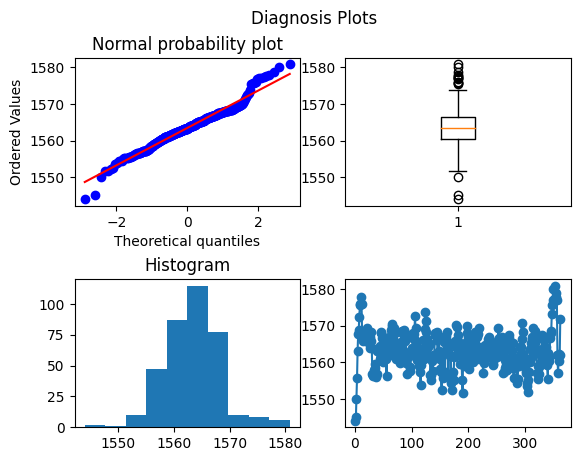

In [44]:
data_to_plot = coordinates_agg["mean"]
fig, axs = plt.subplots(2, 2)
fig.suptitle('Diagnosis Plots')
stats.probplot(data_to_plot, dist="norm", plot=axs[0,0])
axs[0,0].set_title('Normal probability plot')
axs[0,1].boxplot(data_to_plot)
fig.subplots_adjust(hspace=0.5)
axs[1,0].hist(data_to_plot)
axs[1,0].set_title('Histogram')
axs[1,1].plot(np.arange(1, len(data_to_plot)+1), data_to_plot, 'o-')
plt.show()

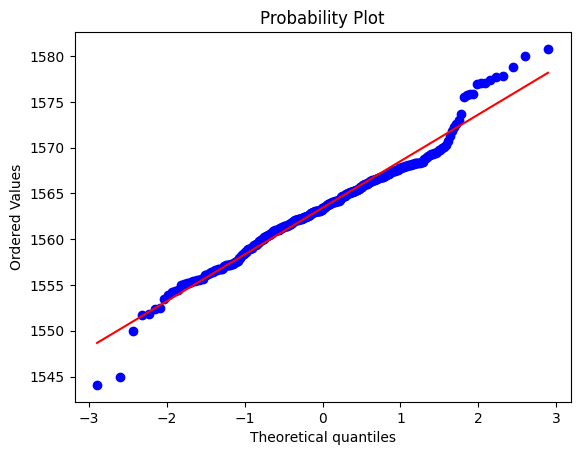

Shapiro-wilk test statistic = 0.975
Shapiro-wilk test p-value = 0.000
Runs test statistic = -7.788
Runs test p-value = 0.000



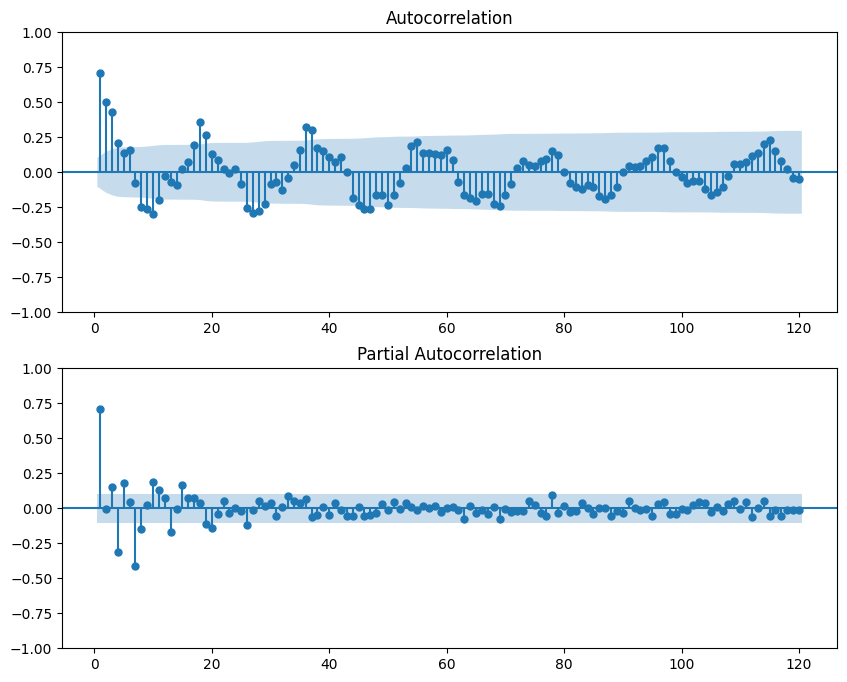

In [45]:
_ = qda.Assumptions(coordinates_agg["mean"]).normality()
_ = qda.Assumptions(coordinates_agg["mean"]).independence()

---------------------
ARIMA MODEL RESULTS
---------------------
ARIMA model order: p=0, d=6, q=2

FINAL ESTIMATES OF PARAMETERS
-------------------------------
 Term   Coef  SE Coef  T-Value    P-Value
const 0.1907   0.4861   0.3923 6.9487e-01
ma.L1 0.7641   0.0430  17.7702 1.2020e-70
ma.L2 0.4746   0.0430  11.0393 2.4698e-28

RESIDUAL SUM OF SQUARES
-------------------------
   DF        SS      MS
353.0 6381.3357 18.0774

Ljung-Box Chi-Square Statistics
----------------------------------
 Lag  Chi-Square     P-Value
  12    265.6846  7.2668e-50
  24    368.5083  2.1109e-63
  36    496.0709  2.9237e-82
  48    622.2935 6.7551e-101
Runs test statistic = 0.002
Runs test p-value = 0.998



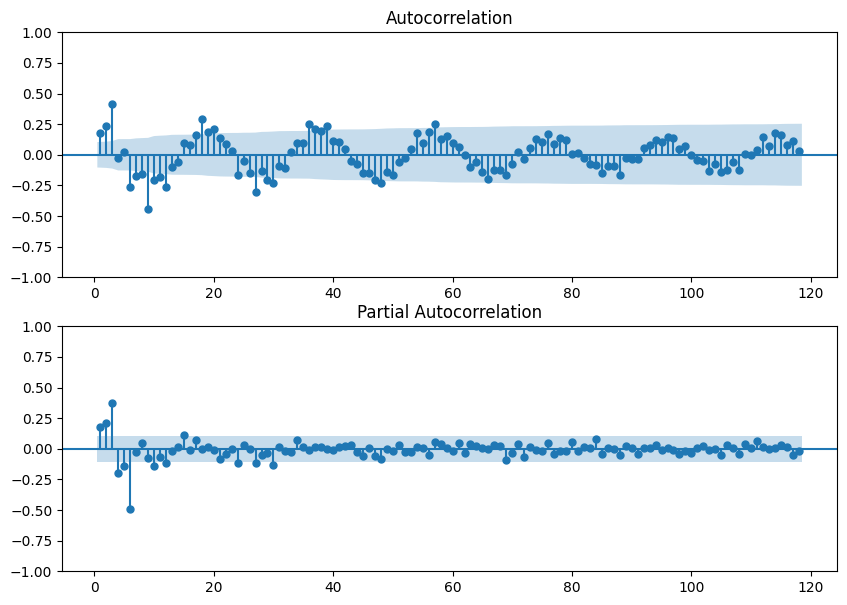

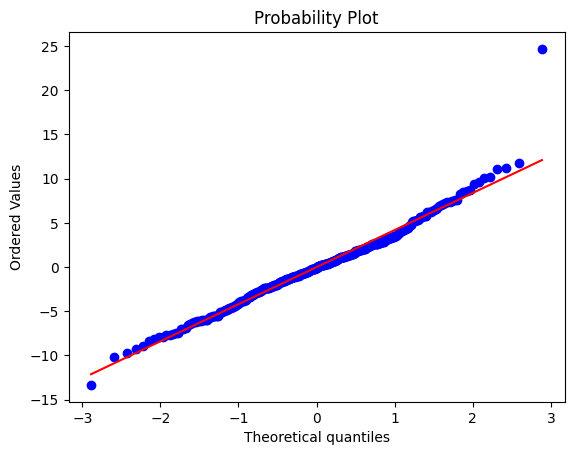

Shapiro-wilk test statistic = 0.972
Shapiro-wilk test p-value = 0.000


In [46]:
d = 6
model = qda.ARIMA(coordinates_agg["mean"], order=(0,d,2), add_constant=True)
qda.ARIMAsummary(model)
residuals = model.resid[d:] 
_ = qda.Assumptions(residuals).independence()
_ = qda.Assumptions(residuals).normality()

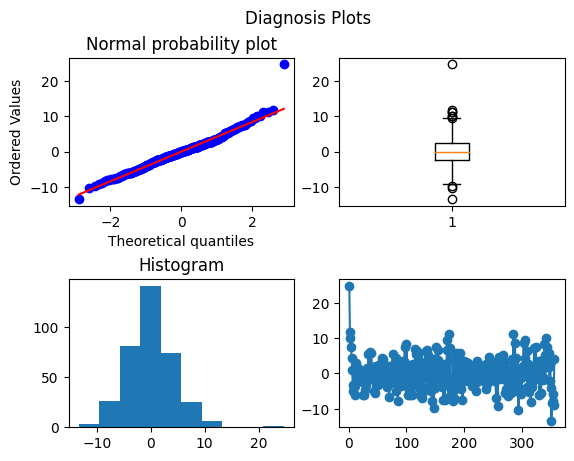

In [47]:
data_to_plot = residuals
fig, axs = plt.subplots(2, 2)
fig.suptitle('Diagnosis Plots')
stats.probplot(data_to_plot, dist="norm", plot=axs[0,0])
axs[0,0].set_title('Normal probability plot')
axs[0,1].boxplot(data_to_plot)
fig.subplots_adjust(hspace=0.5)
axs[1,0].hist(data_to_plot)
axs[1,0].set_title('Histogram')
axs[1,1].plot(np.arange(1, len(data_to_plot)+1), data_to_plot, 'o-')
plt.show()

There seems to be one great outlier. if we get rid of that 

In [48]:
Q1 = residuals.quantile(0.25)
Q3 = residuals.quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

residuals = residuals[(residuals > lower_bound) & 
                     (residuals < upper_bound)].reset_index(drop=True)

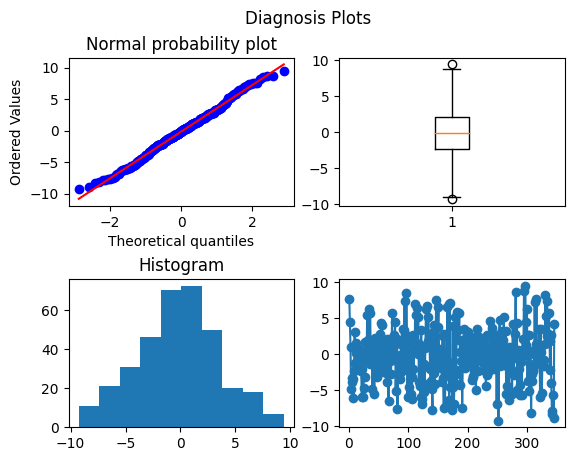

In [49]:
data_to_plot = residuals
fig, axs = plt.subplots(2, 2)
fig.suptitle('Diagnosis Plots')
stats.probplot(data_to_plot, dist="norm", plot=axs[0,0])
axs[0,0].set_title('Normal probability plot')
axs[0,1].boxplot(data_to_plot)
fig.subplots_adjust(hspace=0.5)
axs[1,0].hist(data_to_plot)
axs[1,0].set_title('Histogram')
axs[1,1].plot(np.arange(1, len(data_to_plot)+1), data_to_plot, 'o-')
plt.show()

Runs test statistic = 0.108
Runs test p-value = 0.914



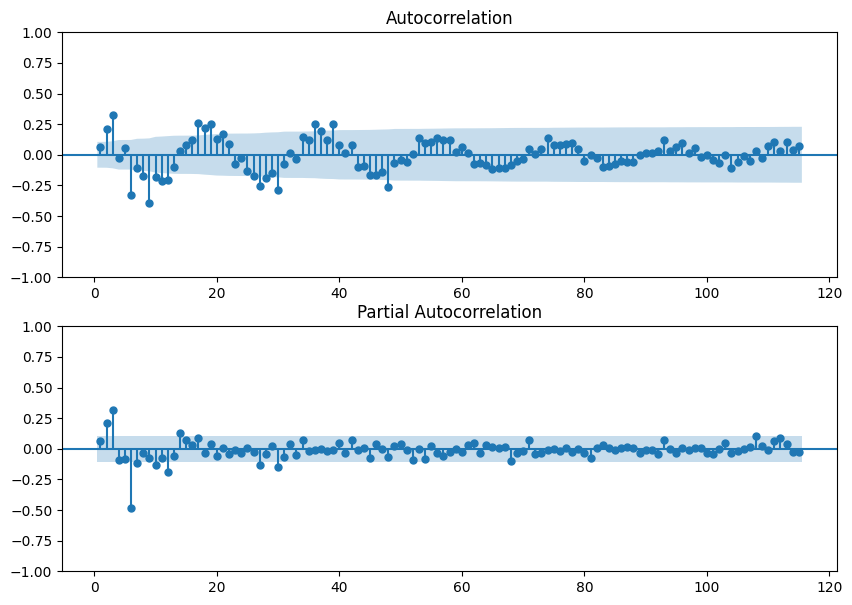

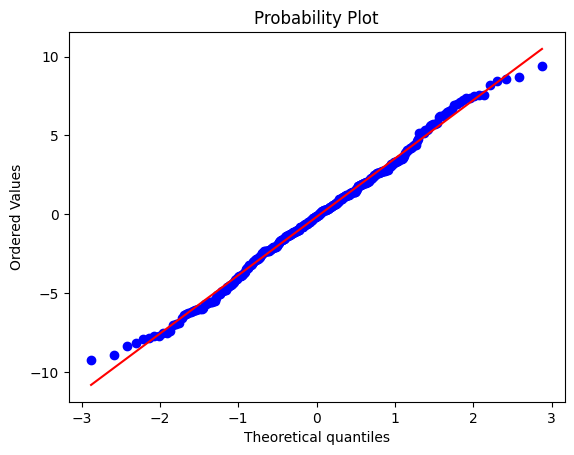

Shapiro-wilk test statistic = 0.994
Shapiro-wilk test p-value = 0.227


In [50]:
_ = qda.Assumptions(residuals).independence()
_ = qda.Assumptions(residuals).normality()

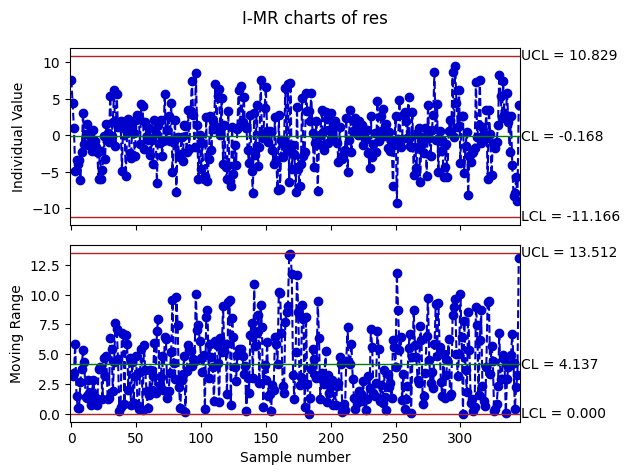

In [51]:
df_res = pd.DataFrame({'res': residuals})
df_res= qda.ControlCharts.IMR(df_res, 'res',K=3)

- **Results**

The ARIMA model, combined with outlier removal, produced residuals that conformed well to control chart assumptions. The final I-MR chart provided interpretable limits and visual flags for out-of-control conditions along the X-axis. This method proved effective in identifying anomalies within a single layer and demonstrates that spatial binning (rather than time-based) can offer useful monitoring perspectives. However, it remains layer-specific and may need adaptation to support multi-layer or general-process monitoring. Overall, this approach yielded one of the cleanest control charts so far and shows strong potential for detecting spatial thermal instabilities.

# Approach 6 Coordinate Aggregation with Y

- **Assumptions and preliminary data analysis**

This approach assumes that spatial process variation can be effectively captured by examining temperature behavior across vertical positions (y) within a single layer (layer 224). The data was binned along the y coordinate into quantile-based intervals (~500 points per bin). The hypothesis is that printing dynamics might vary systematically along the vertical axis due to scan path orientation or thermal dissipation effects. Initial diagnostic plots on the binned mean temperatures showed left skewness and non-normal distribution. Visual inspection via scatter plots suggested that outliers were concentrated in the outermost regions of the build area.

- **Proposed methodology** 

To improve model behavior, the analysis excluded the extreme y bins (outside the 50–299 range) and retained only the central portion of the build area. This reduced dataset showed better distributional properties. The mean temperatures across remaining y bins were modeled using an ARIMA(0,1,2) process with a constant. Model diagnostics confirmed that residuals passed the normality and independence checks. An I-MR control chart was then created based on these residuals. This method focused on spatial trends along the Y-axis and deliberately avoided transformation, relying instead on outlier exclusion to produce cleaner modeling input.

In [52]:
coordinates_agg_y = layer224.groupby(['y_binned'])['temp'].agg([
    'mean', 'std', 'min', 'max', 'median', 'count']).reset_index()

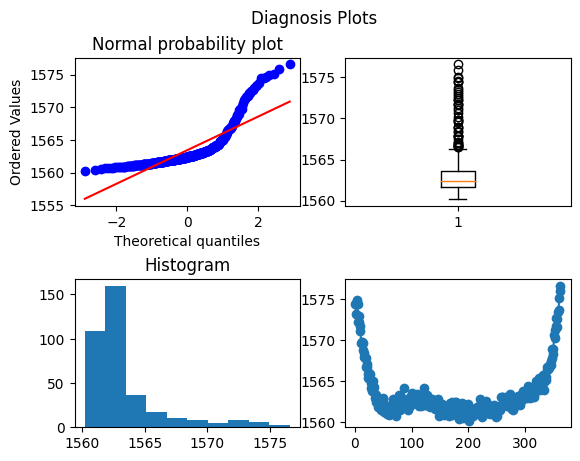

In [53]:
data_to_plot = coordinates_agg_y["mean"]
fig, axs = plt.subplots(2, 2)
fig.suptitle('Diagnosis Plots')
stats.probplot(data_to_plot, dist="norm", plot=axs[0,0])
axs[0,0].set_title('Normal probability plot')
axs[0,1].boxplot(data_to_plot)
fig.subplots_adjust(hspace=0.5)
axs[1,0].hist(data_to_plot)
axs[1,0].set_title('Histogram')
axs[1,1].plot(np.arange(1, len(data_to_plot)+1), data_to_plot, 'o-')
plt.show()

There seems to be a left skew with the data. Let's inspect closer

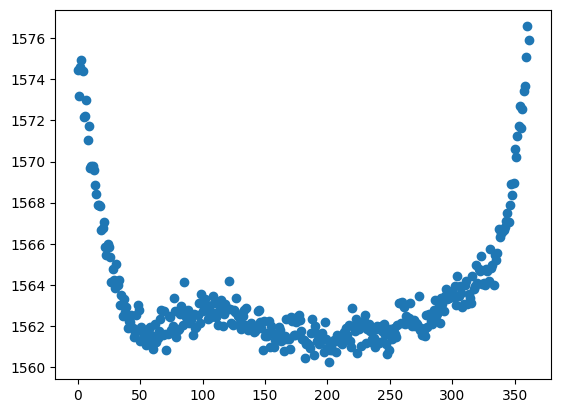

In [54]:
plt.scatter(coordinates_agg_y["y_binned"],coordinates_agg_y["mean"],)

we can make up a model that works for middle layers, and not the extreme ones

In [55]:
coordinates_agg_y_reduced = coordinates_agg_y[(coordinates_agg_y["y_binned"]>=50 )& (coordinates_agg_y["y_binned"]<300)].reset_index()

In [56]:
coordinates_agg_y_reduced.describe()

,index,y_binned,mean,std,min,max,median,count
count,250.000,250.000,250.0000,250.0000,250.0000,250.0000,250.0000,250.000
mean,174.500,174.500,1562.0140,11.6770,1524.8972,1601.9736,1561.8612,500.192
std,72.313,72.313,0.7383,0.4829,5.5593,6.7366,0.8140,8.174
min,50.000,50.000,1560.2211,10.4930,1498.4000,1590.2000,1559.8500,477.000
25%,112.250,112.250,1561.5051,11.3230,1521.3500,1596.9500,1561.3000,495.000
50%,174.500,174.500,1561.9858,11.6447,1526.0000,1600.8000,1561.8500,500.500
75%,236.750,236.750,1562.4918,12.0013,1528.6750,1605.7500,1562.4000,505.000
max,299.000,299.000,1564.1982,13.2435,1536.5000,1628.5000,1564.2500,522.000


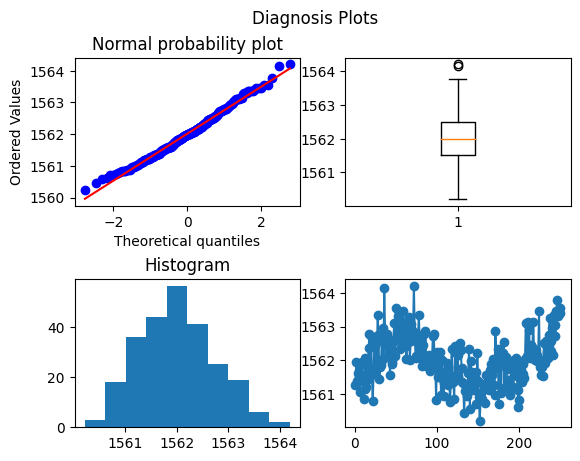

In [57]:
data_to_plot = coordinates_agg_y_reduced["mean"]
fig, axs = plt.subplots(2, 2)
fig.suptitle('Diagnosis Plots')
stats.probplot(data_to_plot, dist="norm", plot=axs[0,0])
axs[0,0].set_title('Normal probability plot')
axs[0,1].boxplot(data_to_plot)
fig.subplots_adjust(hspace=0.5)
axs[1,0].hist(data_to_plot)
axs[1,0].set_title('Histogram')
axs[1,1].plot(np.arange(1, len(data_to_plot)+1), data_to_plot, 'o-')
plt.show()

Runs test statistic = -8.342
Runs test p-value = 0.000



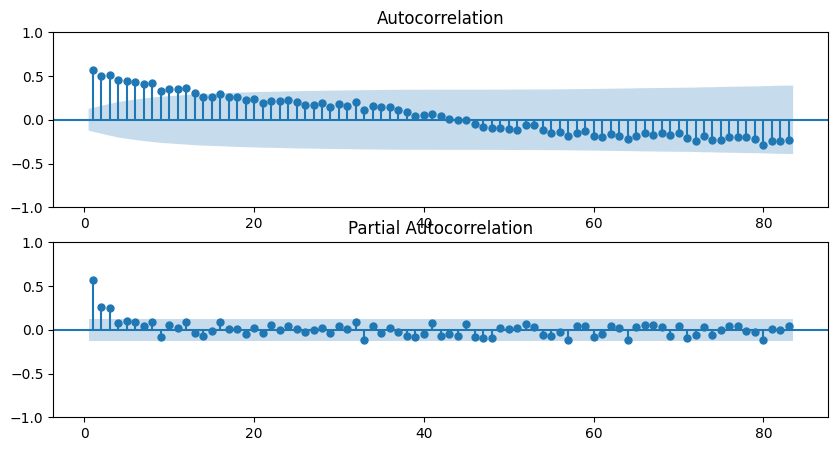

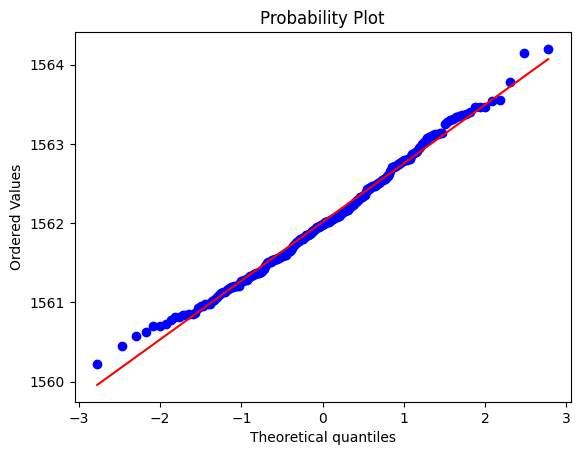

Shapiro-wilk test statistic = 0.991
Shapiro-wilk test p-value = 0.152


In [58]:
_ = qda.Assumptions(coordinates_agg_y_reduced["mean"]).independence()
_ = qda.Assumptions(coordinates_agg_y_reduced["mean"]).normality()

---------------------
ARIMA MODEL RESULTS
---------------------
ARIMA model order: p=0, d=1, q=2

FINAL ESTIMATES OF PARAMETERS
-------------------------------
 Term    Coef  SE Coef  T-Value    P-Value
const  0.0072   0.0079   0.9143 3.6058e-01
ma.L1 -0.7087   0.0681 -10.4042 2.3730e-25
ma.L2 -0.0744   0.0645  -1.1536 2.4867e-01

RESIDUAL SUM OF SQUARES
-------------------------
   DF      SS     MS
246.0 75.1653 0.3055

Ljung-Box Chi-Square Statistics
----------------------------------
 Lag  Chi-Square  P-Value
  12      7.4355   0.8275
  24     12.6707   0.9712
  36     24.2572   0.9320
  48     32.0260   0.9630
Runs test statistic = -0.829
Runs test p-value = 0.407



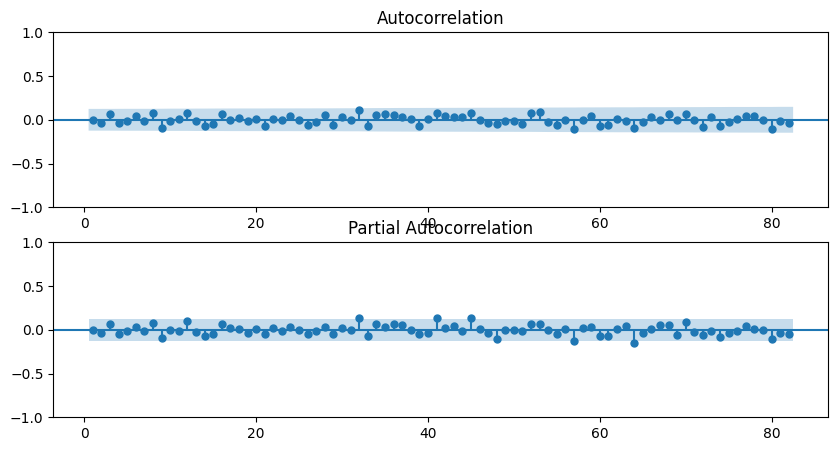

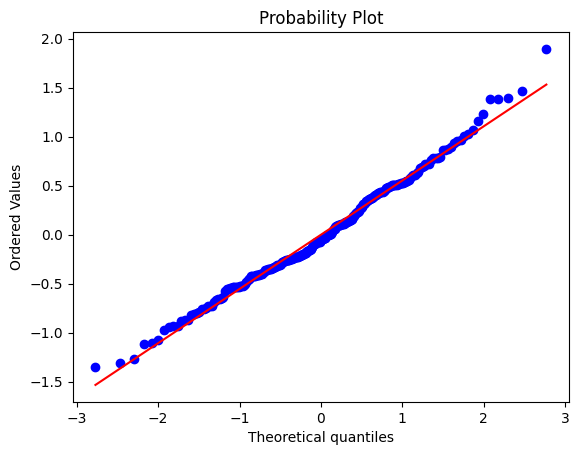

Shapiro-wilk test statistic = 0.991
Shapiro-wilk test p-value = 0.113


In [59]:
d = 1
model = qda.ARIMA(coordinates_agg_y_reduced["mean"], order=(0,d,2), add_constant=True)
qda.ARIMAsummary(model)
residuals = model.resid[d:] 
_ = qda.Assumptions(residuals).independence()
_ = qda.Assumptions(residuals).normality()

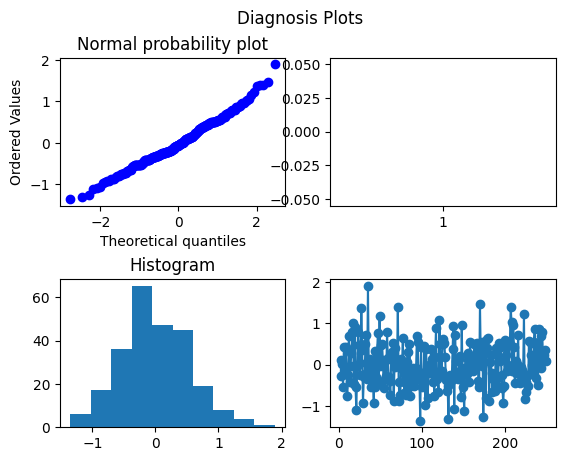

In [60]:
data_to_plot = residuals
fig, axs = plt.subplots(2, 2)
fig.suptitle('Diagnosis Plots')
stats.probplot(data_to_plot, dist="norm", plot=axs[0,0])
axs[0,0].set_title('Normal probability plot')
axs[0,1].boxplot(data_to_plot)
fig.subplots_adjust(hspace=0.5)
axs[1,0].hist(data_to_plot)
axs[1,0].set_title('Histogram')
axs[1,1].plot(np.arange(1, len(data_to_plot)+1), data_to_plot, 'o-')
plt.show()

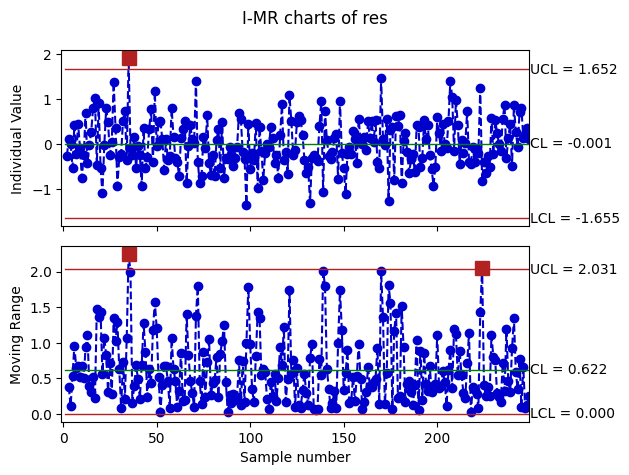

In [61]:
df_res = pd.DataFrame({'res': residuals})
df_res= qda.ControlCharts.IMR(df_res, 'res',K=3)

- **Results**

The reduced dataset and ARIMA(0,1,2) model yielded well-behaved residuals suitable for Shewhart-type monitoring. The resulting I-MR control chart presented stable control limits and revealed potential deviations within the vertical spatial axis. This supports the idea that build-area-specific effects may be localized and that selectively filtering out noisy edge bins can enhance detection performance. The approach is spatially focused and interpretable, making it particularly relevant for detecting systematic instability along scanning directions. However, as with the X-based method (Approach 5), generalizing this layer-specific strategy to the full build remains an open question.

# Approach 7A: Binning X coordinates, even between layers

- **Assumptions and preliminary data analysis**

This approach assumes that by binning all data across layers along the X-axis, one can detect cross-layer spatial irregularities. The entire dataset was binned using the x coordinate, with approximately 5,000 values per bin. The mean temperature for each x_binned group was computed. Initial diagnostics revealed extreme behavior at the lowest and highest X values, which caused skewness and non-normality. To mitigate this, the analysis was restricted to the central X bins (100 to 800), effectively removing edge-induced anomalies and focusing on the more stable central build region. The reduced dataset appeared more symmetrical and independent.

- **Proposed methodology** 

Mean temperature values across the filtered X bins were modeled using an ARIMA(3,15,0) model with a constant. The high differencing order (d=15) was necessary to achieve approximate stationarity. After fitting, diagnostic checks confirmed that residuals were both normally distributed and independent—satisfying the conditions for Shewhart control charts. An I-MR chart was constructed using these residuals, enabling the detection of temperature shifts across horizontal build sections aggregated from multiple layers. This method extends earlier X-axis analyses by scaling them across the full print height, assuming a consistent spatial relationship layer-to-layer. However, the high differencing order likely results in significant loss of information, limiting the practical value of this approach.

In [62]:
bin_number = full_frame["x"].count() / 5000
full_frame["x_binned"] = pd.qcut(full_frame["x"], int(bin_number), labels=False)
full_frame["y_binned"] = pd.qcut(full_frame["y"], int(bin_number), labels=False)
full_frame

,t,x,y,z,layer_id,sensor0,sensor1,temp,track_id,track_orient,pos_rel,t_rel,x_binned,y_binned
0,1.2788e+08,38.119,-54.480,8.96,224,800.0,805.0,1580.9,0,271,0.0000,0.0,899,901
1,1.2788e+08,38.118,-54.489,8.96,224,807.0,801.0,1596.0,0,271,0.0072,10.0,899,901
2,1.2788e+08,38.119,-54.498,8.96,224,813.0,809.0,1593.2,0,271,0.0144,20.0,899,901
3,1.2788e+08,38.119,-54.508,8.96,224,813.0,824.0,1573.0,0,271,0.0216,30.0,899,901
4,1.2788e+08,38.121,-54.515,8.96,224,820.0,825.0,1581.0,0,271,0.0288,40.0,899,901
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4512001,8.6335e+07,26.050,-54.754,22.92,573,902.0,936.0,1547.9,148,254,0.0876,80.0,0,886
4512002,8.6335e+07,26.052,-54.745,22.92,573,908.0,937.0,1553.7,148,254,0.0986,90.0,0,887
4512003,8.6335e+07,26.056,-54.738,22.92,573,915.0,940.0,1558.5,148,254,0.1095,100.0,0,887
4512004,8.6335e+07,26.058,-54.727,22.92,573,895.0,932.0,1544.2,148,254,0.1205,110.0,1,888


In [63]:
full_frame_agg_x = full_frame.groupby(['x_binned'])['temp'].agg([
    'mean', 'std', 'min', 'max', 'median', 'count']).reset_index()
full_frame_agg_x


,x_binned,mean,std,min,max,median,count
0,0,1577.2439,14.1438,1516.9,1631.5,1578.30,5091
1,1,1573.0349,15.5450,1513.4,1633.7,1573.70,4986
2,2,1568.5129,17.2980,1514.5,1635.2,1569.90,4971
3,3,1566.7902,17.0959,1510.8,1631.5,1567.50,4998
4,4,1566.0793,16.4802,1506.4,1639.1,1566.30,5162
...,...,...,...,...,...,...,...
897,897,1560.6229,20.3805,1475.6,1623.5,1563.15,5140
898,898,1563.5951,19.1931,1486.7,1633.5,1565.10,5003
899,899,1563.9835,21.1419,1488.0,1627.6,1566.40,4914
900,900,1559.3009,20.3447,1487.8,1620.2,1561.10,4955


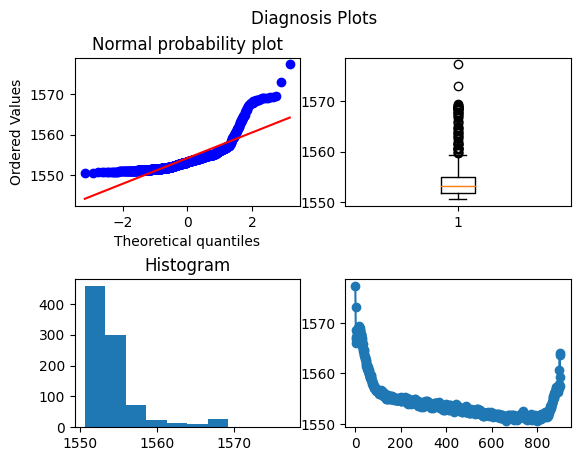

In [64]:
data_to_plot = full_frame_agg_x["mean"]
fig, axs = plt.subplots(2, 2)
fig.suptitle('Diagnosis Plots')
stats.probplot(data_to_plot, dist="norm", plot=axs[0,0])
axs[0,0].set_title('Normal probability plot')
axs[0,1].boxplot(data_to_plot)
fig.subplots_adjust(hspace=0.5)
axs[1,0].hist(data_to_plot)
axs[1,0].set_title('Histogram')
axs[1,1].plot(np.arange(1, len(data_to_plot)+1), data_to_plot, 'o-')
plt.show()

Like the single layer y, the graph shows extreme values on too low and high x values. If we make a model for values that are not that extreme, there might be a promising model

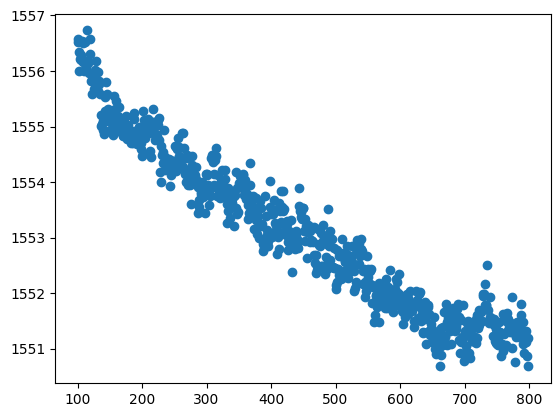

In [65]:
plt.scatter(full_frame_agg_x["x_binned"][100:800],full_frame_agg_x["mean"][100:800])

In [66]:
full_frame_agg_x_reduced = full_frame_agg_x[(full_frame_agg_x['x_binned'] < 800) & 
                     (full_frame_agg_x['x_binned'] > 100)].reset_index(drop=True)

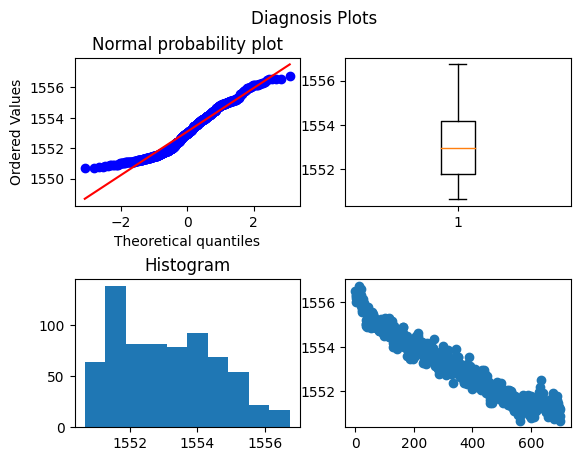

In [67]:
data_to_plot = full_frame_agg_x_reduced["mean"]
fig, axs = plt.subplots(2, 2)
fig.suptitle('Diagnosis Plots')
stats.probplot(data_to_plot, dist="norm", plot=axs[0,0])
axs[0,0].set_title('Normal probability plot')
axs[0,1].boxplot(data_to_plot)
fig.subplots_adjust(hspace=0.5)
axs[1,0].hist(data_to_plot)
axs[1,0].set_title('Histogram')
axs[1,1].plot(np.arange(1, len(data_to_plot)+1), data_to_plot, 'o-')
plt.show()

Runs test statistic = -23.043
Runs test p-value = 0.000



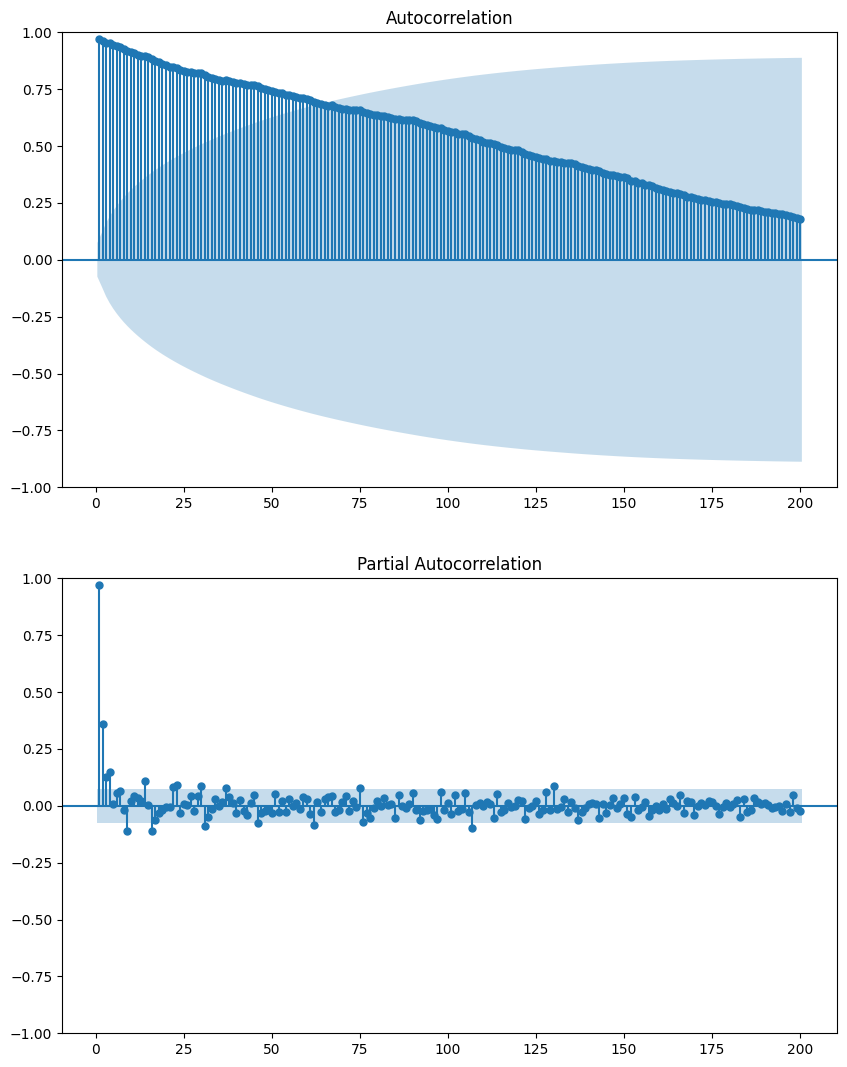

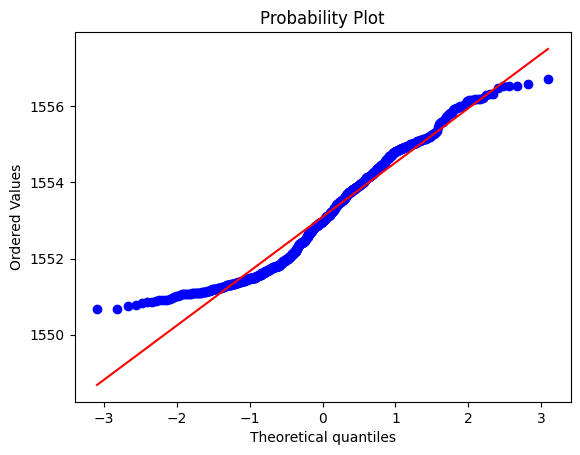

Shapiro-wilk test statistic = 0.956
Shapiro-wilk test p-value = 0.000


In [68]:
_ = qda.Assumptions(full_frame_agg_x_reduced["mean"]).independence()
_ = qda.Assumptions(full_frame_agg_x_reduced["mean"]).normality()

---------------------
ARIMA MODEL RESULTS
---------------------
ARIMA model order: p=3, d=15, q=0

FINAL ESTIMATES OF PARAMETERS
-------------------------------
 Term    Coef  SE Coef  T-Value    P-Value
const -0.1135   0.0381  -2.9828 2.8558e-03
ar.L1  0.2179   0.0399   5.4564 4.8586e-08
ar.L2  0.3454   0.0375   9.2046 3.4282e-20
ar.L3  0.1129   0.0363   3.1095 1.8737e-03

RESIDUAL SUM OF SQUARES
-------------------------
   DF      SS     MS
680.0 70.9875 0.1044

Ljung-Box Chi-Square Statistics
----------------------------------
 Lag  Chi-Square    P-Value
  12     39.8369 7.6530e-05
  24    228.8841 2.4276e-35
  36    243.3976 1.2893e-32
  48    264.0458 1.2821e-31
Runs test statistic = -0.075
Runs test p-value = 0.941



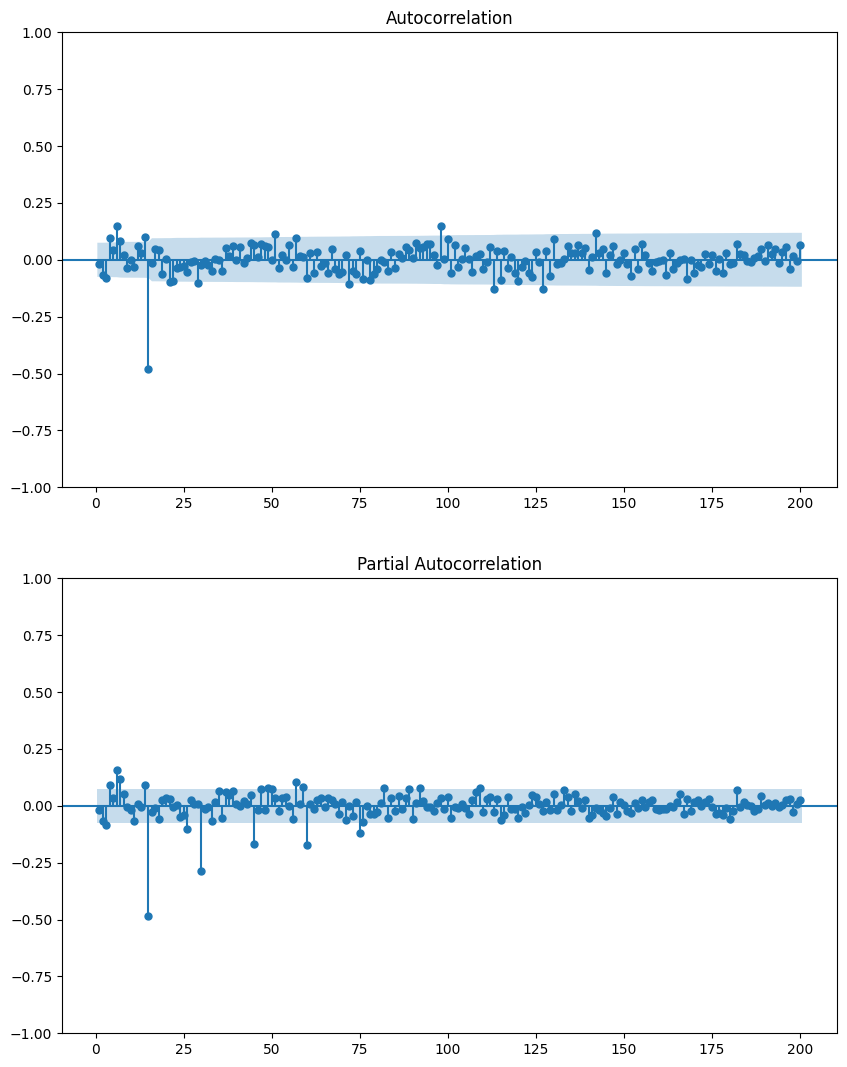

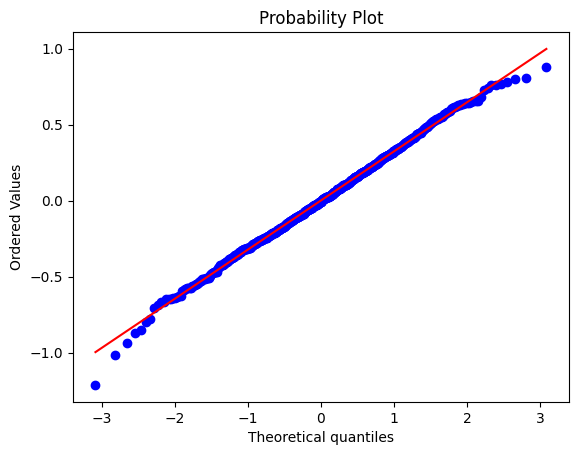

Shapiro-wilk test statistic = 0.998
Shapiro-wilk test p-value = 0.511


In [69]:
d = 15
model = qda.ARIMA(full_frame_agg_x_reduced["mean"], order=(3,d,0), add_constant=True)
qda.ARIMAsummary(model)
residuals = model.resid[d:] 
_ = qda.Assumptions(residuals).independence()
_ = qda.Assumptions(residuals).normality()

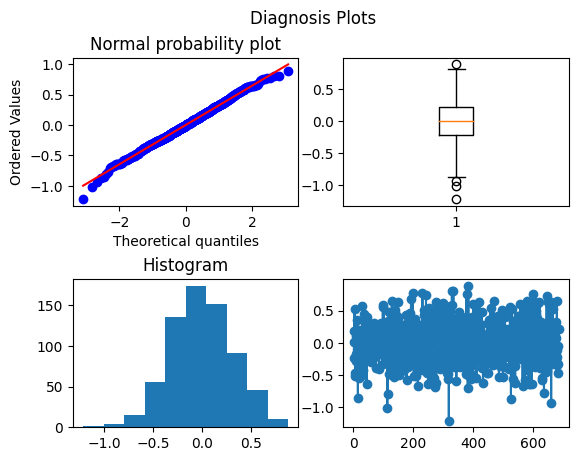

In [70]:
data_to_plot = residuals
fig, axs = plt.subplots(2, 2)
fig.suptitle('Diagnosis Plots')
stats.probplot(data_to_plot, dist="norm", plot=axs[0,0])
axs[0,0].set_title('Normal probability plot')
axs[0,1].boxplot(data_to_plot)
fig.subplots_adjust(hspace=0.5)
axs[1,0].hist(data_to_plot)
axs[1,0].set_title('Histogram')
axs[1,1].plot(np.arange(1, len(data_to_plot)+1), data_to_plot, 'o-')
plt.show()

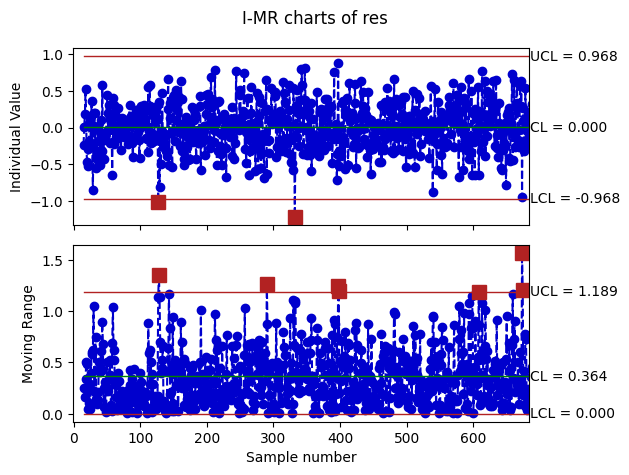

In [71]:
df_res = pd.DataFrame({'res': residuals})
df_res= qda.ControlCharts.IMR(df_res, 'res',K=3)

- **Results**

The reduced and differenced model resulted in stable residuals and a well-structured I-MR control chart, suggesting that consistent process signatures may exist along the X-axis across layers. Excluding the extremes was critical in reaching this result. However, the need for high-order differencing raises concerns about excessive information loss, which may undermine the reliability of the detected patterns. Although the model removed autocorrelation and noise, the extent of differencing limits confidence in the results. While the method offers scalability as a multi-layer spatial approach, its generalizability and effectiveness for cross-layer consistency checks require further validation.



# Approach 7B: Binning Y coordinates, even between layers

- **Assumptions and preliminary data analysis**

This approach investigates temperature behavior across layers by aggregating data based on the Y-axis (track-wise analysis). It assumes that melt pool temperature is influenced by scanning direction and track positioning, and that this influence is consistent across layers. Initially, mean temperature values were computed per track and visualized. Outliers, especially in early and late tracks, were traced to insufficient data points. These were excluded using a size threshold (10–20% of average track size), significantly improving the data’s distribution. Multiple rounds of diagnostics were run, including normality plots and residual tracking, to prepare the data for modeling.

- **Proposed methodology** 

Mean, min, and max temperatures per track were separately modeled. After cleaning, ARIMA models were applied to the mean and later to the max and min values. For mean values, an ARIMA(2,2,0) model was selected, followed by control charting. The max values were modeled with an ARIMA(1,0,2), and the resulting residuals underwent Box-Cox transformation (λ ≈ 1), producing well-behaved data for Shewhart control chart construction. A similar strategy was applied to min values using ARIMA(0,2,1). Residuals from each model were refined by outlier removal, and their distributional assumptions were confirmed prior to chart construction. This method combines cross-layer stability checks with spatial alignment.




In [72]:
full_frame_agg_y = full_frame.groupby(['y_binned'])['temp'].agg([
    'mean', 'std', 'min', 'max', 'median', 'count']).reset_index()
full_frame_agg_y


,y_binned,mean,std,min,max,median,count
0,0,1568.9171,15.4934,1494.0,1623.8,1570.0,5090
1,1,1568.2607,15.6884,1512.1,1633.9,1569.1,5051
2,2,1568.4561,16.3770,1510.0,1637.4,1569.2,4991
3,3,1569.0747,16.2893,1508.0,1623.6,1569.9,5051
4,4,1567.1424,16.1442,1504.8,1629.6,1568.3,4898
...,...,...,...,...,...,...,...
897,897,1558.4350,27.9254,1444.6,1616.7,1565.9,4916
898,898,1558.7882,28.3732,1443.0,1622.9,1566.7,5066
899,899,1560.6994,26.2320,1449.9,1625.6,1566.7,4897
900,900,1562.1105,25.0641,1441.2,1621.9,1566.9,4905


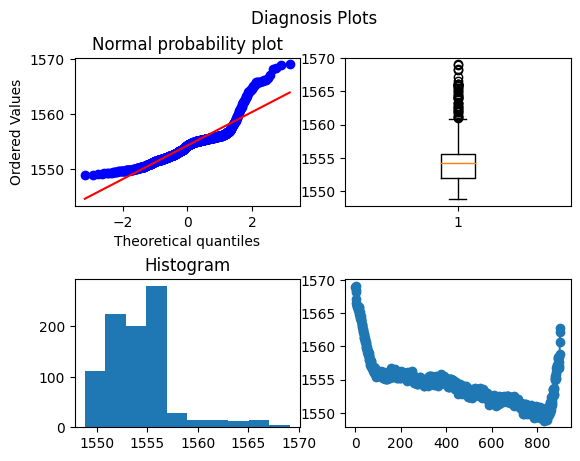

In [73]:
data_to_plot = full_frame_agg_y["mean"]
fig, axs = plt.subplots(2, 2)
fig.suptitle('Diagnosis Plots')
stats.probplot(data_to_plot, dist="norm", plot=axs[0,0])
axs[0,0].set_title('Normal probability plot')
axs[0,1].boxplot(data_to_plot)
fig.subplots_adjust(hspace=0.5)
axs[1,0].hist(data_to_plot)
axs[1,0].set_title('Histogram')
axs[1,1].plot(np.arange(1, len(data_to_plot)+1), data_to_plot, 'o-')
plt.show()

In [74]:
full_frame_agg_y_reduced = full_frame_agg_y[(full_frame_agg_y['y_binned'] < 800) & 
                     (full_frame_agg_y['y_binned'] > 100)].reset_index(drop=True)

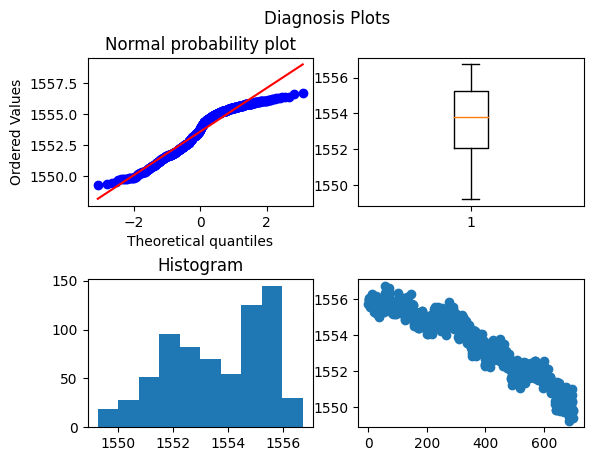

In [75]:
data_to_plot = full_frame_agg_y_reduced["mean"]
fig, axs = plt.subplots(2, 2)
fig.suptitle('Diagnosis Plots')
stats.probplot(data_to_plot, dist="norm", plot=axs[0,0])
axs[0,0].set_title('Normal probability plot')
axs[0,1].boxplot(data_to_plot)
fig.subplots_adjust(hspace=0.5)
axs[1,0].hist(data_to_plot)
axs[1,0].set_title('Histogram')
axs[1,1].plot(np.arange(1, len(data_to_plot)+1), data_to_plot, 'o-')
plt.show()

---------------------
ARIMA MODEL RESULTS
---------------------
ARIMA model order: p=3, d=15, q=0

FINAL ESTIMATES OF PARAMETERS
-------------------------------
 Term    Coef  SE Coef  T-Value    P-Value
const -0.1258   0.0436  -2.8868 3.8917e-03
ar.L1  0.2724   0.0394   6.9125 4.7614e-12
ar.L2  0.3167   0.0384   8.2446 1.6573e-16
ar.L3  0.1022   0.0383   2.6668 7.6570e-03

RESIDUAL SUM OF SQUARES
-------------------------
   DF      SS     MS
680.0 84.6109 0.1244

Ljung-Box Chi-Square Statistics
----------------------------------
 Lag  Chi-Square    P-Value
  12     31.2651 1.7947e-03
  24    207.3763 3.8800e-31
  36    224.0485 5.0864e-29
  48    255.2485 4.8180e-30
Runs test statistic = -0.230
Runs test p-value = 0.818



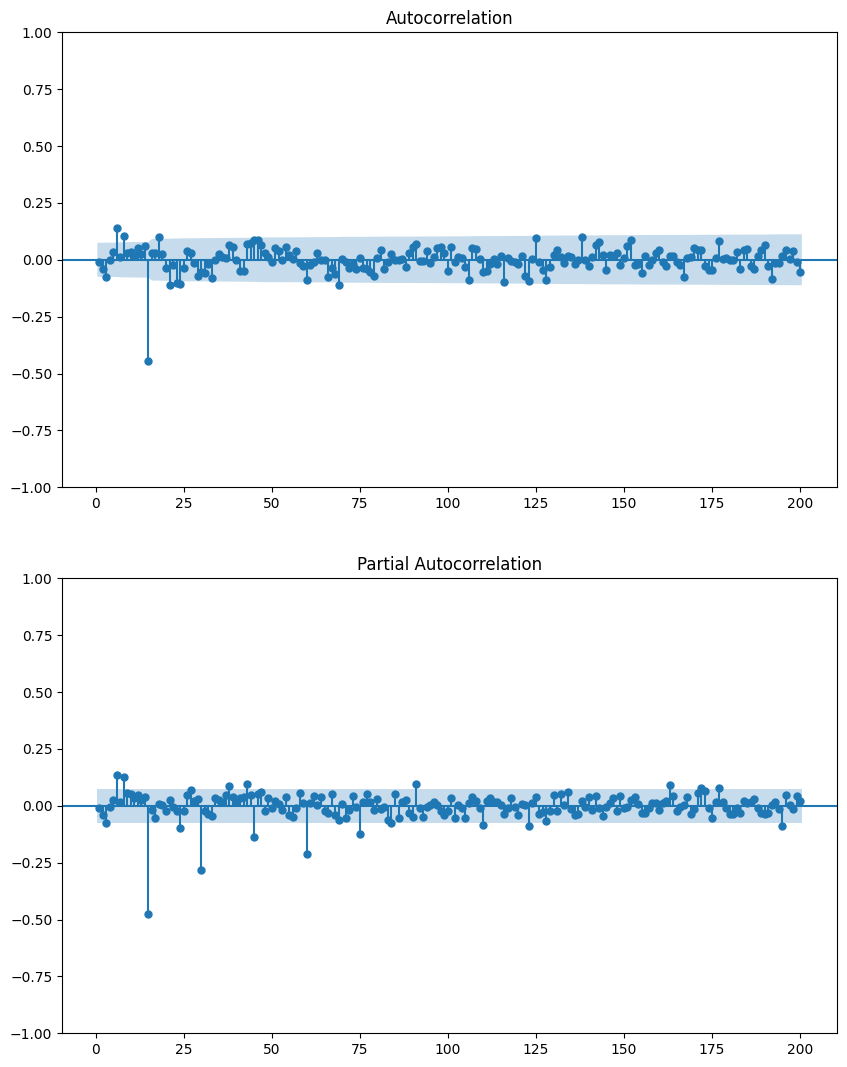

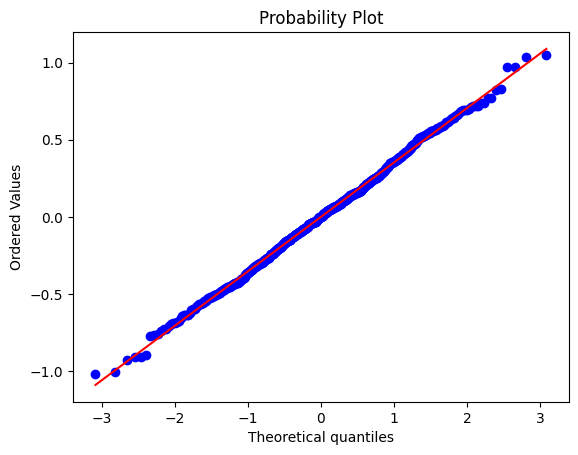

Shapiro-wilk test statistic = 0.998
Shapiro-wilk test p-value = 0.694


In [76]:
d = 15
model = qda.ARIMA(full_frame_agg_y_reduced["mean"], order=(3,d,0), add_constant=True)
qda.ARIMAsummary(model)
residuals = model.resid[d:] 
_ = qda.Assumptions(residuals).independence()
_ = qda.Assumptions(residuals).normality()

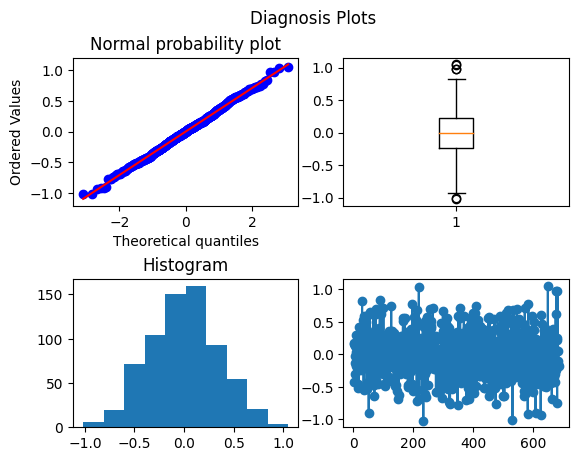

In [77]:
data_to_plot = residuals
fig, axs = plt.subplots(2, 2)
fig.suptitle('Diagnosis Plots')
stats.probplot(data_to_plot, dist="norm", plot=axs[0,0])
axs[0,0].set_title('Normal probability plot')
axs[0,1].boxplot(data_to_plot)
fig.subplots_adjust(hspace=0.5)
axs[1,0].hist(data_to_plot)
axs[1,0].set_title('Histogram')
axs[1,1].plot(np.arange(1, len(data_to_plot)+1), data_to_plot, 'o-')
plt.show()

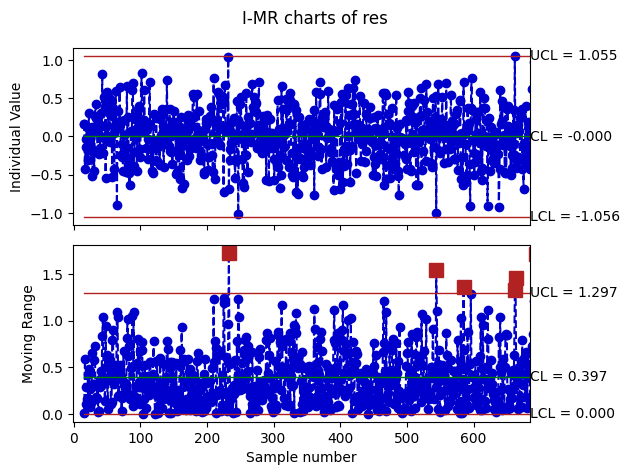

In [78]:
df_res = pd.DataFrame({'res': residuals})
df_res= qda.ControlCharts.IMR(df_res, 'res',K=3)

- **Results**

This approach demonstrated the greatest robustness across multiple layers. Even though raw temperature data exhibited strong non-normality, careful data cleaning, differencing, and Box-Cox transformation enabled successful ARIMA modeling. Residuals from both max and min temperature models passed independence and normality checks, allowing for I-MR chart application. The charts captured both track-level and cross-layer anomalies. Importantly, this method scaled effectively to the full dataset, handling thousands of tracks across multiple layers. Despite some initial trial and error with transformations, this approach emerged as a comprehensive, scalable solution for thermal monitoring. However, similar to the approach 7A, need for high-order differencing raises concerns about excessive information loss, which may undermine the reliability of the detected patterns. Although the model removed autocorrelation and noise, the extent of differencing limits confidence in the results. While the method offers scalability as a multi-layer spatial approach, its generalizability and effectiveness for cross-layer consistency checks require further validation. 

# Approach 8: Grouping by tracks within a layer

**Assumptions and preliminary data analysis**

This approach focuses on analyzing temperature behavior by grouping data by tracks within individual layers. It assumes that longer tracks provide more reliable temperature information and that track-level characteristics reflect localized thermal conditions. Mean temperature values were calculated per track and assessed for normality within each layer. Initial tests revealed that shorter tracks deviated significantly from normal distribution patterns, likely due to limited data points and increased edge effects. A filtering threshold was applied, retaining only the top 90% longest tracks per layer, which improved the residual distribution and stabilized variance across groups. These preprocessing steps ensured that the remaining data were suitable for time series modeling.

**Proposed methodology**

After filtering, ARIMA models were applied to the mean temperature values across tracks for each layer. An ARIMA(2,2,0) model was selected based on standard model selection criteria and diagnostic checks. Residuals from this model passed normality and independence tests, enabling their use in Shewhart I-MR control charts. These charts were then used to identify potential anomalies in track-wise temperature behavior within layers.

In [79]:
single_layer_tracks = full_frame[full_frame["layer_id"]==524] #change this to try for another track
single_layer.describe()

,t,x,y,z,layer_id,sensor0,sensor1,temp,track_id,track_orient,pos_rel,t_rel,t_binned
count,1.8108e+05,181080.0000,181080.0000,1.8108e+05,181080.0,181080.0000,181080.0000,181080.0000,181080.0000,181080.0,181080.0000,181080.0000,181080.0000
mean,1.2891e+08,32.1074,-60.6110,8.9600e+00,224.0,878.4397,898.4258,1563.4236,60.9613,271.0,6.0275,7505.6137,180.5000
std,5.9203e+05,3.4662,3.5003,2.2260e-11,0.0,20.6254,23.5441,12.1311,34.5445,0.0,3.5001,4358.2297,104.5009
min,1.2788e+08,26.0850,-66.9820,8.9600e+00,224.0,782.0000,786.0000,1498.4000,0.0000,271.0,0.0000,0.0000,0.0000
25%,1.2839e+08,29.1140,-63.6400,8.9600e+00,224.0,864.0000,883.0000,1555.5000,31.0000,271.0,2.9954,3730.0000,90.0000
50%,1.2891e+08,32.1055,-60.6090,8.9600e+00,224.0,877.0000,898.0000,1563.2000,61.0000,271.0,6.0041,7480.0000,180.5000
75%,1.2942e+08,35.1020,-57.5810,8.9600e+00,224.0,891.0000,914.0000,1571.1000,91.0000,271.0,9.0570,11280.0000,271.0000
max,1.2993e+08,38.1350,-54.4680,8.9600e+00,224.0,993.0000,1020.0000,1637.4000,121.0000,271.0,12.3491,15370.0000,361.0000


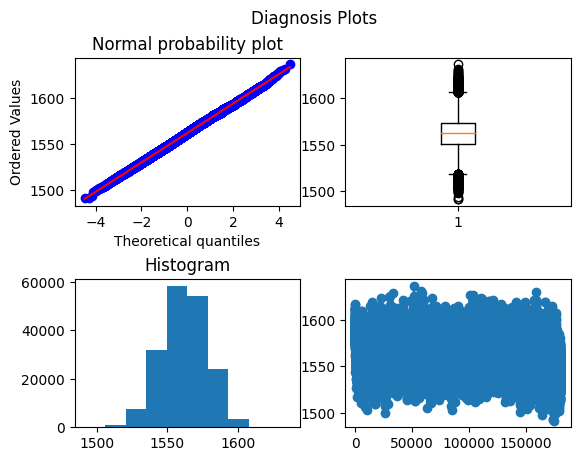

In [80]:
data_to_plot = single_layer_tracks['temp']
fig, axs = plt.subplots(2, 2)
fig.suptitle('Diagnosis Plots')
stats.probplot(data_to_plot, dist="norm", plot=axs[0,0])
axs[0,0].set_title('Normal probability plot')
axs[0,1].boxplot(data_to_plot)
fig.subplots_adjust(hspace=0.5)
axs[1,0].hist(data_to_plot)
axs[1,0].set_title('Histogram')
axs[1,1].plot(np.arange(1, len(data_to_plot)+1), data_to_plot, 'o-')
plt.show()

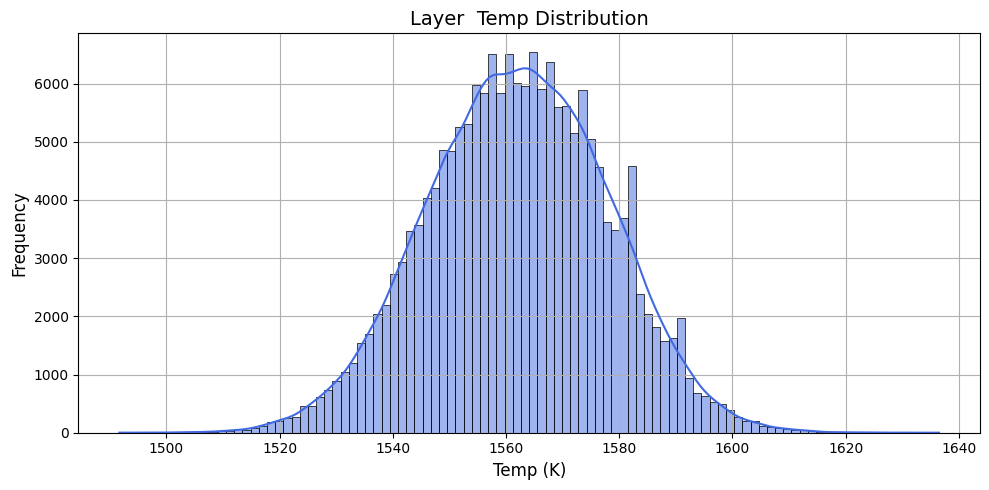

In [81]:
plt.figure(figsize=(10, 5))
sns.histplot(data_to_plot, bins=100, kde=True, color='royalblue')
plt.title("Layer  Temp Distribution", fontsize=14)
plt.xlabel("Temp (K)", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()

In [82]:
track_agg = single_layer_tracks.groupby('track_id')['temp'].agg([
    'mean', 'std', 'min', 'max', 'median', 'count']).reset_index()
track_agg.describe()

,track_id,mean,std,min,max,median,count
count,164.0000,164.0000,164.0000,164.0000,164.0000,164.0000,164.0000
mean,81.5000,1560.1973,12.7790,1521.1159,1605.1988,1559.5067,1100.1951
std,47.4868,11.3845,1.8121,12.6114,13.2603,11.8890,576.4247
min,0.0000,1536.2648,8.5990,1491.7000,1561.1000,1534.3000,23.0000
25%,40.7500,1552.1508,11.4680,1512.7500,1599.1750,1551.3250,597.2500
50%,81.5000,1559.9973,12.6084,1520.4500,1606.6000,1558.7250,1176.5000
75%,122.2500,1567.8191,13.6898,1529.4750,1613.3000,1568.0000,1749.2500
max,163.0000,1593.9345,18.6161,1568.7000,1636.5000,1593.0000,1750.0000


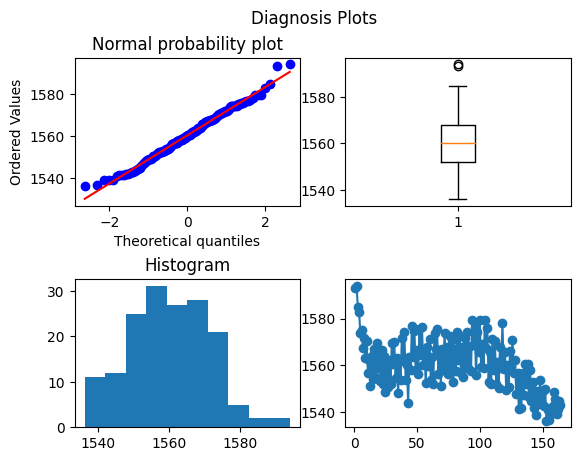

In [83]:
data_to_plot = track_agg["mean"]
fig, axs = plt.subplots(2, 2)
fig.suptitle('Diagnosis Plots')
stats.probplot(data_to_plot, dist="norm", plot=axs[0,0])
axs[0,0].set_title('Normal probability plot')
axs[0,1].boxplot(data_to_plot)
fig.subplots_adjust(hspace=0.5)
axs[1,0].hist(data_to_plot)
axs[1,0].set_title('Histogram')
axs[1,1].plot(np.arange(1, len(data_to_plot)+1), data_to_plot, 'o-')
plt.show()

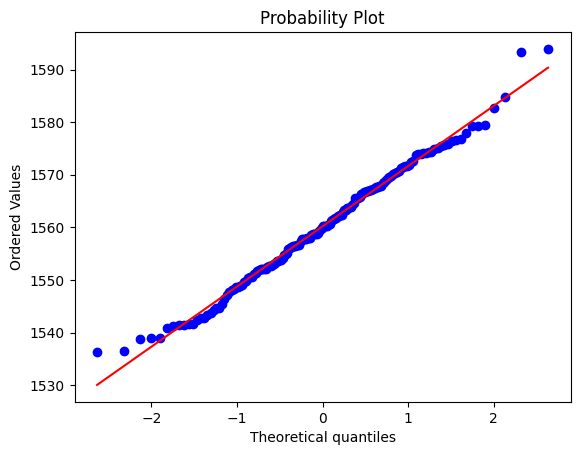

Shapiro-wilk test statistic = 0.990
Shapiro-wilk test p-value = 0.302
Runs test statistic = 2.976
Runs test p-value = 0.003



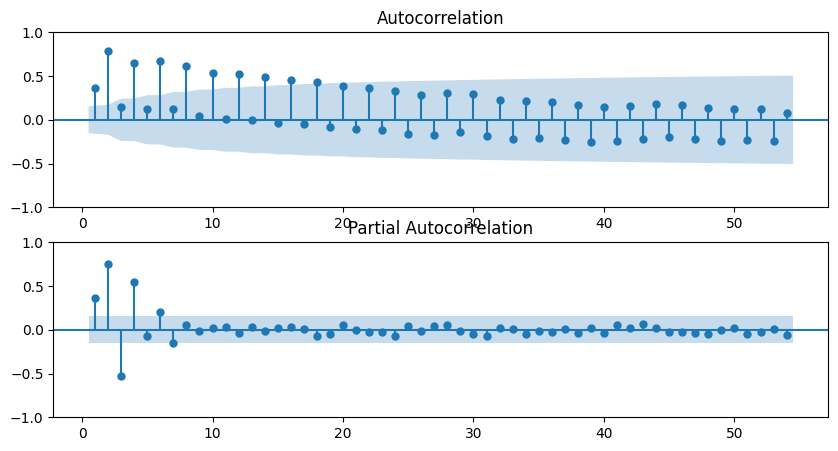

In [84]:
_ = qda.Assumptions(data_to_plot).normality()
_ = qda.Assumptions(data_to_plot).independence()

It's almost normally distributed, but there are strong outliers. Let's see which tracks stand as outliers.

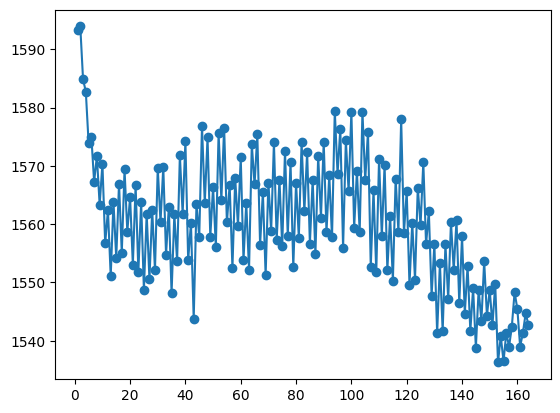

In [85]:
plt.plot(np.arange(1, len(data_to_plot)+1), data_to_plot, 'o-')
plt.show()

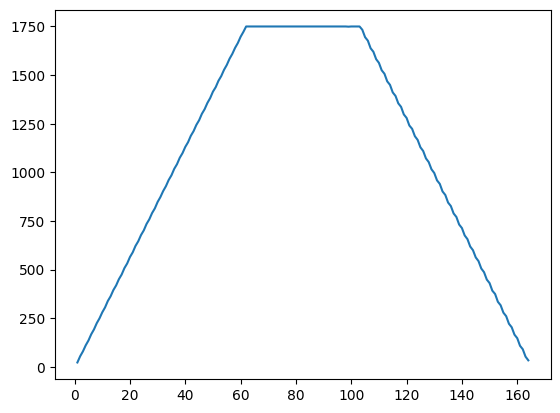

count     164.0000
mean     1100.1951
std       576.4247
min        23.0000
25%       597.2500
50%      1176.5000
75%      1749.2500
max      1750.0000
Name: count, dtype: float64

In [86]:
plt.plot(np.arange(1, len(data_to_plot)+1), track_agg["count"])
plt.show()
track_agg["count"].describe()

This trend stays similar for any layer, and creates a lot of problems. To solve that, we can get rid of the tracks with insufficient size:

In [87]:
lb = track_agg["count"].mean() * 0.1
track_agg_cleaned = track_agg[track_agg["count"] >= lb].reset_index()

print("The # of rows dropped =", track_agg["mean"].count()-track_agg_cleaned["mean"].count() )
track_agg_cleaned.describe()

The # of rows dropped = 7


,index,track_id,mean,std,min,max,median,count
count,157.0000,157.0000,157.0000,157.0000,157.0000,157.0000,157.0000,157.0000
mean,81.0000,81.0000,1560.0795,12.8761,1520.4439,1606.0032,1559.4096,1146.4140
std,45.4661,45.4661,10.4183,1.7736,11.6662,12.0112,11.0239,544.7651
min,3.0000,3.0000,1536.2648,8.7891,1491.7000,1567.2000,1534.3000,111.0000
25%,42.0000,42.0000,1552.6284,11.5017,1512.1000,1599.8000,1551.5000,676.0000
50%,81.0000,81.0000,1560.2025,12.6742,1520.1000,1606.8000,1558.8000,1224.0000
75%,120.0000,120.0000,1567.6318,13.7050,1529.1000,1613.3000,1567.9000,1750.0000
max,159.0000,159.0000,1582.7604,18.6161,1550.1000,1636.5000,1582.7000,1750.0000


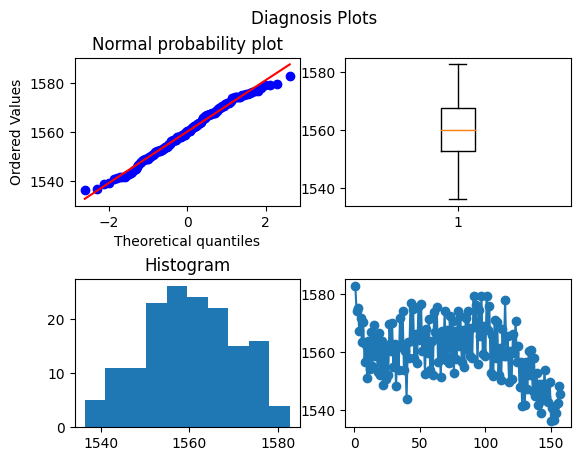

In [88]:
data_to_plot = track_agg_cleaned["mean"]
fig, axs = plt.subplots(2, 2)
fig.suptitle('Diagnosis Plots')
stats.probplot(data_to_plot, dist="norm", plot=axs[0,0])
axs[0,0].set_title('Normal probability plot')
axs[0,1].boxplot(data_to_plot)
fig.subplots_adjust(hspace=0.5)
axs[1,0].hist(data_to_plot)
axs[1,0].set_title('Histogram')
axs[1,1].plot(np.arange(1, len(data_to_plot)+1), data_to_plot, 'o-')
plt.show()

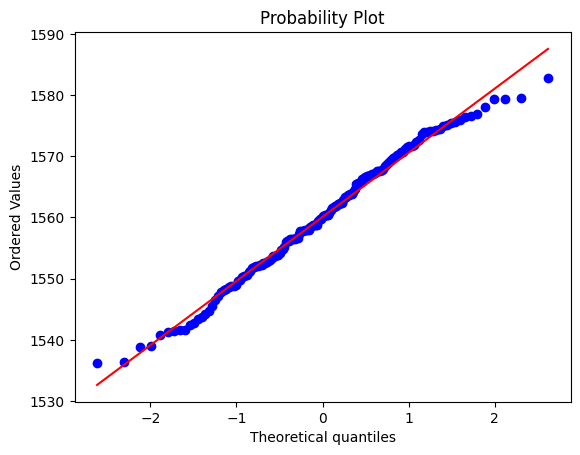

Shapiro-wilk test statistic = 0.987
Shapiro-wilk test p-value = 0.154
Runs test statistic = 3.604
Runs test p-value = 0.000



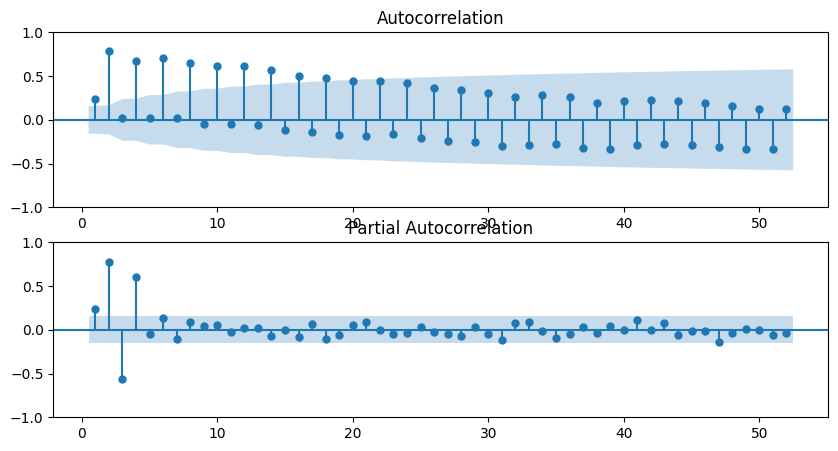

In [89]:
_ = qda.Assumptions(data_to_plot).normality()
_ = qda.Assumptions(data_to_plot).independence()

Let's decide on a diff value to use 

Runs test statistic = -5.546
Runs test p-value = 0.000



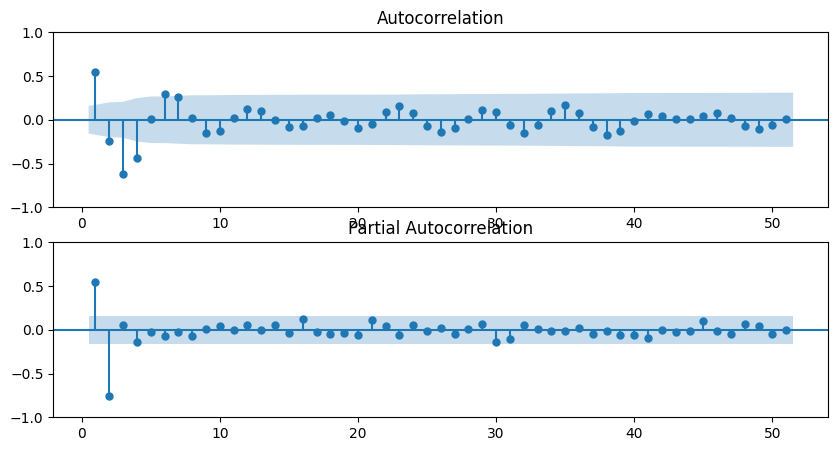

In [90]:
_ = qda.Assumptions(data_to_plot.diff(2)).independence()

A diff of 2 allows series to be stationary. Let's fit an ARIMA model with this diff.

---------------------
ARIMA MODEL RESULTS
---------------------
ARIMA model order: p=2, d=2, q=0

FINAL ESTIMATES OF PARAMETERS
-------------------------------
 Term    Coef  SE Coef  T-Value    P-Value
ar.L1  0.9634   0.0545  17.6715 6.9501e-70
ar.L2 -0.7644   0.0566 -13.5033 1.4951e-41

RESIDUAL SUM OF SQUARES
-------------------------
   DF        SS      MS
153.0 1790.6869 11.7038

Ljung-Box Chi-Square Statistics
----------------------------------
 Lag  Chi-Square  P-Value
  12      7.2049   0.8438
  24     14.5641   0.9329
  36     25.9258   0.8925
  48     36.1628   0.8953
Runs test statistic = 0.106
Runs test p-value = 0.915



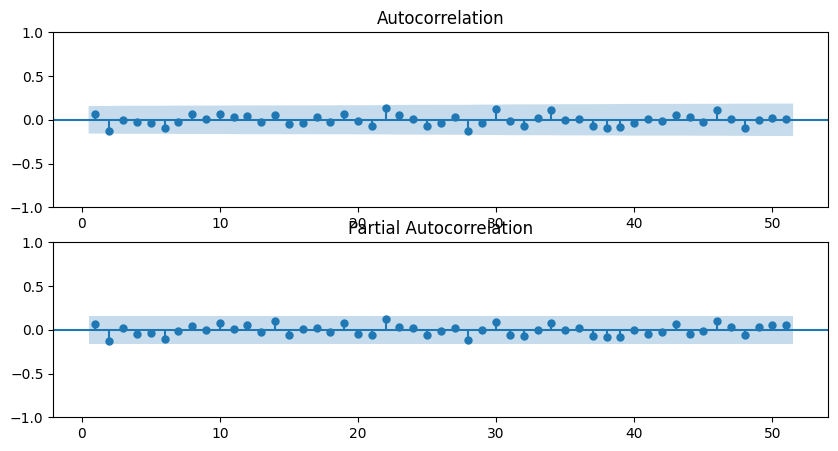

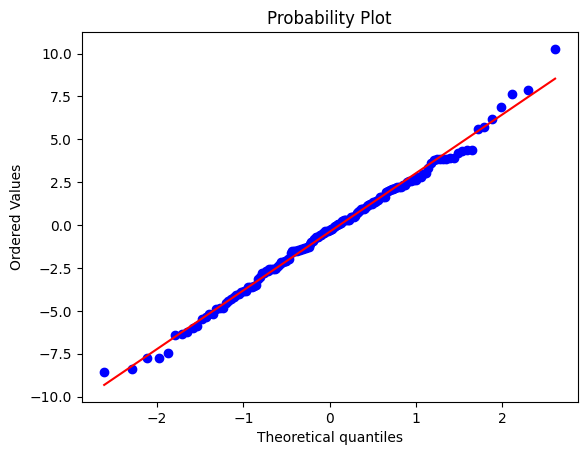

Shapiro-wilk test statistic = 0.994
Shapiro-wilk test p-value = 0.808


In [91]:
d = 2
model = qda.ARIMA(track_agg_cleaned["mean"], order=(2,d,0), add_constant=False)
qda.ARIMAsummary(model)
residuals = model.resid[d:]
_ = qda.Assumptions(residuals).independence()
_ = qda.Assumptions(residuals).normality()

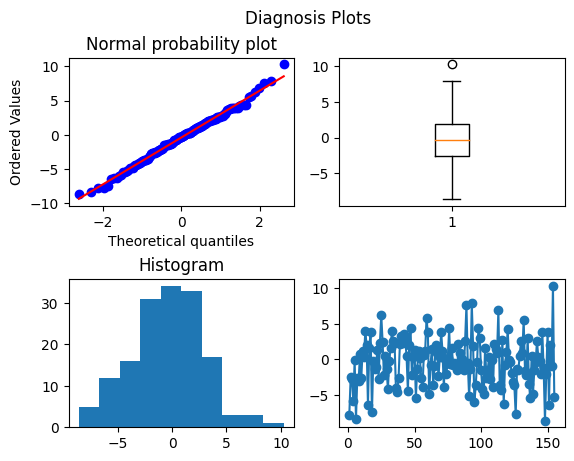

In [92]:
data_to_plot = residuals
fig, axs = plt.subplots(2, 2)
fig.suptitle('Diagnosis Plots')
stats.probplot(data_to_plot, dist="norm", plot=axs[0,0])
axs[0,0].set_title('Normal probability plot')
axs[0,1].boxplot(data_to_plot)
fig.subplots_adjust(hspace=0.5)
axs[1,0].hist(data_to_plot)
axs[1,0].set_title('Histogram')
axs[1,1].plot(np.arange(1, len(data_to_plot)+1), data_to_plot, 'o-')
plt.show()

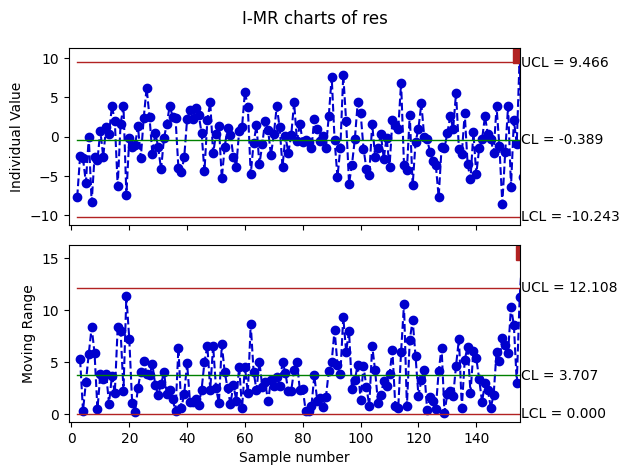

In [93]:
df_res = pd.DataFrame({'res': residuals})
df_res= qda.ControlCharts.IMR(df_res, 'res',K=3)

**Results**
Tested across multiple layers, this approach consistently produced reliable outputs, confirming its suitability for within-layer thermal monitoring. The filtering strategy effectively addressed non-normality issues, allowing control charts to be applied without further adjustments. Its layer-independent performance suggests potential for integration into broader process control frameworks.

# Approach 9: Grouping by track across multiple layers

**Assumptions and preliminary data analysis**

This approach analyzes temperature behavior by grouping data according to track index across multiple layers, based on the assumption that tracks at the same relative position exhibit consistent thermal patterns. Mean temperature values were computed for each recurring track index and evaluated for distributional properties. Normality tests revealed significant deviations, and a Box-Cox transformation yielded an estimated λ ≈ 30, indicating extreme skewness that could not be corrected through transformation. These issues were traced to inconsistencies in how tracks behave across layers, including variation in geometry and thermal dynamics that violate the assumption of cross-layer uniformity.

**Proposed methodology**

ARIMA modeling was applied to the mean values per track index but did not produce valid residuals, failing to meet normality and independence assumptions required for control charting. The combination of unstable statistical properties and inconsistent behavior across layers prevented this method from supporting reliable SPC analysis. Despite its initial conceptual appeal, grouping by track index across multiple layers did not result in a workable modeling or monitoring strategy under the tested conditions.

In [94]:
multi_layer_tracks = full_frame[full_frame["layer_id"]<=228] #change this to try for another track
multi_layer_tracks.describe()

,t,x,y,z,layer_id,sensor0,sensor1,temp,track_id,track_orient,pos_rel,t_rel,x_binned,y_binned
count,9.0560e+05,905602.0000,905602.0000,905602.0000,905602.0000,905602.0000,905602.0000,905602.0000,905602.0000,905602.0000,905602.0000,905602.0000,905602.0000,905602.0000
mean,1.2551e+08,32.1072,-60.6091,9.0400,225.9994,899.7357,927.5402,1555.5221,73.7000,189.0489,5.7876,7208.4216,450.3456,448.4908
std,2.7298e+07,3.4686,3.4992,0.0566,1.4139,30.8287,42.8479,18.9915,36.1628,105.5574,3.6727,4574.0790,259.6919,261.4417
min,9.0548e+07,25.9990,-66.9820,8.9600,224.0000,774.0000,776.0000,1444.2000,0.0000,45.0000,0.0000,0.0000,0.0000,0.0000
25%,9.6544e+07,29.1130,-63.6370,9.0000,225.0000,879.0000,899.0000,1544.5000,45.0000,112.0000,2.6008,3240.0000,226.0000,222.0000
50%,1.2891e+08,32.1050,-60.6090,9.0400,226.0000,896.0000,921.0000,1556.9000,74.0000,179.0000,5.4923,6840.0000,450.0000,448.0000
75%,1.5262e+08,35.1040,-57.5790,9.0800,227.0000,916.0000,948.0000,1568.2000,102.0000,271.0000,8.7738,10930.0000,675.0000,675.0000
max,1.5892e+08,38.2150,-54.4680,9.1200,228.0000,1108.0000,1235.0000,1639.1000,172.0000,338.0000,17.0354,21210.0000,901.0000,901.0000


In [95]:
multi_layer_tracks["layer_track"]  = multi_layer_tracks["layer_id"]*10000 + multi_layer_tracks["track_id"]
multi_layer_tracks_agg = multi_layer_tracks.groupby('layer_track')['temp'].agg([
    'mean', 'std', 'min', 'max', 'median', 'count']).reset_index()
multi_layer_tracks_agg.describe()

,layer_track,mean,std,min,max,median,count
count,7.4300e+02,743.0000,743.0000,743.0000,743.0000,743.0000,743.0000
mean,2.2602e+06,1555.1023,12.7250,1516.8888,1601.0727,1554.3964,1218.8452
std,1.3338e+04,14.1778,3.6213,17.4635,14.9817,14.8030,522.6786
min,2.2400e+06,1504.6334,6.0492,1444.2000,1548.2000,1494.3000,8.0000
25%,2.2501e+06,1546.3816,10.9188,1508.3500,1593.6500,1545.6750,875.5000
50%,2.2601e+06,1556.3601,11.9021,1517.5000,1602.9000,1555.6500,1500.0000
75%,2.2701e+06,1564.7240,13.2051,1527.4000,1610.7500,1564.3250,1556.5000
max,2.2801e+06,1595.6682,34.8920,1580.8000,1639.1000,1595.5500,2122.0000


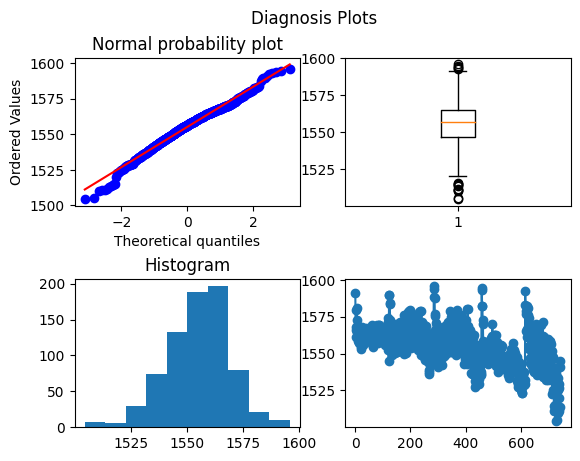

In [96]:
data_to_plot = multi_layer_tracks_agg['mean']
fig, axs = plt.subplots(2, 2)
fig.suptitle('Diagnosis Plots')
stats.probplot(data_to_plot, dist="norm", plot=axs[0,0])
axs[0,0].set_title('Normal probability plot')
axs[0,1].boxplot(data_to_plot)
fig.subplots_adjust(hspace=0.5)
axs[1,0].hist(data_to_plot)
axs[1,0].set_title('Histogram')
axs[1,1].plot(np.arange(1, len(data_to_plot)+1), data_to_plot, 'o-')
plt.show()

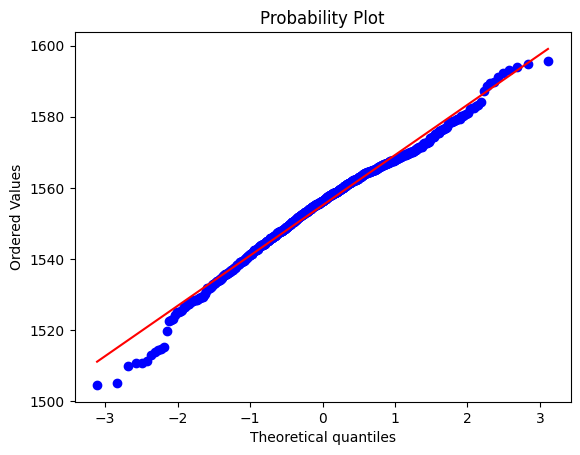

Shapiro-wilk test statistic = 0.987
Shapiro-wilk test p-value = 0.000
Runs test statistic = -6.948
Runs test p-value = 0.000



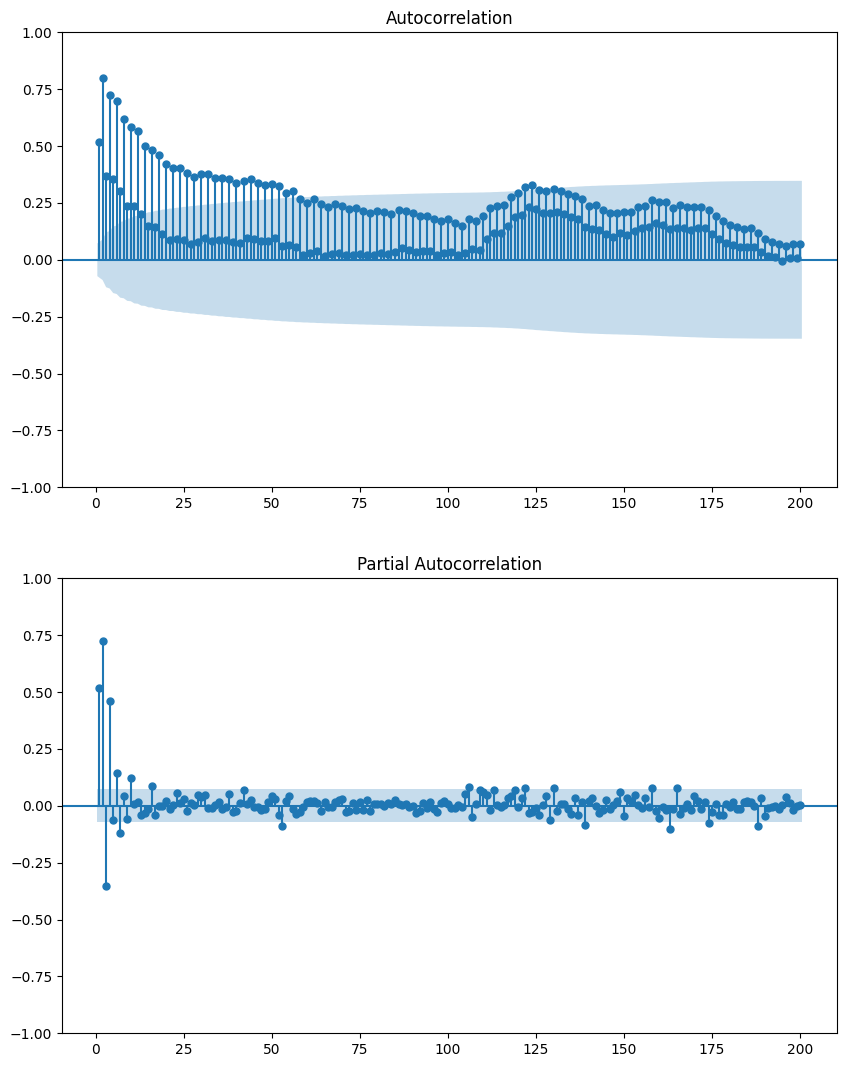

In [97]:
_ = qda.Assumptions(data_to_plot).normality()
_ = qda.Assumptions(data_to_plot).independence()

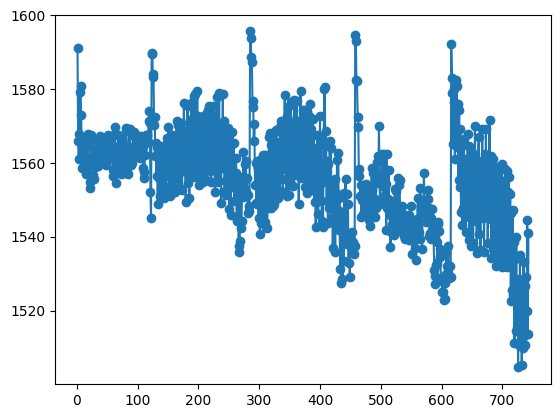

In [98]:
plt.plot(np.arange(1, len(data_to_plot)+1), data_to_plot, 'o-')
plt.show()

There are sudden jumps when switching layers. Let's see if removing the small sized samples will help again

In [99]:
lb = multi_layer_tracks_agg["count"].mean() * 0.2
track_agg_ml_clean = multi_layer_tracks_agg[multi_layer_tracks_agg["count"] >= lb].reset_index()

print("The # of rows dropped =", multi_layer_tracks_agg["mean"].count()-track_agg_ml_clean["mean"].count() )
track_agg_ml_clean.describe()

The # of rows dropped = 64


,index,layer_track,mean,std,min,max,median,count
count,679.0000,6.7900e+02,679.0000,679.0000,679.0000,679.0000,679.0000,679.0000
mean,369.2283,2.2601e+06,1554.5365,12.9360,1515.2809,1602.2968,1553.7702,1323.6200
std,218.5488,1.3601e+04,13.1829,3.6822,15.8824,13.3926,13.8800,413.4567
min,1.0000,2.2400e+06,1504.6334,8.3939,1444.2000,1548.2000,1494.3000,246.0000
25%,177.5000,2.2501e+06,1546.6127,11.0918,1507.8000,1595.0000,1545.8500,1122.5000
50%,368.0000,2.2601e+06,1556.2625,12.0670,1517.0000,1603.4000,1555.5000,1500.0000
75%,558.5000,2.2701e+06,1564.3175,13.3956,1526.2000,1610.8500,1563.9500,1617.0000
max,741.0000,2.2801e+06,1582.4782,34.8920,1547.3000,1639.1000,1581.7000,2122.0000


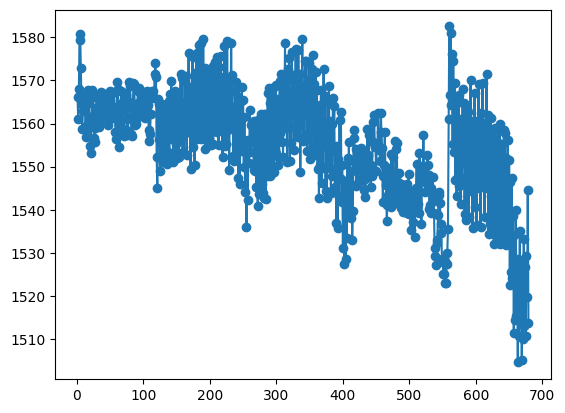

In [100]:
data_to_plot = track_agg_ml_clean["mean"]
plt.plot(np.arange(1, len(data_to_plot)+1), data_to_plot, 'o-')
plt.show()

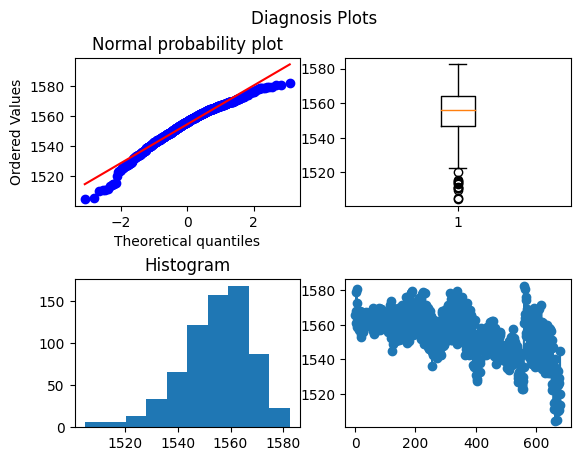

In [101]:
fig, axs = plt.subplots(2, 2)
fig.suptitle('Diagnosis Plots')
stats.probplot(data_to_plot, dist="norm", plot=axs[0,0])
axs[0,0].set_title('Normal probability plot')
axs[0,1].boxplot(data_to_plot)
fig.subplots_adjust(hspace=0.5)
axs[1,0].hist(data_to_plot)
axs[1,0].set_title('Histogram')
axs[1,1].plot(np.arange(1, len(data_to_plot)+1), data_to_plot, 'o-')
plt.show()

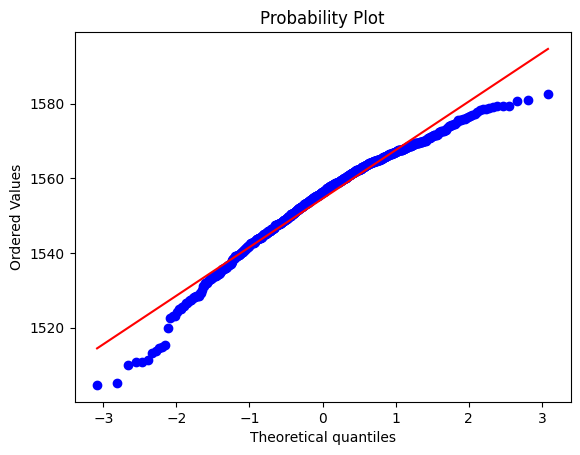

Shapiro-wilk test statistic = 0.967
Shapiro-wilk test p-value = 0.000
Runs test statistic = -6.404
Runs test p-value = 0.000



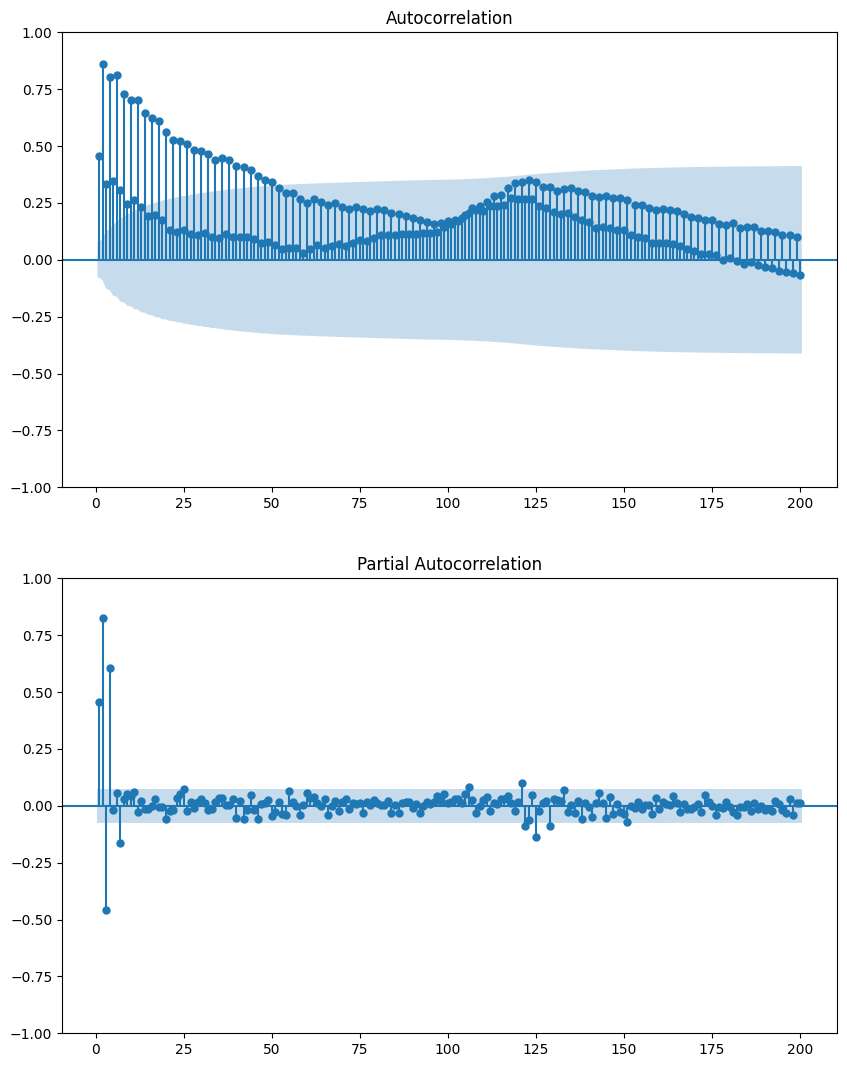

In [102]:
_ = qda.Assumptions(data_to_plot).normality()
_ = qda.Assumptions(data_to_plot).independence()

It seems it was not enough. Let's try box cox transformation to reach normality

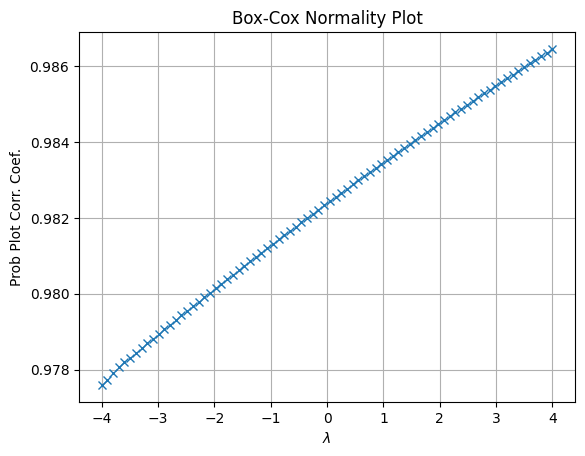

In [103]:
fig = plt.figure()
ax = fig.add_subplot(111)
stats.boxcox_normplot(track_agg_ml_clean["mean"]+50, -4, 4, plot=ax)
# add grid
ax.grid(True)

In [104]:
[data_BC, lmbda] = stats.boxcox(track_agg_ml_clean["mean"])
print("Lambda =",lmbda)
track_agg_ml_clean["mean_BC"] = data_BC

Lambda = 30.84995681009197


c:\Users\atari\anaconda3\envs\QDA_environment_WIN\lib\site-packages\numpy\core\_methods.py:233: RuntimeWarning: overflow encountered in multiply
  x = um.multiply(x, x, out=x)


Lambda of 30 is clearly too high. Let's try an alternative approach

c:\Users\atari\anaconda3\envs\QDA_environment_WIN\lib\site-packages\numpy\core\_methods.py:233: RuntimeWarning: overflow encountered in multiply
  x = um.multiply(x, x, out=x)


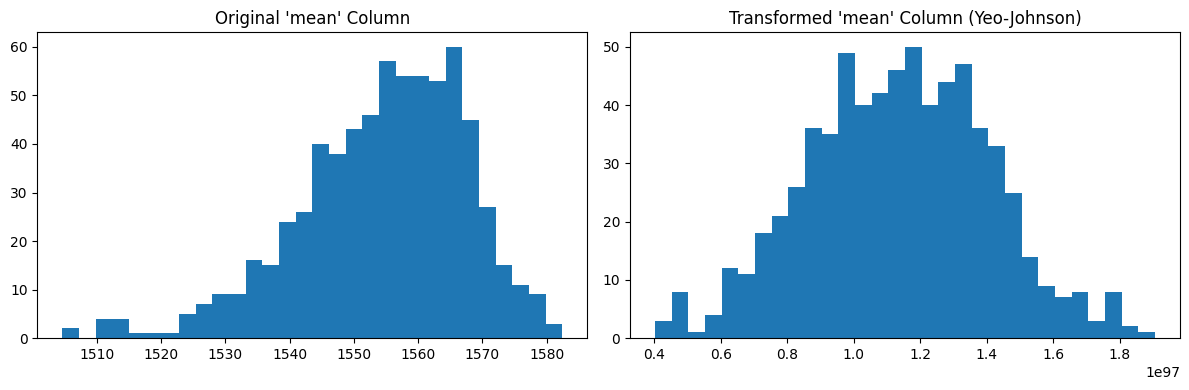

Yeo-Johnson λ: 30.86923966319081


In [105]:
from sklearn.preprocessing import PowerTransformer
import matplotlib.pyplot as plt

# Extract the column as a NumPy array and reshape
data = track_agg_ml_clean["mean"].values.reshape(-1, 1)

# Initialize transformer
pt = PowerTransformer(method='yeo-johnson', standardize=False)

# Fit and transform
transformed = pt.fit_transform(data)

# Get lambda
lambda_val = pt.lambdas_[0]

# Add the transformed column back to the DataFrame
track_agg_ml_clean["mean_yeojohnson"] = transformed

# Plot original and transformed
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(track_agg_ml_clean["mean"], bins=30)
plt.title("Original 'mean' Column")

plt.subplot(1, 2, 2)
plt.hist(track_agg_ml_clean["mean_yeojohnson"], bins=30)
plt.title("Transformed 'mean' Column (Yeo-Johnson)")

plt.tight_layout()
plt.show()

# Print the lambda
print(f"Yeo-Johnson λ: {lambda_val}")

Again, the lambda is too high. Only option left is to try removing the outliers

In [106]:
Q1 = track_agg_ml_clean["mean"].quantile(0.25)
Q3 = track_agg_ml_clean["mean"].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
track_agg_ml_cleaner = track_agg_ml_clean[(track_agg_ml_clean["mean"] > lower_bound) & 
                     (track_agg_ml_clean["mean"] < upper_bound)].reset_index(drop=True)
print("The # of rows dropped =", track_agg_ml_clean["mean"].count()-track_agg_ml_cleaner["mean"].count() )

The # of rows dropped = 12


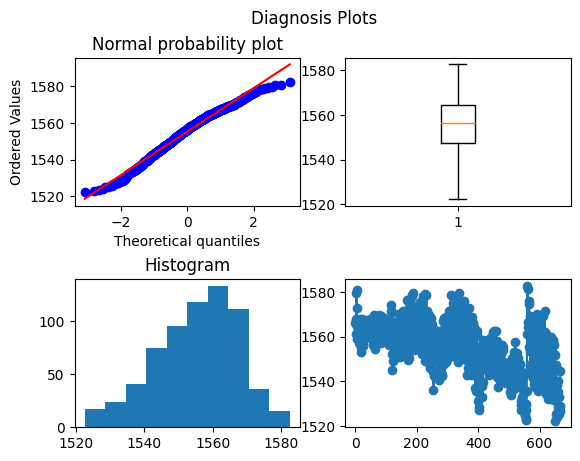

In [107]:
data_to_plot = track_agg_ml_cleaner["mean"]
fig, axs = plt.subplots(2, 2)
fig.suptitle('Diagnosis Plots')
stats.probplot(data_to_plot, dist="norm", plot=axs[0,0])
axs[0,0].set_title('Normal probability plot')
axs[0,1].boxplot(data_to_plot)
fig.subplots_adjust(hspace=0.5)
axs[1,0].hist(data_to_plot)
axs[1,0].set_title('Histogram')
axs[1,1].plot(np.arange(1, len(data_to_plot)+1), data_to_plot, 'o-')
plt.show()

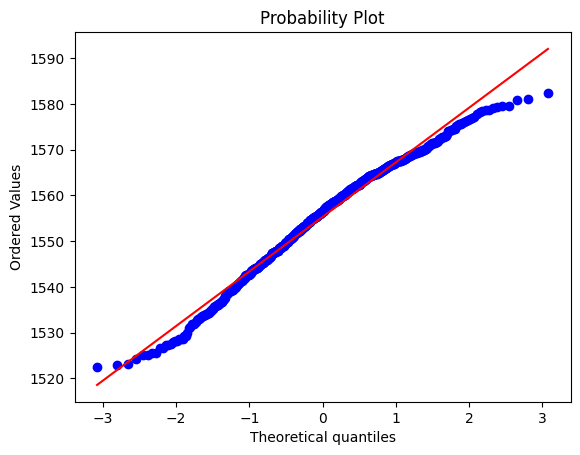

Shapiro-wilk test statistic = 0.984
Shapiro-wilk test p-value = 0.000
Runs test statistic = -5.324
Runs test p-value = 0.000



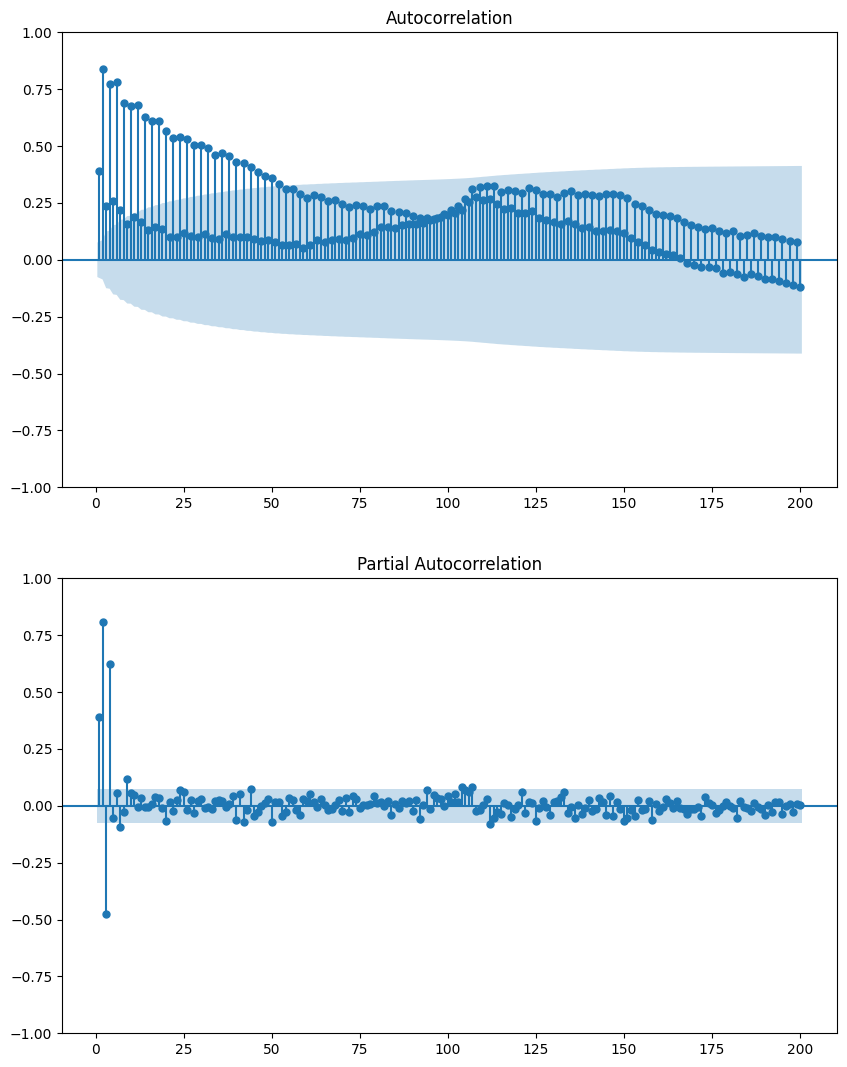

In [108]:
_ = qda.Assumptions(data_to_plot).normality()
_ = qda.Assumptions(data_to_plot).independence()

No solution found that can make the data normally distributed, but maybe ARIMA will help. Let's keep "outliers" as well, use the first cleaned data

Runs test statistic = -11.014
Runs test p-value = 0.000



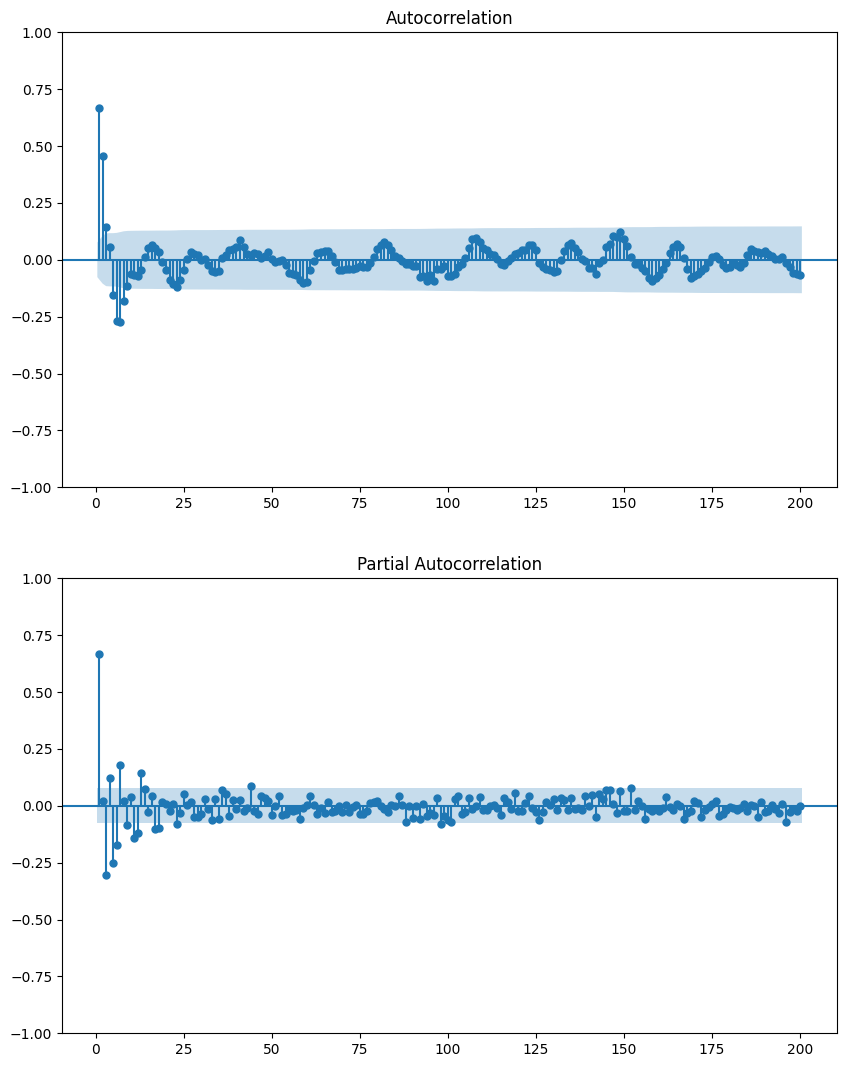

In [109]:
_ = qda.Assumptions(track_agg_ml_cleaner["mean"].diff(6)).independence() 

---------------------
ARIMA MODEL RESULTS
---------------------
ARIMA model order: p=2, d=3, q=2

FINAL ESTIMATES OF PARAMETERS
-------------------------------
 Term    Coef  SE Coef  T-Value    P-Value
const -0.1701   0.6286  -0.2706 7.8669e-01
ar.L1 -0.5281   0.0250 -21.0944 8.9558e-99
ar.L2  0.4241   0.0252  16.8331 1.3948e-63
ma.L1  1.0971   0.0135  81.2942 0.0000e+00
ma.L2  0.9523   0.0135  70.5040 0.0000e+00

RESIDUAL SUM OF SQUARES
-------------------------
   DF         SS      MS
671.0 23900.7269 35.6196

Ljung-Box Chi-Square Statistics
----------------------------------
 Lag  Chi-Square     P-Value
  12    632.8772 1.0037e-127
  24    705.5124 1.7168e-133
  36    758.7436 3.5794e-136
  48    787.6523 1.8580e-134
Runs test statistic = -5.440
Runs test p-value = 0.000



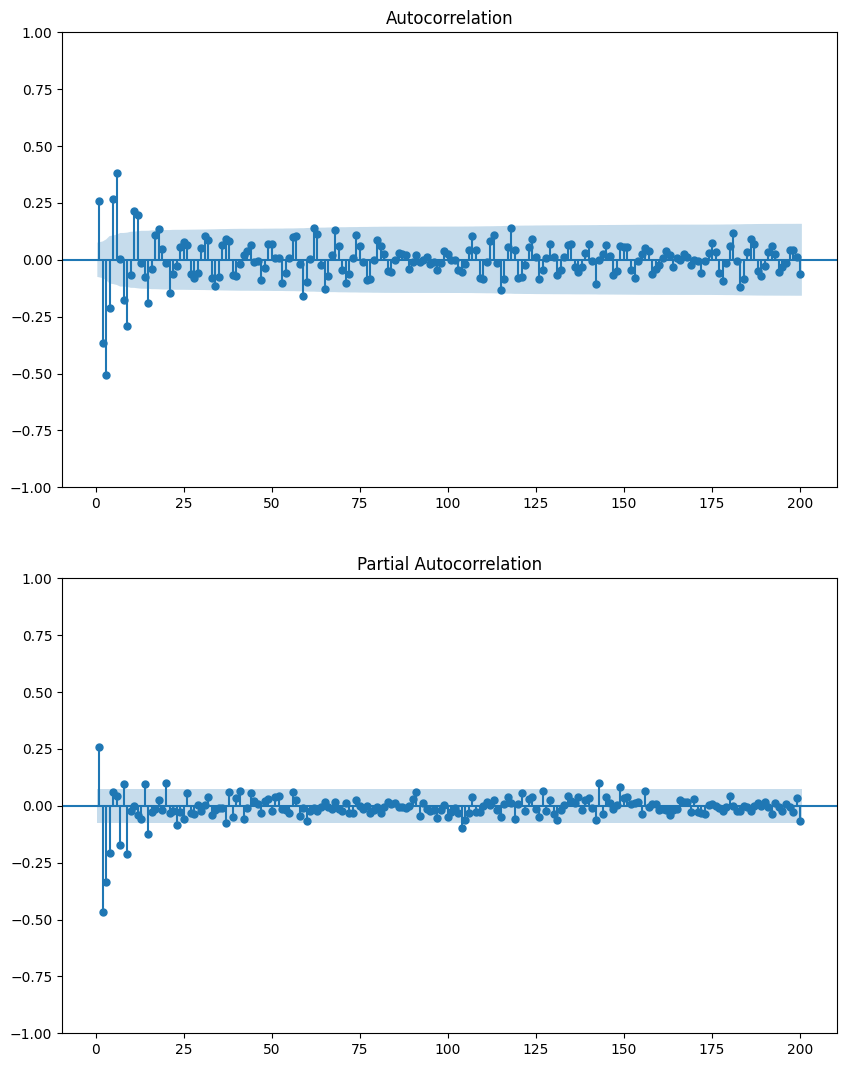

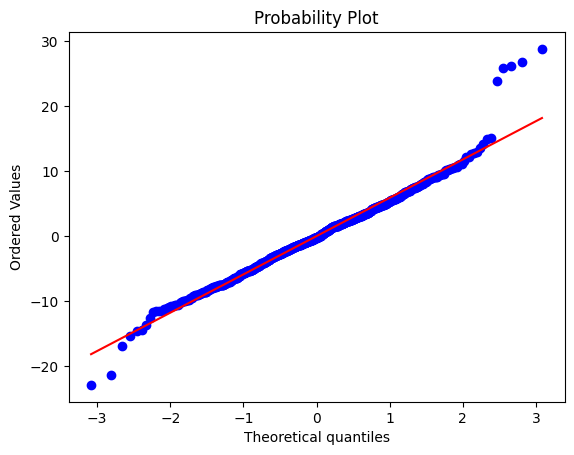

Shapiro-wilk test statistic = 0.974
Shapiro-wilk test p-value = 0.000


In [110]:
d = 3
model = qda.ARIMA(track_agg_ml_clean["mean"], order=(2,d,2), add_constant=True)
qda.ARIMAsummary(model)
residuals = model.resid[d:]
_ = qda.Assumptions(residuals).independence()
_ = qda.Assumptions(residuals).normality()

**Results**

This approach did not yield usable results, as neither transformation nor ARIMA modeling could address the lack of normality and consistency in the data. The resulting plot clearly showed distinct differences between layers, highlighting the variability in track behavior across the build. These findings confirm that grouping by track index across layers is not suitable for thermal monitoring in its current form.

# Approach 10: Grouping by tracks within a layer and controlling max and min values, instead of means

**Assumptions and preliminary data analysis**

This approach groups temperature data by tracks within each layer, focusing on the maximum and minimum temperature values per track instead of the mean. It assumes that a small number of outliers in the max values are due to assignable causes. After removing these outliers, the remaining max temperature values were found to be independent and identically distributed (iid), meeting the assumptions needed for control charting. In contrast, the min values did not achieve iid behavior even after outlier removal, showing persistent dependence and non-normality.

**Proposed methodology**

Control charts were constructed using the cleaned max temperature values per track within each layer. The removal of outliers enabled the application of Shewhart charts by ensuring the residuals met the required statistical assumptions. Due to the inability to normalize or stabilize the min values, no control charts were produced for them.

In [111]:
single_layer_track2 = full_frame[full_frame["layer_id"]==228] #change this to try for another track
single_layer_track2.describe()

,t,x,y,z,layer_id,sensor0,sensor1,temp,track_id,track_orient,pos_rel,t_rel,x_binned,y_binned
count,1.8088e+05,180881.0000,180881.0000,1.8088e+05,180881.0,180881.0000,180881.0000,180881.0000,180881.0000,180881.0,180881.0000,180881.0000,180881.0000,180881.0000
mean,9.7057e+07,32.1059,-60.6026,9.1200e+00,228.0,924.6540,962.7550,1545.6941,65.7536,179.0,5.9665,7433.2135,450.2519,448.9610
std,5.9299e+05,3.4687,3.4950,3.7991e-11,0.0,36.4114,56.0266,25.5214,34.8281,0.0,3.4844,4340.6002,259.6836,261.1623
min,9.6022e+07,25.9990,-66.8940,9.1200e+00,228.0,783.0000,776.0000,1444.2000,0.0000,179.0,0.0000,0.0000,0.0000,0.0000
25%,9.6545e+07,29.1120,-63.6270,9.1200e+00,228.0,901.0000,927.0000,1530.5000,36.0000,179.0,2.9455,3670.0000,226.0000,223.0000
50%,9.7058e+07,32.1040,-60.6000,9.1200e+00,228.0,920.0000,953.0000,1547.9000,66.0000,179.0,5.9448,7410.0000,450.0000,449.0000
75%,9.7571e+07,35.1030,-57.5750,9.1200e+00,228.0,943.0000,988.0000,1563.7000,96.0000,179.0,8.9826,11190.0000,675.0000,675.0000
max,9.8087e+07,38.2150,-54.5480,9.1200e+00,228.0,1108.0000,1235.0000,1635.2000,127.0000,179.0,12.0519,15000.0000,901.0000,900.0000


In [112]:
single_track2_agg = single_layer_track2.groupby('track_id')['temp'].agg([
    'mean', 'std', 'min', 'max', 'median', 'count']).reset_index()
single_track2_agg["range"] = single_track2_agg["max"] - single_track2_agg["min"]
single_track2_agg.describe()

,track_id,mean,std,min,max,median,count,range
count,128.0000,128.0000,128.0000,128.0000,128.0000,128.0000,128.0000,128.0000
mean,63.5000,1547.0645,17.3059,1502.8977,1605.8852,1545.1637,1413.1328,102.9875
std,37.0945,18.4596,6.3045,25.6839,10.8708,19.9934,325.7629,24.6046
min,0.0000,1504.6334,8.9406,1444.2000,1548.2000,1494.3000,26.0000,39.8000
25%,31.7500,1534.3386,13.1769,1490.2750,1600.2500,1531.6875,1500.0000,87.2500
50%,63.5000,1547.1201,15.2087,1506.9000,1606.4500,1546.0500,1500.0000,100.7000
75%,95.2500,1560.3007,18.1420,1518.2000,1611.7500,1560.0875,1500.0000,112.3000
max,127.0000,1592.3692,34.8920,1580.8000,1635.2000,1590.4000,1501.0000,175.2000


In [113]:
lb = single_track2_agg["count"].mean() * 0.1
track_2_agg_clean = single_track2_agg[single_track2_agg["count"] >= lb].reset_index()

print("The # of rows dropped =", single_track2_agg["mean"].count()-track_2_agg_clean["mean"].count() )
track_2_agg_clean.describe()

The # of rows dropped = 5


,index,track_id,mean,std,min,max,median,count,range
count,123.0000,123.0000,123.0000,123.0000,123.0000,123.0000,123.0000,123.0000,123.0000
mean,64.9837,64.9837,1545.9258,17.5796,1500.9577,1606.0041,1543.9679,1467.2033,105.0463
std,35.6791,35.6791,17.5629,6.2755,23.9457,10.2871,19.1599,186.9746,22.7540
min,3.0000,3.0000,1504.6334,10.2920,1444.2000,1548.2000,1494.3000,176.0000,55.5000
25%,34.5000,34.5000,1534.1965,13.5727,1489.9000,1600.2000,1530.9500,1500.0000,88.2000
50%,65.0000,65.0000,1546.7497,15.2983,1504.7000,1606.4000,1545.0000,1500.0000,101.4000
75%,95.5000,95.5000,1559.4020,18.3650,1517.6000,1611.6000,1559.2000,1500.0000,113.0500
max,126.0000,126.0000,1582.4782,34.8920,1549.9000,1635.2000,1581.7000,1501.0000,175.2000


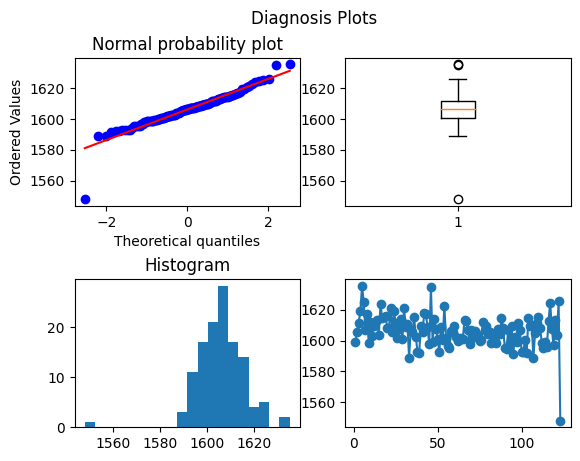

In [114]:
data_to_plot = track_2_agg_clean["max"]
fig, axs = plt.subplots(2, 2)
fig.suptitle('Diagnosis Plots')
stats.probplot(data_to_plot, dist="norm", plot=axs[0,0])
axs[0,0].set_title('Normal probability plot')
axs[0,1].boxplot(data_to_plot)
fig.subplots_adjust(hspace=0.5)
axs[1,0].hist(data_to_plot, bins = 20)
axs[1,0].set_title('Histogram')
axs[1,1].plot(np.arange(1, len(data_to_plot)+1), data_to_plot, 'o-')
plt.show()

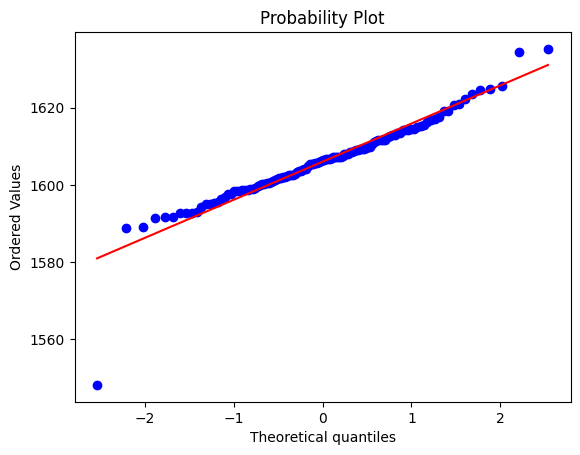

Shapiro-wilk test statistic = 0.911
Shapiro-wilk test p-value = 0.000
Runs test statistic = 0.097
Runs test p-value = 0.923



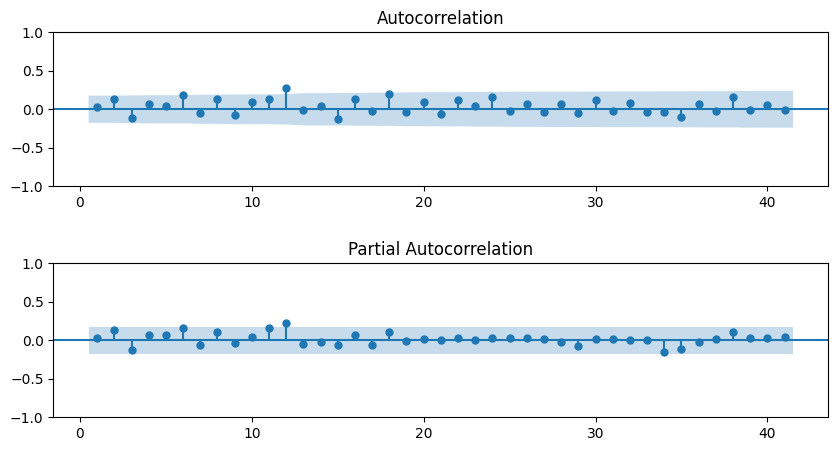

In [115]:
_ = qda.Assumptions(data_to_plot).normality()
_ = qda.Assumptions(data_to_plot).independence()

Few outlier values seem to distort normality. Let's assume assignable cause and remove them.

In [116]:
Q1 = track_2_agg_clean['max'].quantile(0.25)
Q3 = track_2_agg_clean['max'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

track_2_agg_clean2 = track_2_agg_clean[(track_2_agg_clean['max'] > lower_bound) & 
                     (track_2_agg_clean['max'] < upper_bound)].reset_index(drop=True)

print("The # of rows dropped =", track_2_agg_clean["mean"].count()-track_2_agg_clean2["mean"].count() )

The # of rows dropped = 3


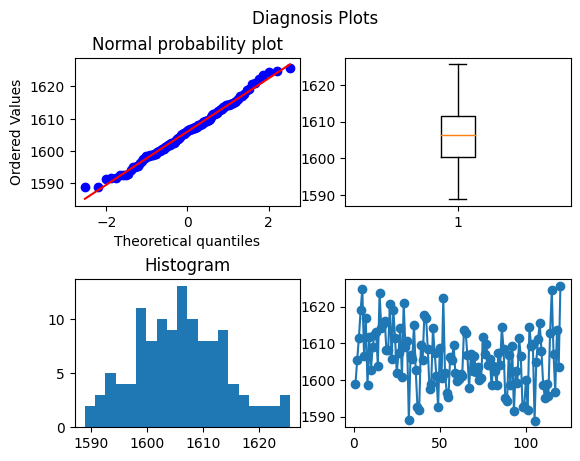

In [117]:
data_to_plot = track_2_agg_clean2["max"]
fig, axs = plt.subplots(2, 2)
fig.suptitle('Diagnosis Plots')
stats.probplot(data_to_plot, dist="norm", plot=axs[0,0])
axs[0,0].set_title('Normal probability plot')
axs[0,1].boxplot(data_to_plot)
fig.subplots_adjust(hspace=0.5)
axs[1,0].hist(data_to_plot, bins = 20)
axs[1,0].set_title('Histogram')
axs[1,1].plot(np.arange(1, len(data_to_plot)+1), data_to_plot, 'o-')
plt.show()

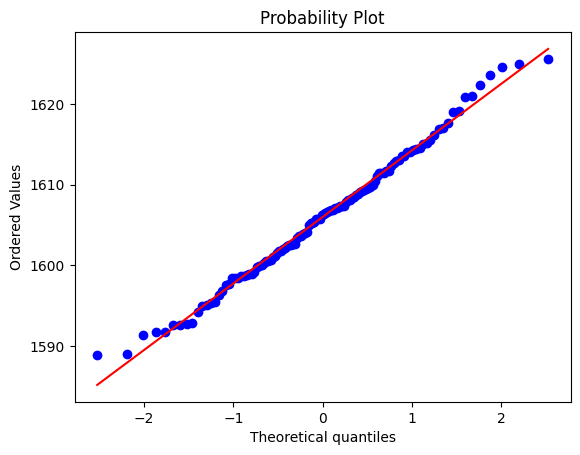

Shapiro-wilk test statistic = 0.990
Shapiro-wilk test p-value = 0.505
Runs test statistic = -0.180
Runs test p-value = 0.857



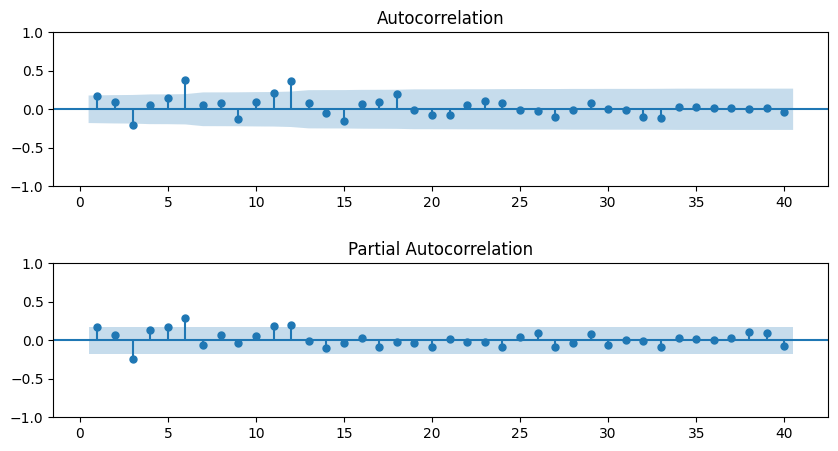

In [118]:
_ = qda.Assumptions(data_to_plot).normality()
_ = qda.Assumptions(data_to_plot).independence()

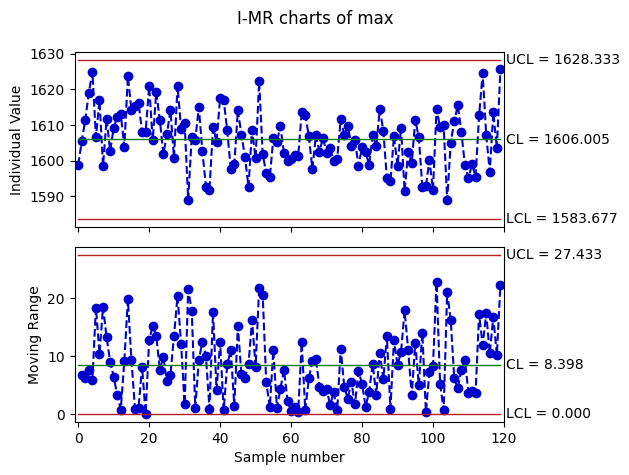

In [119]:
_ = qda.ControlCharts.IMR(track_2_agg_clean2,"max",K=3)

Let's try the same thing with Mins:

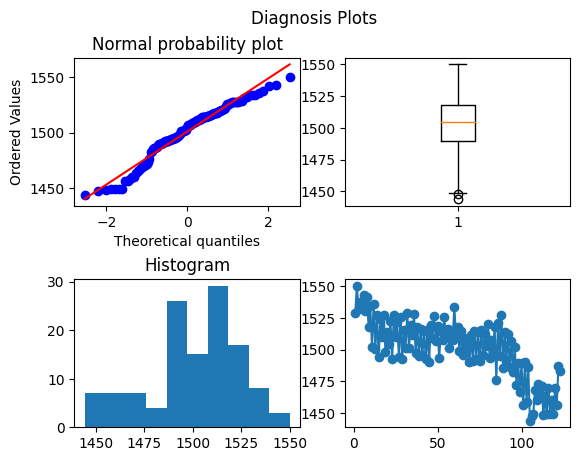

In [120]:
data_to_plot = track_2_agg_clean["min"]
fig, axs = plt.subplots(2, 2)
fig.suptitle('Diagnosis Plots')
stats.probplot(data_to_plot, dist="norm", plot=axs[0,0])
axs[0,0].set_title('Normal probability plot')
axs[0,1].boxplot(data_to_plot)
fig.subplots_adjust(hspace=0.5)
axs[1,0].hist(data_to_plot)
axs[1,0].set_title('Histogram')
axs[1,1].plot(np.arange(1, len(data_to_plot)+1), data_to_plot, 'o-')
plt.show()

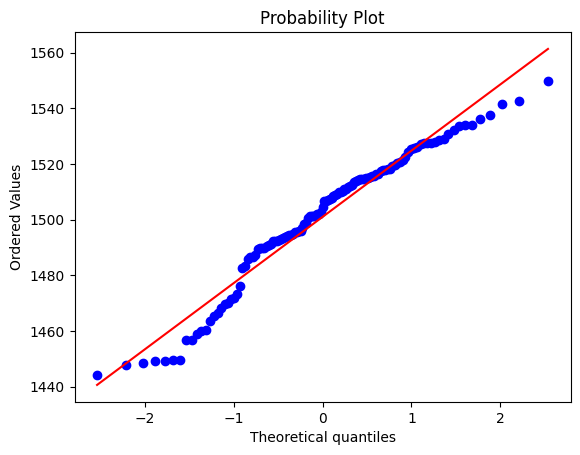

Shapiro-wilk test statistic = 0.959
Shapiro-wilk test p-value = 0.001
Runs test statistic = -1.027
Runs test p-value = 0.305



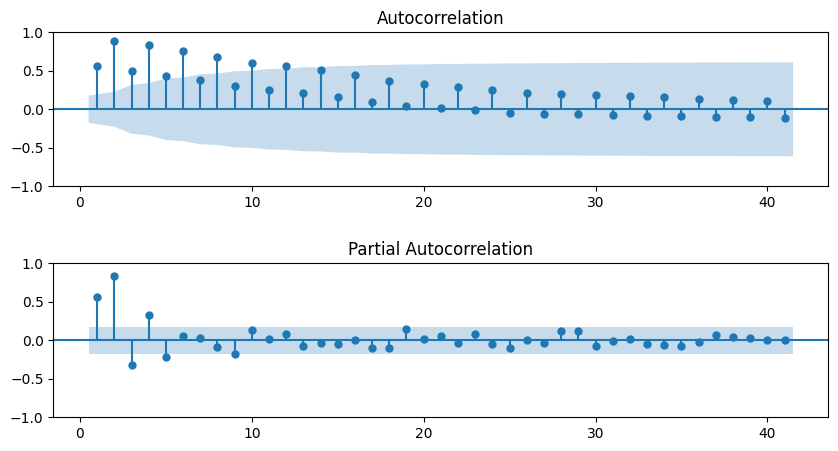

In [121]:
_ = qda.Assumptions(data_to_plot).normality()
_ = qda.Assumptions(data_to_plot).independence()

In [122]:
Q1 = track_2_agg_clean['min'].quantile(0.25)
Q3 = track_2_agg_clean['min'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

track_2_agg_clean3 = track_2_agg_clean[(track_2_agg_clean['min'] > lower_bound) & 
                     (track_2_agg_clean['min'] < upper_bound)].reset_index(drop=True)

print("The # of rows dropped =", track_2_agg_clean["mean"].count()-track_2_agg_clean3["mean"].count() )

The # of rows dropped = 2


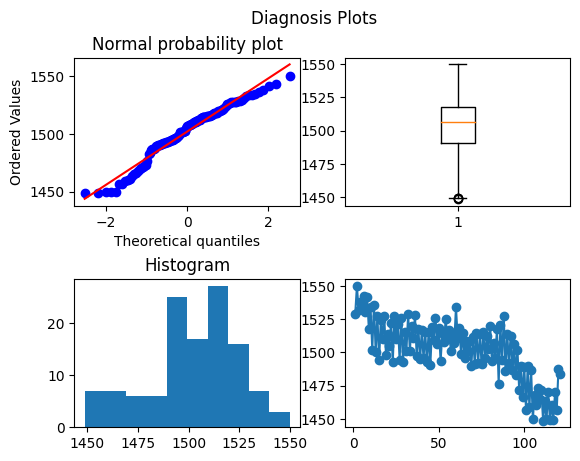

In [123]:
data_to_plot = track_2_agg_clean3["min"]
fig, axs = plt.subplots(2, 2)
fig.suptitle('Diagnosis Plots')
stats.probplot(data_to_plot, dist="norm", plot=axs[0,0])
axs[0,0].set_title('Normal probability plot')
axs[0,1].boxplot(data_to_plot)
fig.subplots_adjust(hspace=0.5)
axs[1,0].hist(data_to_plot)
axs[1,0].set_title('Histogram')
axs[1,1].plot(np.arange(1, len(data_to_plot)+1), data_to_plot, 'o-')
plt.show()

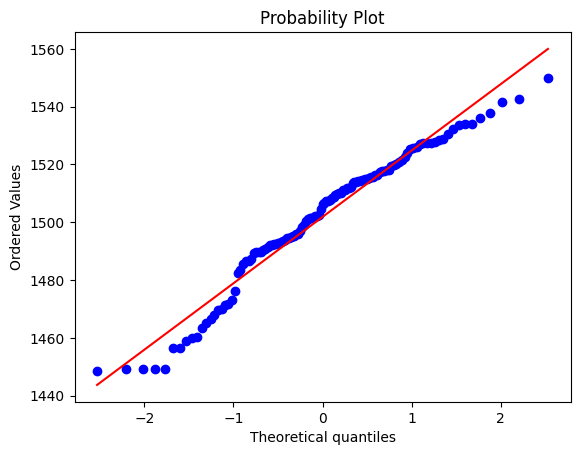

Shapiro-wilk test statistic = 0.963
Shapiro-wilk test p-value = 0.002
Runs test statistic = 0.520
Runs test p-value = 0.603



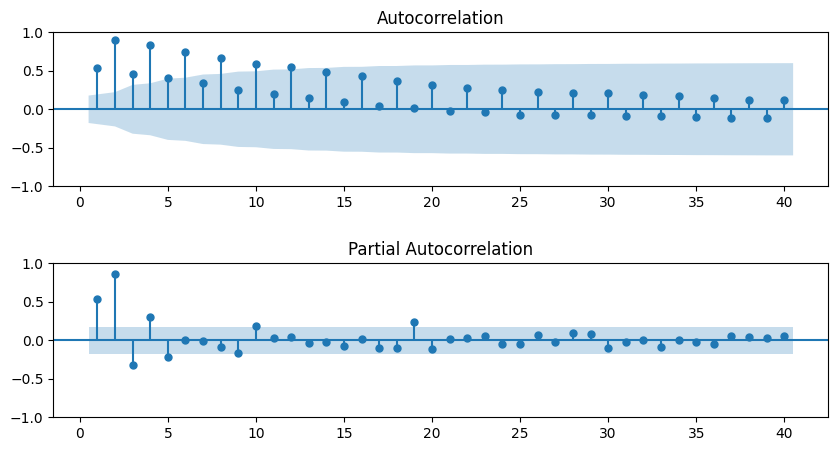

In [124]:
_ = qda.Assumptions(data_to_plot).normality()
_ = qda.Assumptions(data_to_plot).independence()

**Results**

By removing outliers, the max temperature values per track became suitable for control charting, allowing reliable anomaly detection within layers. The persistent irregularities in min values indicate the need for alternative monitoring approaches. This method offers a feasible way to monitor track-level thermal maxima while acknowledging limitations in capturing minima behavior.

# Approach 11: Max and min values of tracks on multiple layers

**Assumptions and preliminary data analysis**

This approach analyzes maximum and minimum temperature values grouped by tracks across multiple layers. Outliers in both max and min values were identified and excluded to improve data quality. The max values, after outlier removal, showed patterns suitable for modeling with an ARMA(1,2) model. Residuals from this model were further stabilized using a Box-Cox transformation, which solved normality. For the min values, an ARIMA(0,2,1) model was applied, successfully addressing trends and autocorrelation. Diagnostic checks on both models confirmed that residuals met the assumptions necessary for statistical process control.

**Proposed methodology**

Using the fitted ARMA and ARIMA models for max and min values respectively, two separate Shewhart control charts were constructed from the transformed residuals. These charts allowed effective monitoring of temperature shifts in track-wise data across multiple layers. The combination of outlier exclusion, appropriate time series modeling, and residual transformation provided a robust framework for detecting anomalies in both extremes of the temperature distribution.

In [125]:
multi_layer_tracks = full_frame[full_frame["layer_id"]<=228] #change this to try for another track
multi_layer_tracks.describe()
multi_layer_tracks["layer_track"]  = multi_layer_tracks["layer_id"]*10000 + multi_layer_tracks["track_id"]
multi_layer_tracks_agg = multi_layer_tracks.groupby('layer_track')['temp'].agg([
    'mean', 'std', 'min', 'max', 'median', 'count']).reset_index()
multi_layer_tracks_agg.describe()

,layer_track,mean,std,min,max,median,count
count,7.4300e+02,743.0000,743.0000,743.0000,743.0000,743.0000,743.0000
mean,2.2602e+06,1555.1023,12.7250,1516.8888,1601.0727,1554.3964,1218.8452
std,1.3338e+04,14.1778,3.6213,17.4635,14.9817,14.8030,522.6786
min,2.2400e+06,1504.6334,6.0492,1444.2000,1548.2000,1494.3000,8.0000
25%,2.2501e+06,1546.3816,10.9188,1508.3500,1593.6500,1545.6750,875.5000
50%,2.2601e+06,1556.3601,11.9021,1517.5000,1602.9000,1555.6500,1500.0000
75%,2.2701e+06,1564.7240,13.2051,1527.4000,1610.7500,1564.3250,1556.5000
max,2.2801e+06,1595.6682,34.8920,1580.8000,1639.1000,1595.5500,2122.0000


In [126]:
lb = multi_layer_tracks_agg["count"].mean() * 0.2
track_agg_ml_clean = multi_layer_tracks_agg[multi_layer_tracks_agg["count"] >= lb].reset_index()

print("The # of rows dropped =", multi_layer_tracks_agg["mean"].count()-track_agg_ml_clean["mean"].count() )
track_agg_ml_clean.describe()

The # of rows dropped = 64


,index,layer_track,mean,std,min,max,median,count
count,679.0000,6.7900e+02,679.0000,679.0000,679.0000,679.0000,679.0000,679.0000
mean,369.2283,2.2601e+06,1554.5365,12.9360,1515.2809,1602.2968,1553.7702,1323.6200
std,218.5488,1.3601e+04,13.1829,3.6822,15.8824,13.3926,13.8800,413.4567
min,1.0000,2.2400e+06,1504.6334,8.3939,1444.2000,1548.2000,1494.3000,246.0000
25%,177.5000,2.2501e+06,1546.6127,11.0918,1507.8000,1595.0000,1545.8500,1122.5000
50%,368.0000,2.2601e+06,1556.2625,12.0670,1517.0000,1603.4000,1555.5000,1500.0000
75%,558.5000,2.2701e+06,1564.3175,13.3956,1526.2000,1610.8500,1563.9500,1617.0000
max,741.0000,2.2801e+06,1582.4782,34.8920,1547.3000,1639.1000,1581.7000,2122.0000


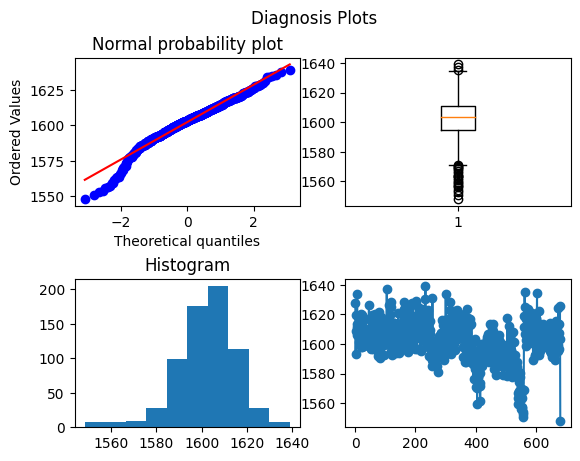

In [127]:
data_to_plot = track_agg_ml_clean["max"]
fig, axs = plt.subplots(2, 2)
fig.suptitle('Diagnosis Plots')
stats.probplot(data_to_plot, dist="norm", plot=axs[0,0])
axs[0,0].set_title('Normal probability plot')
axs[0,1].boxplot(data_to_plot)
fig.subplots_adjust(hspace=0.5)
axs[1,0].hist(data_to_plot)
axs[1,0].set_title('Histogram')
axs[1,1].plot(np.arange(1, len(data_to_plot)+1), data_to_plot, 'o-')
plt.show()

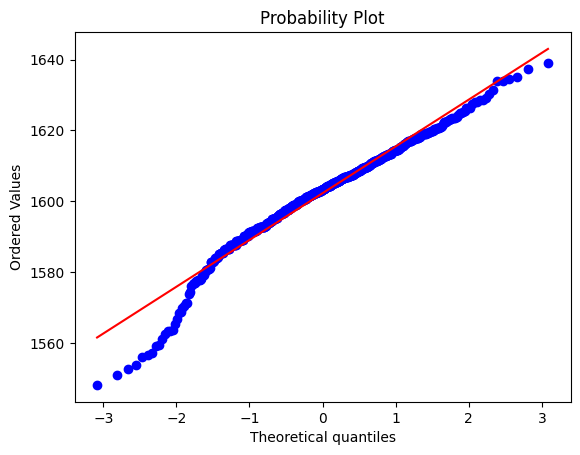

Shapiro-wilk test statistic = 0.966
Shapiro-wilk test p-value = 0.000
Runs test statistic = -10.194
Runs test p-value = 0.000



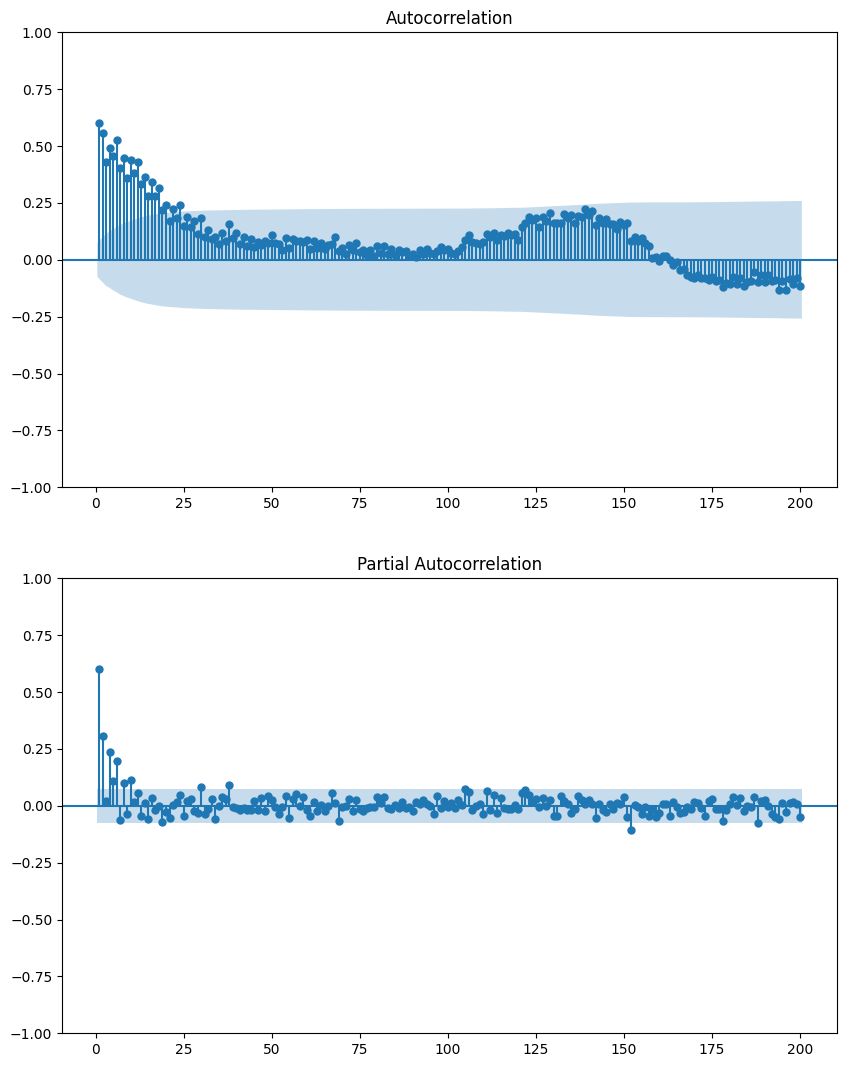

In [128]:
_ = qda.Assumptions(data_to_plot).normality()
_ = qda.Assumptions(data_to_plot).independence()

In [129]:
Q1 = track_agg_ml_clean['max'].quantile(0.25)
Q3 = track_agg_ml_clean['max'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

track_agg_ml_cleaner = track_agg_ml_clean[(track_agg_ml_clean['max'] > lower_bound) & 
                     (track_agg_ml_clean['max'] < upper_bound)].reset_index(drop=True)

print("The # of rows dropped =", track_agg_ml_clean["mean"].count()-track_agg_ml_cleaner["mean"].count() )

The # of rows dropped = 24


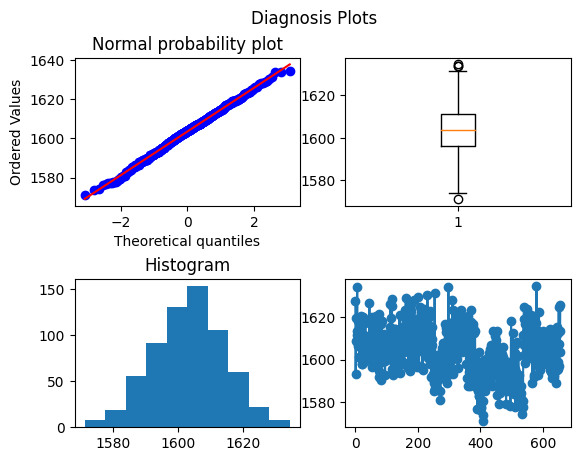

In [130]:
data_to_plot = track_agg_ml_cleaner["max"]
fig, axs = plt.subplots(2, 2)
fig.suptitle('Diagnosis Plots')
stats.probplot(data_to_plot, dist="norm", plot=axs[0,0])
axs[0,0].set_title('Normal probability plot')
axs[0,1].boxplot(data_to_plot)
fig.subplots_adjust(hspace=0.5)
axs[1,0].hist(data_to_plot)
axs[1,0].set_title('Histogram')
axs[1,1].plot(np.arange(1, len(data_to_plot)+1), data_to_plot, 'o-')
plt.show()

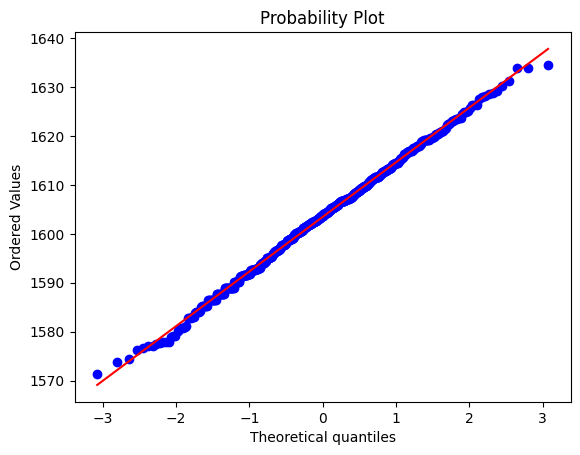

Shapiro-wilk test statistic = 0.998
Shapiro-wilk test p-value = 0.618
Runs test statistic = -8.868
Runs test p-value = 0.000



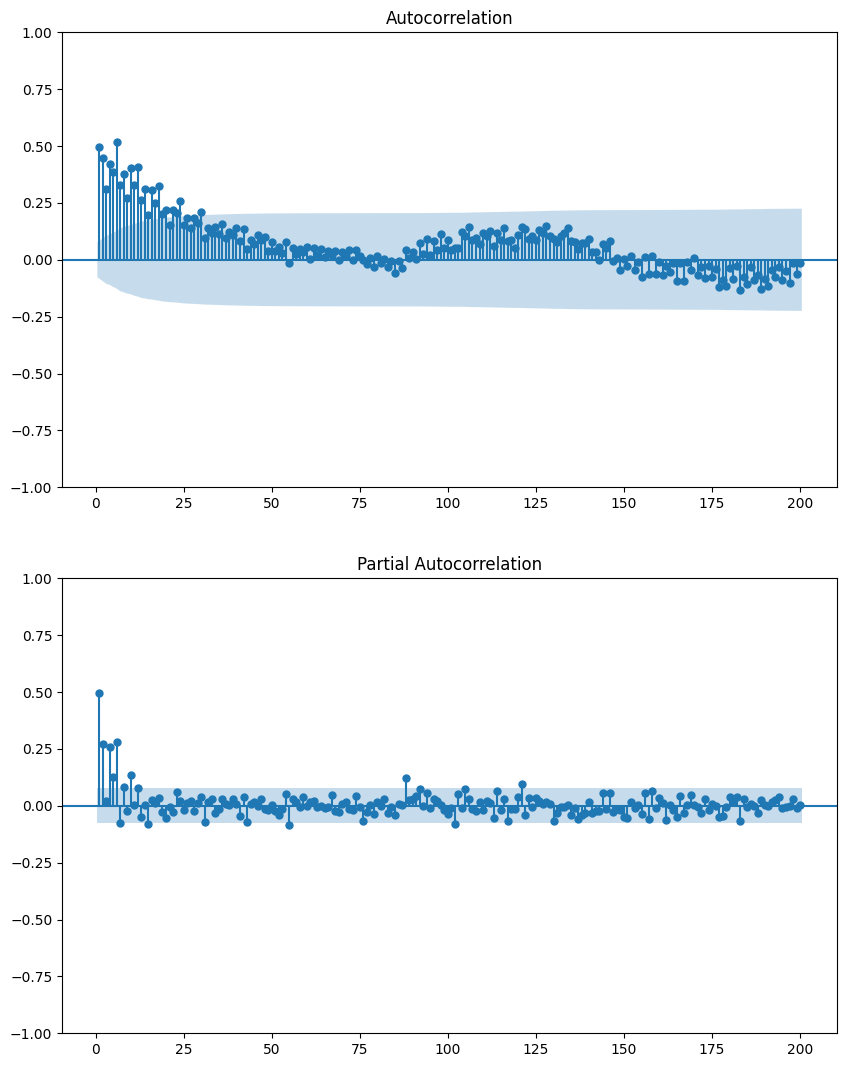

In [131]:
_ = qda.Assumptions(data_to_plot).normality()
_ = qda.Assumptions(data_to_plot).independence()

This is normally distributed, but definitely not independent. Let's try using ARIMA

---------------------
ARIMA MODEL RESULTS
---------------------
ARIMA model order: p=1, d=0, q=2

FINAL ESTIMATES OF PARAMETERS
-------------------------------
 Term      Coef  SE Coef  T-Value    P-Value
const 1604.1668   2.2841 702.3234 0.0000e+00
ar.L1    0.9726   0.0111  87.4027 0.0000e+00
ma.L1   -0.7263   0.0365 -19.9225 2.5987e-88
ma.L2   -0.0758   0.0378  -2.0062 4.4835e-02

RESIDUAL SUM OF SQUARES
-------------------------
   DF         SS      MS
651.0 51526.8583 79.1503

Ljung-Box Chi-Square Statistics
----------------------------------
 Lag  Chi-Square    P-Value
  12    134.1474 9.0561e-23
  24    204.4346 1.4457e-30
  36    234.5321 5.8098e-31
  48    258.0370 1.5307e-30
Runs test statistic = -0.379
Runs test p-value = 0.705



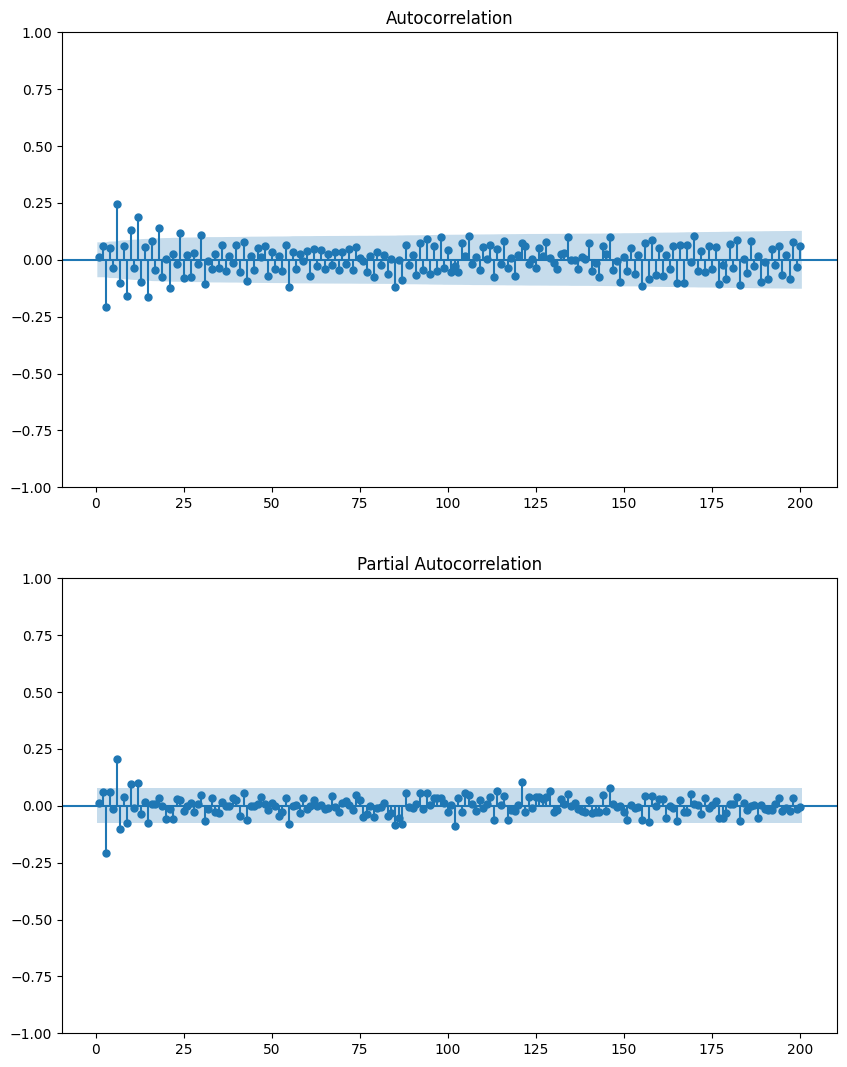

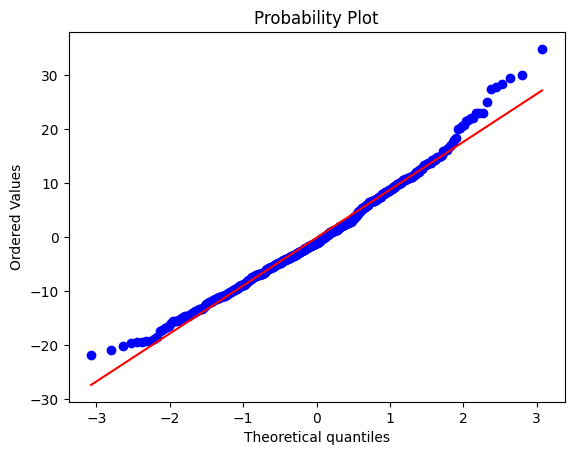

Shapiro-wilk test statistic = 0.986
Shapiro-wilk test p-value = 0.000


In [132]:
d = 0
model = qda.ARIMA(track_agg_ml_cleaner["max"], order=(1,d,2), add_constant=True)
qda.ARIMAsummary(model)
residuals = model.resid[d:].dropna()
_ = qda.Assumptions(residuals).independence()
_ = qda.Assumptions(residuals).normality()

Residuals are independent, but not normally distributed. Maybe transformation can help

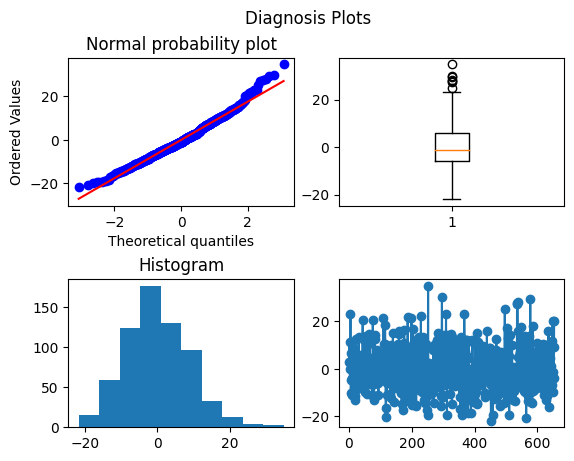

In [133]:
data_to_plot = residuals.dropna()
fig, axs = plt.subplots(2, 2)
fig.suptitle('Diagnosis Plots')
stats.probplot(data_to_plot, dist="norm", plot=axs[0,0])
axs[0,0].set_title('Normal probability plot')
axs[0,1].boxplot(data_to_plot)
fig.subplots_adjust(hspace=0.5)
axs[1,0].hist(data_to_plot)
axs[1,0].set_title('Histogram')
axs[1,1].plot(np.arange(1, len(data_to_plot)+1), data_to_plot, 'o-')
plt.show()

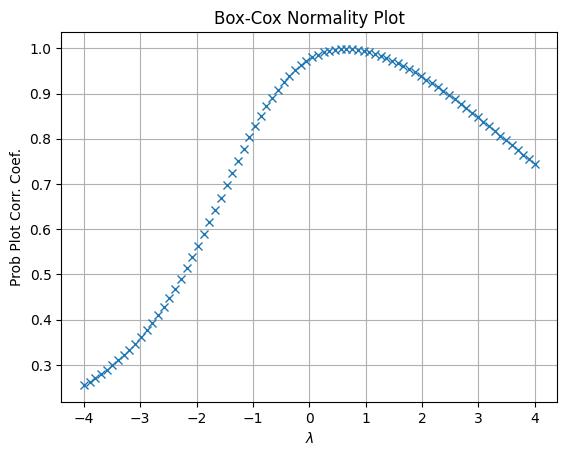

In [134]:
fig = plt.figure()
ax = fig.add_subplot(111)
stats.boxcox_normplot(residuals+25, -4, 4, plot=ax)
# add grid
ax.grid(True)

In [135]:
[data_BC, lmbda] = stats.boxcox(residuals+25)
print("Lambda =",lmbda)

Lambda = 0.6393494911671701


This is a great lambda value!

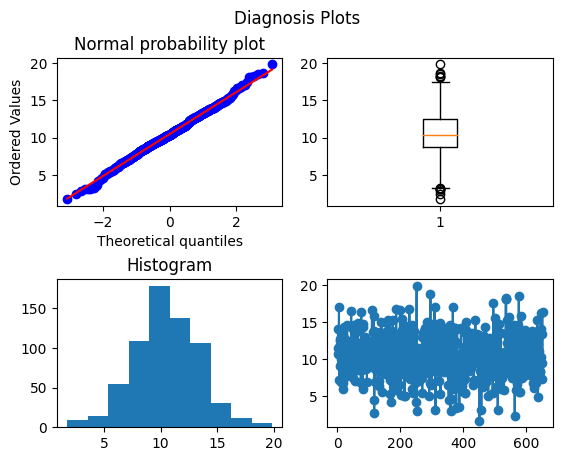

In [136]:
data_to_plot = data_BC
fig, axs = plt.subplots(2, 2)
fig.suptitle('Diagnosis Plots')
stats.probplot(data_to_plot, dist="norm", plot=axs[0,0])
axs[0,0].set_title('Normal probability plot')
axs[0,1].boxplot(data_to_plot)
fig.subplots_adjust(hspace=0.5)
axs[1,0].hist(data_to_plot)
axs[1,0].set_title('Histogram')
axs[1,1].plot(np.arange(1, len(data_to_plot)+1), data_to_plot, 'o-')
plt.show()

Runs test statistic = -0.640
Runs test p-value = 0.522



c:\Users\atari\anaconda3\envs\QDA_environment_WIN\lib\site-packages\qdatoolkit\models.py:723: UserWarning: A numpy array was passed to the Assumptions class and converted to Pandas Series.
Note that all other methods in qda-toolkit only accept Pandas Series or Pandas Dataframe.
  warnings.warn(


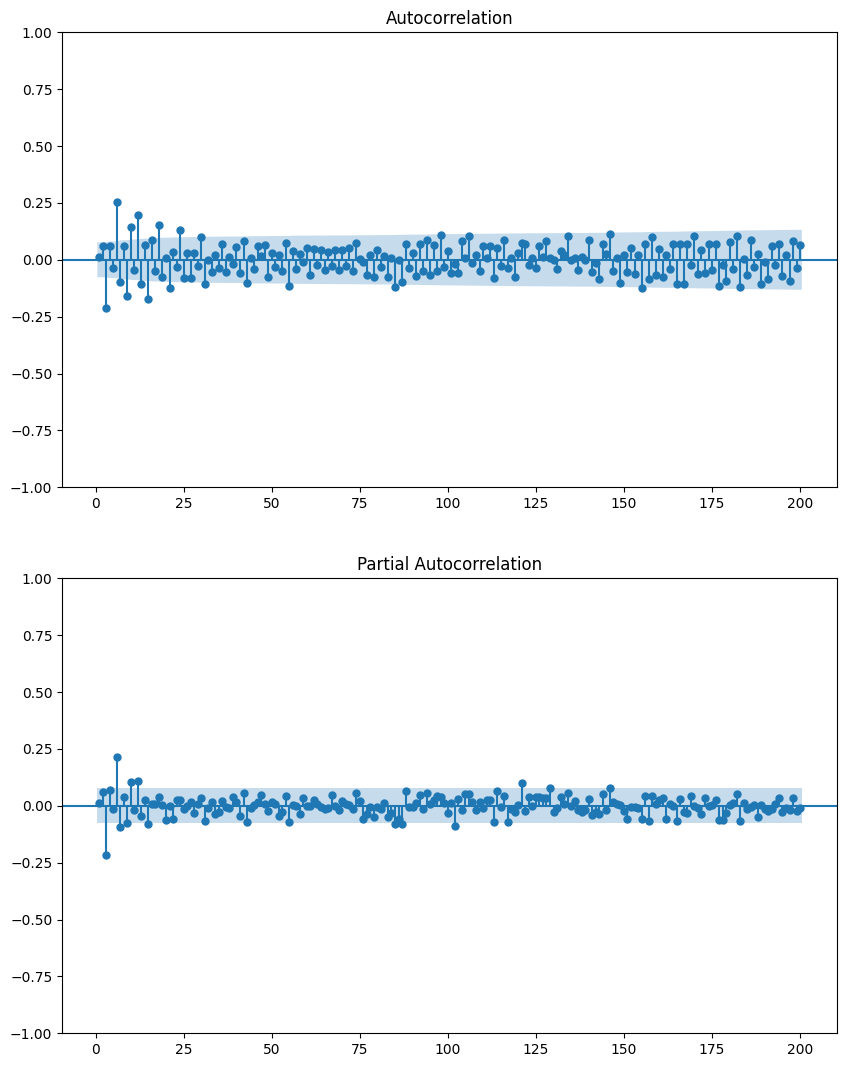

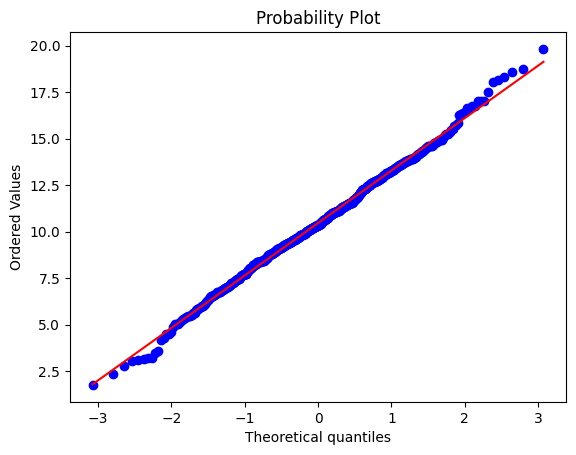

Shapiro-wilk test statistic = 0.997
Shapiro-wilk test p-value = 0.369


In [137]:
_ = qda.Assumptions(data_to_plot).independence()
_ = qda.Assumptions(data_to_plot).normality()

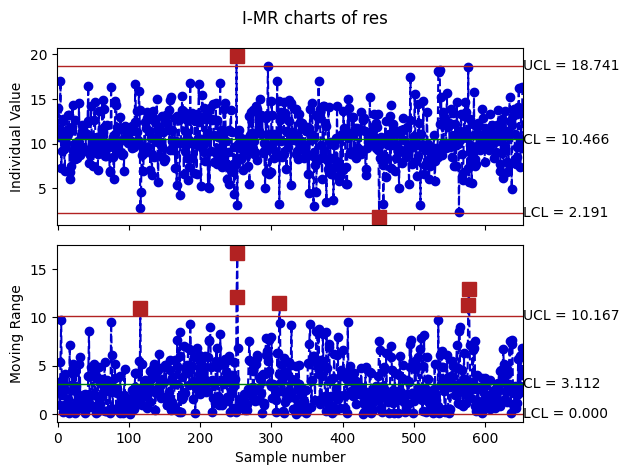

In [138]:
df_res = pd.DataFrame({'res': data_BC})
df_res= qda.ControlCharts.IMR(df_res, 'res',K=3)

## Similar approach that utilizes mins insteaad of maxes

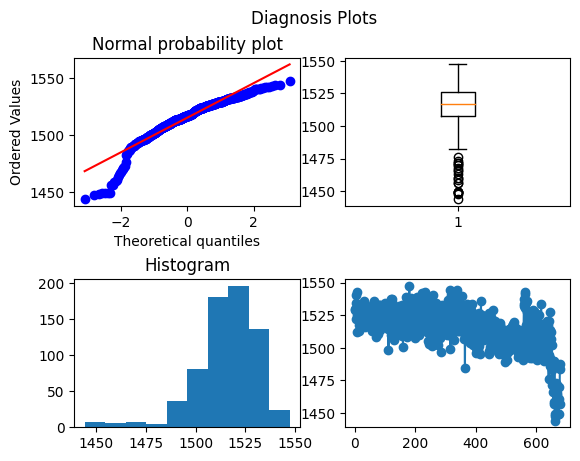

In [139]:
data_to_plot = track_agg_ml_clean["min"]
fig, axs = plt.subplots(2, 2)
fig.suptitle('Diagnosis Plots')
stats.probplot(data_to_plot, dist="norm", plot=axs[0,0])
axs[0,0].set_title('Normal probability plot')
axs[0,1].boxplot(data_to_plot)
fig.subplots_adjust(hspace=0.5)
axs[1,0].hist(data_to_plot)
axs[1,0].set_title('Histogram')
axs[1,1].plot(np.arange(1, len(data_to_plot)+1), data_to_plot, 'o-')
plt.show()

In [140]:
Q1 = track_agg_ml_clean['min'].quantile(0.25)
Q3 = track_agg_ml_clean['min'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

track_agg_ml_cleaner2 = track_agg_ml_clean[(track_agg_ml_clean['min'] > lower_bound) & 
                     (track_agg_ml_clean['min'] < upper_bound)].reset_index(drop=True)

print("The # of rows dropped =", track_agg_ml_clean["mean"].count()-track_agg_ml_cleaner2["mean"].count() )

The # of rows dropped = 22


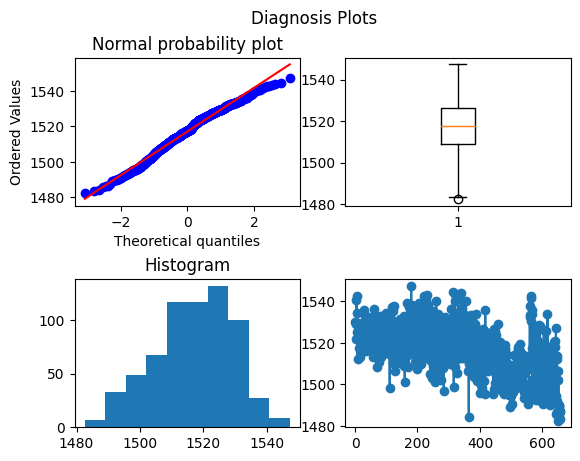

In [141]:
data_to_plot = track_agg_ml_cleaner2["min"]
fig, axs = plt.subplots(2, 2)
fig.suptitle('Diagnosis Plots')
stats.probplot(data_to_plot, dist="norm", plot=axs[0,0])
axs[0,0].set_title('Normal probability plot')
axs[0,1].boxplot(data_to_plot)
fig.subplots_adjust(hspace=0.5)
axs[1,0].hist(data_to_plot)
axs[1,0].set_title('Histogram')
axs[1,1].plot(np.arange(1, len(data_to_plot)+1), data_to_plot, 'o-')
plt.show()

Runs test statistic = -2.288
Runs test p-value = 0.022



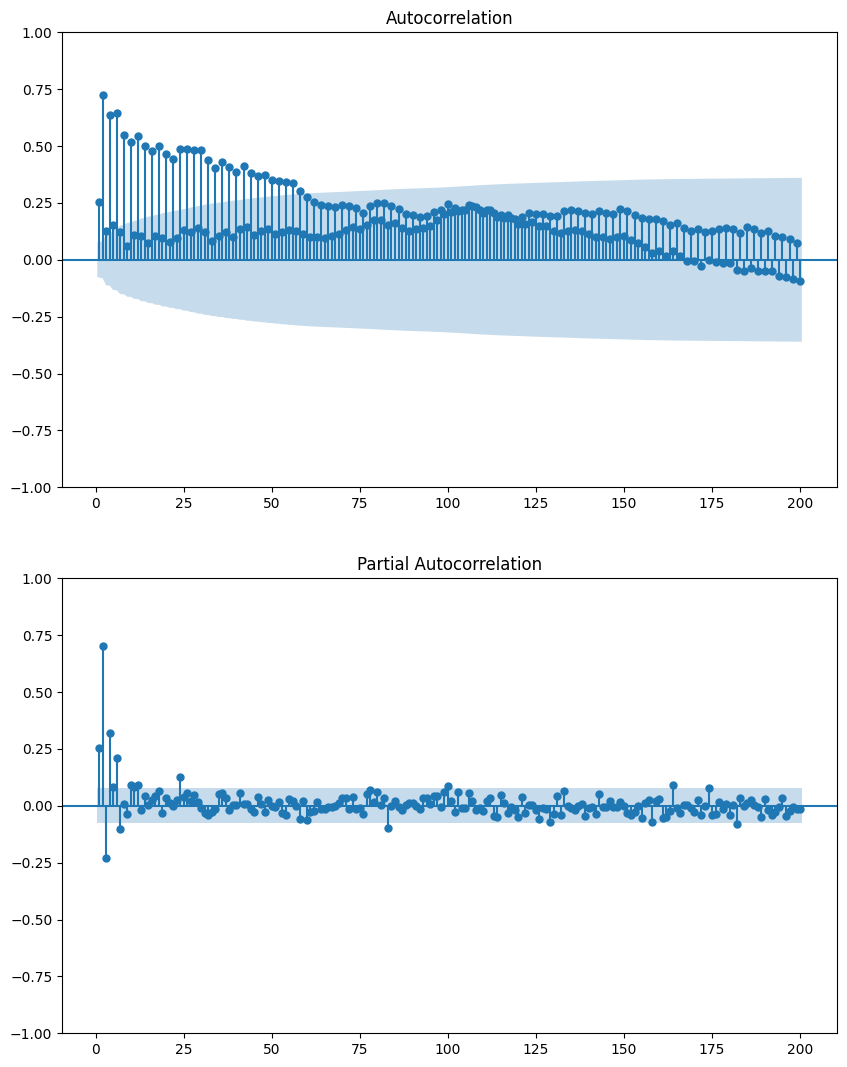

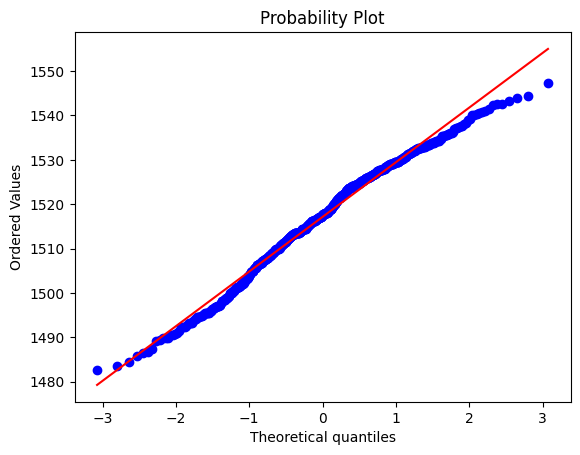

Shapiro-wilk test statistic = 0.987
Shapiro-wilk test p-value = 0.000


In [142]:
_ = qda.Assumptions(data_to_plot).independence()
_ = qda.Assumptions(data_to_plot).normality()

---------------------
ARIMA MODEL RESULTS
---------------------
ARIMA model order: p=0, d=2, q=1

FINAL ESTIMATES OF PARAMETERS
-------------------------------
 Term    Coef  SE Coef  T-Value     P-Value
const -0.1465   0.5105  -0.2871  7.7407e-01
ma.L1  0.5567   0.0233  23.8765 5.3751e-126

RESIDUAL SUM OF SQUARES
-------------------------
   DF         SS      MS
653.0 45747.0814 70.0568

Ljung-Box Chi-Square Statistics
----------------------------------
 Lag  Chi-Square    P-Value
  12    119.0142 9.7157e-20
  24    140.0640 2.2672e-18
  36    154.4660 1.2757e-16
  48    173.9489 3.5649e-16
Runs test statistic = 0.384
Runs test p-value = 0.701



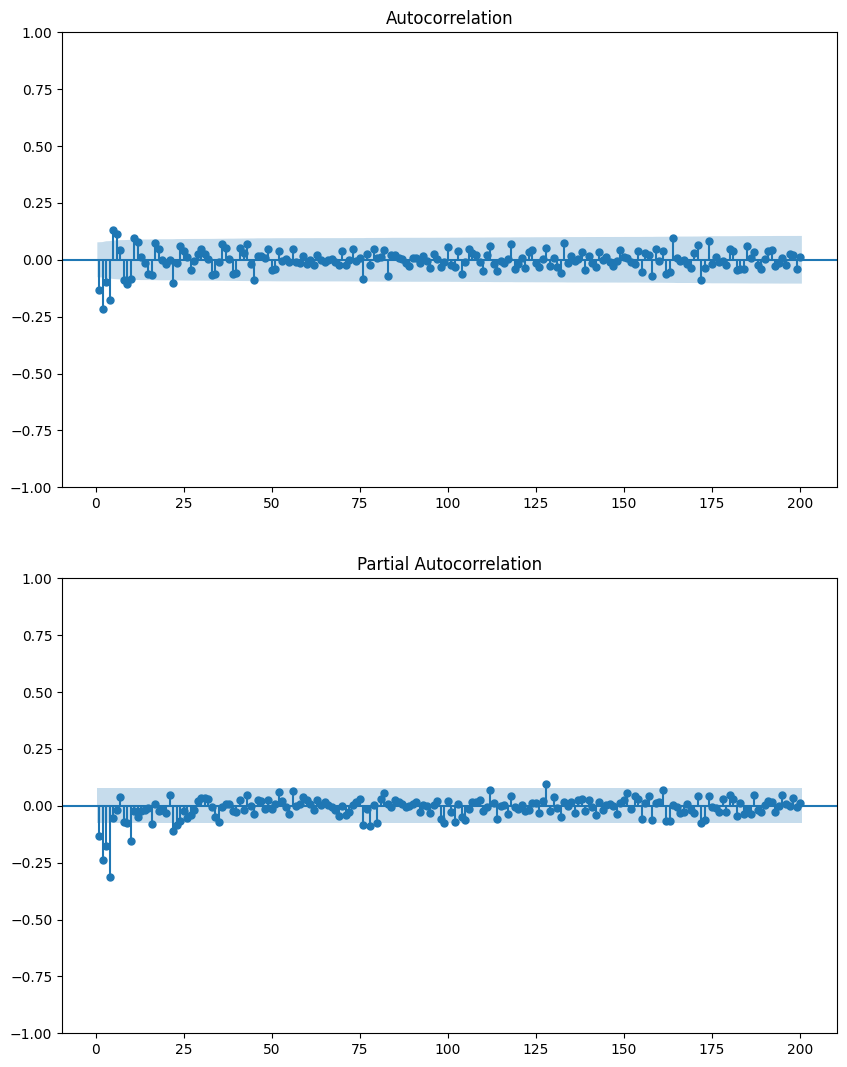

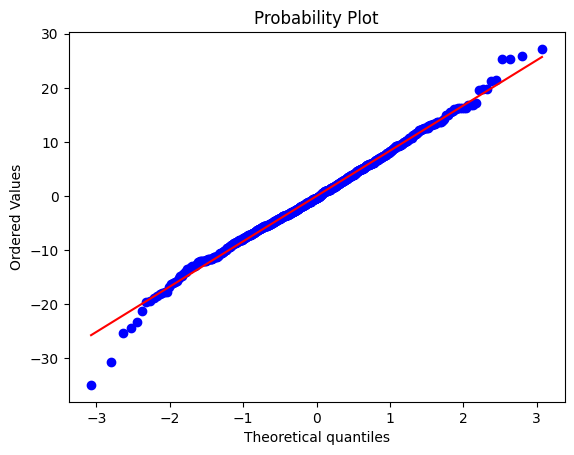

Shapiro-wilk test statistic = 0.995
Shapiro-wilk test p-value = 0.023


In [143]:
d = 2
model = qda.ARIMA(track_agg_ml_cleaner2["min"], order=(0,d,1), add_constant=True)
qda.ARIMAsummary(model)

residuals = model.resid[d:].dropna()
_ = qda.Assumptions(residuals).independence()
_ = qda.Assumptions(residuals).normality()

box cox

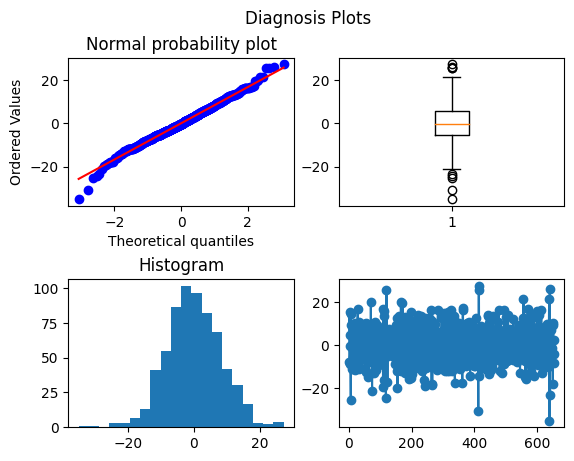

In [144]:
data_to_plot = residuals
fig, axs = plt.subplots(2, 2)
fig.suptitle('Diagnosis Plots')
stats.probplot(data_to_plot, dist="norm", plot=axs[0,0])
axs[0,0].set_title('Normal probability plot')
axs[0,1].boxplot(data_to_plot)
fig.subplots_adjust(hspace=0.5)
axs[1,0].hist(data_to_plot,bins = 20)
axs[1,0].set_title('Histogram')
axs[1,1].plot(np.arange(1, len(data_to_plot)+1), data_to_plot, 'o-')
plt.show()

In [145]:
track_agg_ml_cleaner2["residuals"] = model.resid
track_agg_ml_cleaner2 = track_agg_ml_cleaner2.dropna()
track_agg_ml_cleaner2["residuals"]

2      -7.7535
3      15.0417
4       4.6447
5      -0.2856
6      -8.6955
        ...   
652   -17.8162
653    10.1651
654    -8.2125
655     2.2186
656    -4.1886
Name: residuals, Length: 655, dtype: float64

There seems to be few outliers, let's see how the data would look without them

In [146]:
Q1 = track_agg_ml_cleaner2['residuals'].quantile(0.25)
Q3 = track_agg_ml_cleaner2['residuals'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

track_agg_ml_cleaner_res = track_agg_ml_cleaner2[(track_agg_ml_cleaner2['residuals'] > lower_bound) & 
                     (track_agg_ml_cleaner2['residuals'] < upper_bound)].reset_index(drop=True)

print("The # of rows dropped =", track_agg_ml_cleaner2["mean"].count()-track_agg_ml_cleaner_res["mean"].count() )

The # of rows dropped = 9


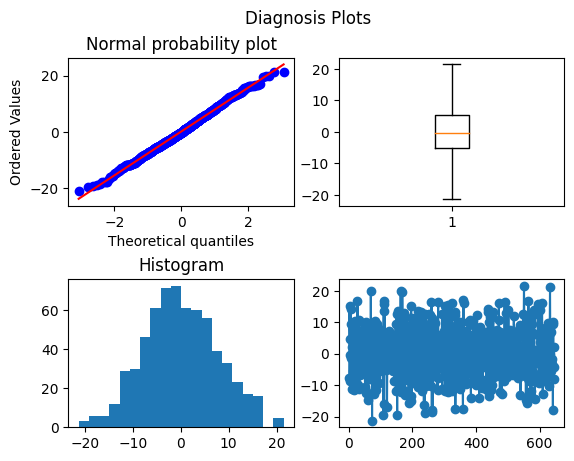

In [147]:
data_to_plot = track_agg_ml_cleaner_res["residuals"]
fig, axs = plt.subplots(2, 2)
fig.suptitle('Diagnosis Plots')
stats.probplot(data_to_plot, dist="norm", plot=axs[0,0])
axs[0,0].set_title('Normal probability plot')
axs[0,1].boxplot(data_to_plot)
fig.subplots_adjust(hspace=0.5)
axs[1,0].hist(data_to_plot,bins = 20)
axs[1,0].set_title('Histogram')
axs[1,1].plot(np.arange(1, len(data_to_plot)+1), data_to_plot, 'o-')
plt.show()

Runs test statistic = 0.587
Runs test p-value = 0.557



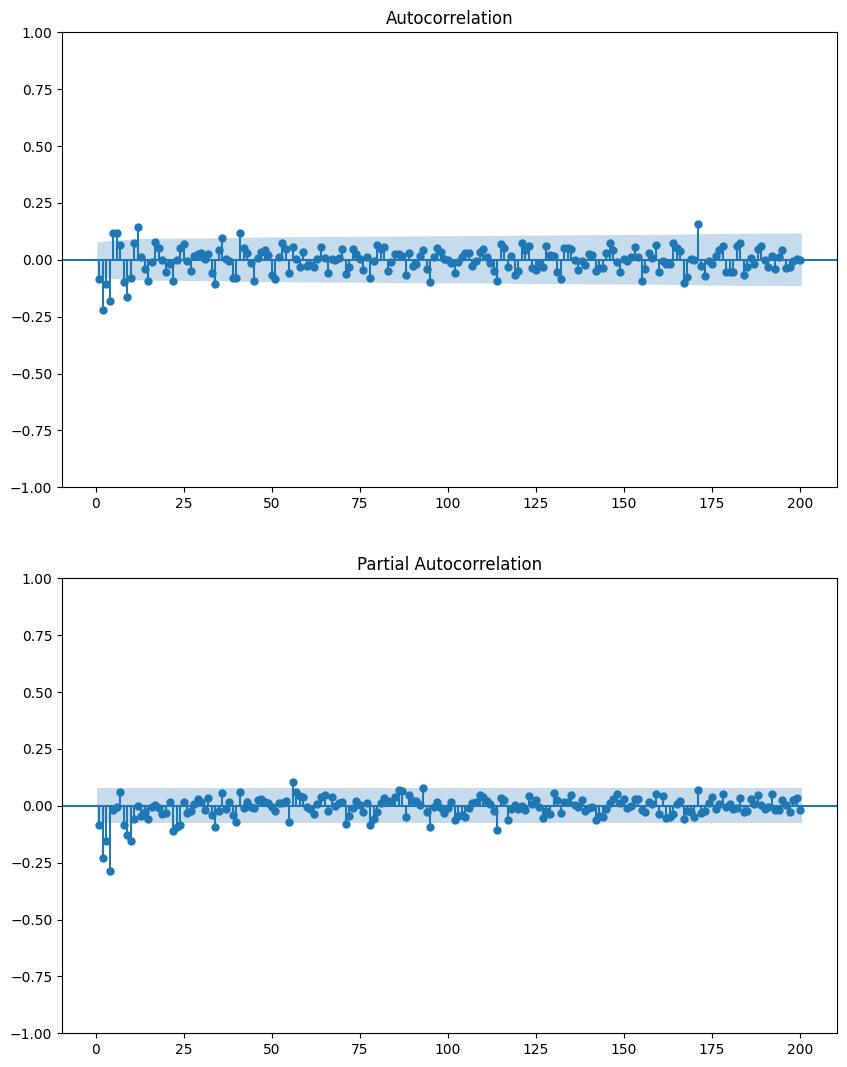

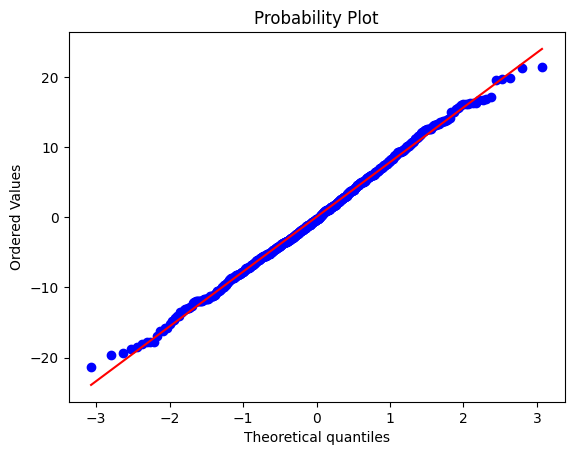

Shapiro-wilk test statistic = 0.997
Shapiro-wilk test p-value = 0.303


In [148]:
_ = qda.Assumptions(data_to_plot).independence()
_ = qda.Assumptions(data_to_plot).normality()

Both assumptions hold up. Construct the charts

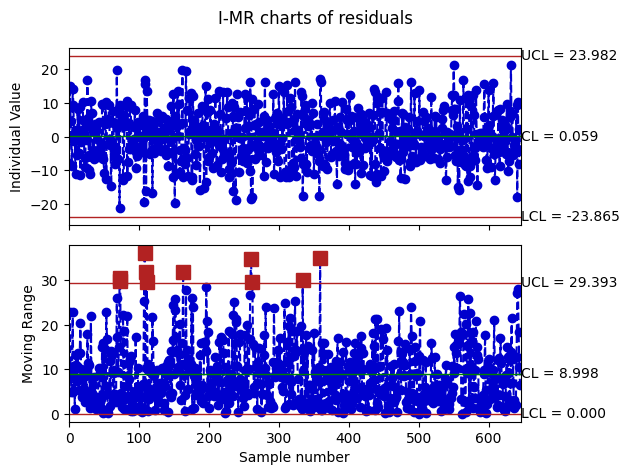

In [149]:
df_res= qda.ControlCharts.IMR(track_agg_ml_cleaner_res, "residuals",K=3)

**Results**

This approach produced two feasible control charts for max and min track temperature values across layers by combining outlier removal, time series modeling, and residual transformation. These charts appear to be the most promising for effectively working within layers and detecting out-of-control points in max and min temperatures, which are critical for monitoring thermal behavior. Their consistent performance supports potential for wider application in process control.

 # Conclusion

After conducting the analysis and trying different approaches, the final models selected in accordance with their usefulness and performances are the model of **Approach 8, and Approach 11**. More specifically:

* I-MR Control Charts constructed for means of tracks within a single layer using ARIMA

* I-MR Control Charts constructed for maximum values of each track across adjacent layers using ARIMA

* I-MR Control Charts constructed for minimum values of each track across adjacent layers using ARIMA

The selected models together allows monitoring of both defects that affect an entire track and isolated high or low temperature points. The first model allows the monitoring of the mean temperature of each layer with significant size, usually only excluding a few tracks in the start or end of a layer, and raises an alarm if the mean temperature is out of control with I chart, while monitoring large temperature differences between consequent layers. Moreover, it works with fairly conservative ARIMA parameters and can be constructed for any layer, remedying the greatest limitation of the model, generalizability. It would have been optimal to be able to construct a chart that can work with multiple adjacent layers, but in the absence of such a layer, *"I-MR Control Charts constructed for means of tracks within a single layer using ARIMA"* remain the best model at hand to detect track-wise anomalies.

The second and third models respectively allow monitoring the existence of isolated high and low temperature points within a single track. Their main strength is the generalizability since they work on data across multiple layers with relatively low ARIMA parameters, and the necessities to remove a few outliers or carry out a Box-Cox transformation on residuals were deemed as worthwhile trade-offs. Their largest limitation is their inability to identify the exact point with a high or low temperature. Instead, they only identify tracks that include such a point. While not the perfect solution, it was still considered as valuable information to monitor.

As for a brief justification on why certain approaches were discarded:

**Approaches 2 and 3 and 9** did not reach a satisfactory model.

**Approach 1** is eliminated due to several factors, including the limited usefulness and interpretability of binning by t values, as well as the necessity to remove outliers from model residuals even when working within a single layer.

**Approach 4** provided a well-fitting model but was deemed unuseful due to huge loss of information and function caused by taking each layer as an immensely sized chart. Moreover, the way layers are provided violates one of the key assumptions of ARIMA, which is sequentiality. In the presence of a larger sequential data to work with, it could have proved a useful approach for detecting anomalies that span a whole layer.

**Approaches 5 and 6** are eliminated due to a need to eliminate sizeable data concerning edges of the plane (points with high and low x or y values) and limited interpretability of using either rows or columns as the unit of analysis due to the machine working on tracks instead of rows or columns, causing insequentiality.

These problems were carried and amplified through **Approaches 7A and 7B**, with an additional problem of overdifferentiating, resulting in elimination of those models as well.

**Approach 10** was fairly successful, but **Approach 11** yielded results that are more generalizable and applicable on multiple layers with same principles, so it was discared due to a strictly better alternative.


In Phase 2, the models identified and selected during this phase will undergo a comprehensive evaluation using newly collected data that was not part of the initial training or selection process. This step aims to assess the robustness and generalizability of each model under different data conditions. Based on the results of this testing, the models may be refined, recalibrated, or otherwise adjusted to ensure optimal performance and reliability before any further deployment or analysis.